#### Documento integrado: Actividades 2 y 4 y actividad final de dashboard

Elaborado por: FERNANDO PIÑEROS SOLER  
2026 2-PROGRAMACION PARA CIENCIA DE DATOS II-2314-5A MOM 1 VIRTUAL  
Profesor: WILLIAM EDUARDO CLAVIJO BOHORQUEZ

# Perfil del viajero aéreo en Colombia frente a Latinoamérica: análisis estadístico y dashboard (2022)

## 1. Título del ejercicio

Caracterización descriptiva, contraste estadístico, modelos y dashboard interactivo del perfil y el gasto por registro de viajeros aéreos de Colombia frente a seis países latinoamericanos en una base ficticia de 2022.

## 2. Objetivo general

Analizar el perfil, los patrones de viaje y el gasto por registro de los viajeros de Colombia frente a Brasil, México, Chile, Perú, Argentina y Panamá en una base ficticia de 2.500 registros de 2022, mediante exploración descriptiva (Actividad 2), contraste de hipótesis y modelos de regresión y clasificación (Actividad 4), y comunicar los hallazgos y sus límites en un dashboard interactivo con filtros y resultados de los modelos claramente identificados (Actividad 6).

## Objetivos específicos

1. Verificar la estructura y la calidad de la base, y describir las variables numéricas y categóricas por país y segmento de viaje.
2. Comparar la distribución y el gasto por registro según país, motivo de viaje, tipo de vuelo y clase tarifaria, con tamaños de grupo visibles para interpretar las diferencias.
3. Explorar la asociación entre distancia recorrida y gasto mediante correlación y regresión lineal simple.
4. Contrastar la diferencia de gasto medio entre Colombia y los otros seis países de la base, interpretando el valor p dentro de los límites de los datos ficticios.
5. Evaluar una regresión lineal múltiple del gasto y comparar dos especificaciones de regresión logística para clasificar el tipo de vuelo, informando métricas de prueba y limitaciones.
6. Construir y comprobar un dashboard en Dash y Plotly con cuatro filtros combinados, tarjetas y gráficas que respondan a la selección, un botón para restablecer los filtros y un panel separado de métricas históricas que permanezcan fijas.
7. Documentar las decisiones, la ejecución local y los límites de interpretación, y preparar los archivos de soporte para su posterior publicación y prueba en GitHub y Binder.

## 3. Alcance del trabajo

**Periodo y unidad:** corte transversal de 2022; cada fila corresponde a un registro individual de la base de práctica. Esta base no permite analizar tendencias entre años.

**Cobertura:** Colombia, Brasil, México, Chile, Perú, Argentina y Panamá. Las comparaciones se hacen entre registros de estos siete países; «otros países» designa únicamente los países distintos de Colombia que permanezcan visibles tras filtrar.

**Datos y límites:** `Base_Viajeros_LATAM_2022.xlsx` contiene 2.500 registros ficticios y 20 variables. La distribución por país se construyó para el ejercicio; los registros no constituyen una muestra probabilística de viajeros reales. Los conteos, diferencias, modelos y valores p describen estos datos simulados, sin estimar el tráfico, el gasto poblacional ni ingresos reales del sector.

**Actividad 2:** revisión y preparación de datos, estadística descriptiva numérica y categórica, cruces, visualizaciones y regresión lineal simple de distancia frente a gasto.

**Actividad 4:** contraste de las medias de gasto entre Colombia y los demás registros, regresión lineal múltiple del gasto y comparación de modelos de regresión logística para el tipo de vuelo. Las métricas corresponden a las particiones y especificaciones documentadas en el cuaderno.

**Actividad 6 – dashboard:** aplicación local en Dash y Plotly con filtros por país, motivo, tipo de vuelo y clase tarifaria; tarjetas y cinco gráficas recalculadas para la selección visible; botón «Restablecer filtros»; y sexto panel con resultados fijos de Welch, regresión múltiple y regresiones logísticas de las actividades previas. El tablero permite explorar asociaciones de la base ficticia, sin recalcular los modelos al filtrar.

**Documentación y transferencia:** el cuaderno registra la construcción paso a paso; el script, Excel, dependencias, README e informe acompañan la ejecución. Los archivos para Binder están preparados, pero el despliegue y los enlaces requieren publicación y comprobación posterior.


## 4. Identificación de la Base de Datos  #

La identificación de la base permite comprobar qué representa cada registro y si sus variables sirven para responder las preguntas del proyecto. Primero se explica la transición desde la fuente inicial; después se revisan la estructura, la calidad y la cobertura geográfica de los datos.


#### 4.0. Nota metodológica: transición de base de datos (de Actividad 2 al análisis integrado)

En la Actividad 2 se trabajó exclusivamente con `airpassangers.csv`, una serie histórica del Banco Mundial compuesta **solo por variables numéricas** (pasajeros transportados por año y país). Esto permitió calcular estadísticos descriptivos y una regresión, pero impidió trabajar estadística categórica, tablas de contingencia o pruebas de independencia, requeridas para profundizar el análisis.

Para esta entrega se incorpora una **base de datos más completa**, generada de forma ficticia en Anaconda/Jupyter: `Base_Viajeros_LATAM_2022`. Esta base ya es el resultado de un proceso de depuración previo hecho sobre una base más amplia de pasajeros, y contiene **2.500 registros individuales de viajeros** con **8 variables numéricas** y **12 variables categóricas** (país, sexo, motivo de viaje, clase tarifaria, tipo de aerolínea, temporada, etc.).

A partir de este punto se conserva exactamente la misma metodología y el mismo orden de la Actividad 2 (exploración → depuración/verificación → confirmación del alcance geográfico → medidas descriptivas → visualización → regresión → conclusiones), pero enriquecida con el componente categórico.

#### 4.1. Exploración Inicial

En esta fase se inspecciona la estructura general del DataFrame, sus dimensiones, los tipos de variable (numéricas y categóricas) y la presencia de registros nulos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar la nueva base de datos (Base Viajeros LATAM 2022)
df = pd.read_excel('Base_Viajeros_LATAM_2022.xlsx', sheet_name='Datos_Viajeros', header=3)

print("--- DIMENSIONES DEL DATAFRAME ---")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}\n")

print("--- INFORMACIÓN GENERAL Y TIPOS DE DATOS ---")
df.info()

print("\n--- PRIMERAS 10 FILAS ---")
df.head(10)

--- DIMENSIONES DEL DATAFRAME ---
Filas: 2500, Columnas: 20

--- INFORMACIÓN GENERAL Y TIPOS DE DATOS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Viajero_ID                  2500 non-null   object 
 1   Anio                        2500 non-null   int64  
 2   Pais                        2500 non-null   object 
 3   Sexo                        2500 non-null   object 
 4   Edad                        2500 non-null   int64  
 5   Rango_Edad                  2500 non-null   object 
 6   Tipo_Vuelo                  2500 non-null   object 
 7   Motivo_Viaje                2500 non-null   object 
 8   Tamano_Grupo                2500 non-null   int64  
 9   Distancia_KM                2500 non-null   int64  
 10  Clase_Tarifaria             2500 non-null   object 
 11  Tipo_Aerolinea              2500 non-null

,Viajero_ID,Anio,Pais,Sexo,Edad,Rango_Edad,Tipo_Vuelo,Motivo_Viaje,Tamano_Grupo,Distancia_KM,Clase_Tarifaria,Tipo_Aerolinea,Temporada_Viaje,Duracion_Viaje_Dias,Anticipacion_Compra_Dias,Compra_Anticipada,Viajes_Ultimo_Anio,Frecuencia_Viajero,Miembro_Programa_Fidelidad,Gasto_Total_USD
0,V0008,2022,Argentina,Femenino,41,36-45,Domestico,Turismo,1,888,Economica,Tradicional,Baja,6,13,No,4,Frecuente,No,186.50
1,V0025,2022,Argentina,Masculino,31,26-35,Internacional,Turismo,2,3736,Economica,Tradicional,Alta,9,15,No,2,Ocasional,No,355.17
2,V0051,2022,Argentina,Masculino,42,36-45,Internacional,Turismo,5,8143,Economica,Low_Cost,Alta,7,25,No,1,Ocasional,Si,545.57
3,V0062,2022,Argentina,Femenino,39,36-45,Domestico,Negocios,1,1684,Economica,Tradicional,Alta,2,8,No,9,Muy_Frecuente,No,217.05
4,V0088,2022,Argentina,Masculino,30,26-35,Domestico,Negocios,1,1677,Economica,Tradicional,Baja,1,10,No,2,Ocasional,No,269.98
5,V0099,2022,Argentina,Femenino,28,26-35,Internacional,Familiar_Visita,3,7729,Economica,Tradicional,Baja,14,12,No,1,Ocasional,Si,466.48
6,V0105,2022,Argentina,Masculino,37,36-45,Domestico,Familiar_Visita,2,1231,Economica,Tradicional,Baja,18,2,No,3,Frecuente,No,107.16
7,V0112,2022,Argentina,Femenino,50,46-55,Domestico,Turismo,2,1350,Economica,Low_Cost,Baja,10,3,No,3,Frecuente,No,212.24
8,V0114,2022,Argentina,Femenino,18,18-25,Internacional,Turismo,5,1458,Economica,Low_Cost,Alta,7,11,No,2,Ocasional,No,178.12
9,V0128,2022,Argentina,Masculino,54,46-55,Domestico,Turismo,4,598,Economica,Low_Cost,Baja,3,70,Si,3,Frecuente,No,159.46


In [3]:
# Clasificación de variables por tipo
variables_numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
variables_categoricas = df.select_dtypes(exclude=['int64', 'float64']).columns.tolist()

print(f"Variables NUMÉRICAS ({len(variables_numericas)}):")
print(variables_numericas)
print(f"\nVariables CATEGÓRICAS ({len(variables_categoricas)}):")
print(variables_categoricas)

Variables NUMÉRICAS (8):
['Anio', 'Edad', 'Tamano_Grupo', 'Distancia_KM', 'Duracion_Viaje_Dias', 'Anticipacion_Compra_Dias', 'Viajes_Ultimo_Anio', 'Gasto_Total_USD']

Variables CATEGÓRICAS (12):
['Viajero_ID', 'Pais', 'Sexo', 'Rango_Edad', 'Tipo_Vuelo', 'Motivo_Viaje', 'Clase_Tarifaria', 'Tipo_Aerolinea', 'Temporada_Viaje', 'Compra_Anticipada', 'Frecuencia_Viajero', 'Miembro_Programa_Fidelidad']


#### 4.2. Limpieza y Depuración de Datos (Data Cleaning)

A diferencia de la Actividad 2 (donde había que eliminar columnas completas de años sin datos), esta 
base ya es el resultado de un proceso de depuración previo realizado sobre una base más amplia de pasajeros: viene sin columnas administrativas vacías y ya filtrada a los 7 mercados de interés. Aun así, se mantiene la misma disciplina de depuración de la entrega anterior, verificando explícitamente: duplicados, valores nulos, rangos de las variables numéricas y consistencia de las categorías declaradas en las variables categóricas.

In [4]:
# 4.2.1. Verificación de duplicados y valores nulos
print("--- DUPLICADOS ---")
print(f"Filas duplicadas (registro completo): {df.duplicated().sum()}")
print(f"Viajero_ID duplicados: {df['Viajero_ID'].duplicated().sum()}")

print("\n--- VALORES NULOS POR COLUMNA ---")
print(df.isnull().sum())
print(f"\nTotal de valores nulos en el DataFrame: {df.isnull().sum().sum()}")

--- DUPLICADOS ---
Filas duplicadas (registro completo): 0
Viajero_ID duplicados: 0

--- VALORES NULOS POR COLUMNA ---
Viajero_ID                    0
Anio                          0
Pais                          0
Sexo                          0
Edad                          0
Rango_Edad                    0
Tipo_Vuelo                    0
Motivo_Viaje                  0
Tamano_Grupo                  0
Distancia_KM                  0
Clase_Tarifaria               0
Tipo_Aerolinea                0
Temporada_Viaje               0
Duracion_Viaje_Dias           0
Anticipacion_Compra_Dias      0
Compra_Anticipada             0
Viajes_Ultimo_Anio            0
Frecuencia_Viajero            0
Miembro_Programa_Fidelidad    0
Gasto_Total_USD               0
dtype: int64

Total de valores nulos en el DataFrame: 0


In [5]:
# 4.2.2. Verificación de rangos de las variables numéricas
# (contraste contra los rangos esperados según el diccionario de datos)
resumen_rangos = df[variables_numericas].agg(['min', 'max']).T
resumen_rangos.columns = ['Mínimo', 'Máximo']
resumen_rangos

,Mínimo,Máximo
Anio,2022.00,2022.00
Edad,18.00,75.00
Tamano_Grupo,1.00,6.00
Distancia_KM,90.00,11483.00
Duracion_Viaje_Dias,1.00,90.00
Anticipacion_Compra_Dias,0.00,180.00
Viajes_Ultimo_Anio,1.00,12.00
Gasto_Total_USD,85.19,3098.65


In [6]:
# 4.2.3. Verificación de consistencia de las categorías declaradas
for col in variables_categoricas:
    if col == 'Viajero_ID':
        continue
    print(f"{col} ({df[col].nunique()} categorías): {sorted(df[col].unique().tolist())}")

Pais (7 categorías): ['Argentina', 'Brasil', 'Chile', 'Colombia', 'Mexico', 'Panama', 'Peru']
Sexo (2 categorías): ['Femenino', 'Masculino']
Rango_Edad (6 categorías): ['18-25', '26-35', '36-45', '46-55', '56-65', '66+']
Tipo_Vuelo (2 categorías): ['Domestico', 'Internacional']
Motivo_Viaje (4 categorías): ['Estudios', 'Familiar_Visita', 'Negocios', 'Turismo']
Clase_Tarifaria (3 categorías): ['Economica', 'Ejecutiva', 'Premium_Economy']
Tipo_Aerolinea (2 categorías): ['Low_Cost', 'Tradicional']
Temporada_Viaje (2 categorías): ['Alta', 'Baja']
Compra_Anticipada (2 categorías): ['No', 'Si']
Frecuencia_Viajero (3 categorías): ['Frecuente', 'Muy_Frecuente', 'Ocasional']
Miembro_Programa_Fidelidad (2 categorías): ['No', 'Si']


In [7]:
# 4.2.4. Conversión de variables categóricas a tipo 'category'
# Optimiza memoria y asegura que pandas trate estas variables como categóricas
# (necesario para tablas de frecuencia, tablas de contingencia y gráficos por categoría).
mem_antes = df.memory_usage(deep=True).sum() / 1024

cols_a_convertir = [c for c in variables_categoricas if c != 'Viajero_ID']
for col in cols_a_convertir:
    df[col] = df[col].astype('category')

mem_despues = df.memory_usage(deep=True).sum() / 1024

print(f"Memoria antes de la conversión:   {mem_antes:,.1f} KB")
print(f"Memoria después de la conversión: {mem_despues:,.1f} KB")
print(f"\nReducción: {(1 - mem_despues/mem_antes)*100:.1f}%")
print("\n--- TIPOS DE DATO FINALES ---")
df.dtypes

Memoria antes de la conversión:   1,791.4 KB
Memoria después de la conversión: 318.5 KB

Reducción: 82.2%

--- TIPOS DE DATO FINALES ---


Viajero_ID                      object
Anio                             int64
Pais                          category
Sexo                          category
Edad                             int64
Rango_Edad                    category
Tipo_Vuelo                    category
Motivo_Viaje                  category
Tamano_Grupo                     int64
Distancia_KM                     int64
Clase_Tarifaria               category
Tipo_Aerolinea                category
Temporada_Viaje               category
Duracion_Viaje_Dias              int64
Anticipacion_Compra_Dias         int64
Compra_Anticipada             category
Viajes_Ultimo_Anio               int64
Frecuencia_Viajero            category
Miembro_Programa_Fidelidad    category
Gasto_Total_USD                float64
dtype: object

Conclusión de la depuración: no se encontraron registros duplicados ni valores nulos, y todas las variables numéricas se encuentran dentro de los rangos declarados en el diccionario de datos (Edad 18–75 años, Distancia_KM ~90–11.500 km, Gasto_Total_USD USD 80–6.000, etc.). Las 12 variables categóricas presentan categorías limpias y consistentes (sin variaciones de escritura ni valores inesperados), por lo que se convierten a tipo category para un manejo más eficiente y correcto en los análisis siguientes.

#### 4.3. Verificación del Alcance Geográfico: Colombia y Hubs de Latinoamérica

En la Actividad 2 esta sección filtraba la base original a los 7 países de interés (Colombia, Brasil, México, Chile, Perú, Argentina y Panamá). En este caso la base ya llega filtrada a esos mismos 7 mercados, por lo que aquí el paso equivalente es verificar que la muestra efectivamente los cubre y que su composición es representativa de la jerarquía real del mercado aéreo de 2022 (que se estudió en la Actividad 2).

In [8]:
# Conteo de registros por país en la muestra
conteo_pais = df['Pais'].value_counts()
pct_pais = df['Pais'].value_counts(normalize=True) * 100

resumen_pais = pd.DataFrame({
    'Registros en la muestra': conteo_pais,
    '% en la muestra': pct_pais.round(2)
})
resumen_pais

,Registros en la muestra,% en la muestra
Pais,,
Brasil,816,32.64
Mexico,673,26.92
Colombia,363,14.52
Chile,182,7.28
Argentina,180,7.20
Peru,151,6.04
Panama,135,5.40


 La muestra ficticia de 2.500 viajeros conserva casi exactamente la misma jerarquía y proporción que el mercado real de 2022 analizado en la Actividad 2 (Brasil y México concentran la mayor participación, seguidos de Colombia como tercer mercado). Esto confirma que el alcance geográfico definido en la entrega anterior se mantiene, y que la muestra es adecuada para comparar a Colombia frente a los demás hubs de la región.

##### 4.3.1. Vista previa de la base por país

In [10]:
# Muestra de 2 registros por país para una vista previa representativa
df.groupby('Pais', observed=True).head(2).sort_values('Pais')[
    ['Viajero_ID', 'Pais', 'Sexo', 'Edad', 'Motivo_Viaje', 'Clase_Tarifaria',
     'Distancia_KM', 'Duracion_Viaje_Dias', 'Gasto_Total_USD']
]

,Viajero_ID,Pais,Sexo,Edad,Motivo_Viaje,Clase_Tarifaria,Distancia_KM,Duracion_Viaje_Dias,Gasto_Total_USD
0,V0008,Argentina,Femenino,41,Turismo,Economica,888,6,186.50
1,V0025,Argentina,Masculino,31,Turismo,Economica,3736,9,355.17
180,V0001,Brasil,Femenino,60,Estudios,Economica,2458,33,205.82
181,V0003,Brasil,Masculino,51,Familiar_Visita,Economica,9976,18,774.55
996,V0050,Chile,Femenino,44,Estudios,Economica,11432,75,615.20
997,V0060,Chile,Masculino,50,Turismo,Economica,2145,13,160.09
1178,V0002,Colombia,Masculino,43,Turismo,Economica,696,10,168.80
1179,V0005,Colombia,Masculino,18,Turismo,Economica,4550,9,315.84
1541,V0004,Mexico,Masculino,44,Turismo,Economica,2057,6,218.82
1542,V0013,Mexico,Masculino,57,Turismo,Economica,5603,9,406.79


### Conclusión General del Punto 4 (Identificación de la Base de Datos)

Cambio de base (4.0): se pasó de una serie numérica pura (Actividad 2) a Base_Viajeros_LATAM_2022, con 12 variables categóricas adicionales, manteniendo los mismos 7 países y el foco en Colombia.

Calidad de los datos (4.1–4.2): 2.500 registros, sin duplicados ni nulos, todas las variables numéricas dentro de rango y categorías consistentes. Se convirtieron a tipo category, reduciendo el uso de memoria en 82.3%.

Representatividad geográfica (4.3–4.3.1): la muestra reproduce casi exactamente la participación real de mercado 2022 (diferencia < 0.1 pp por país), con Colombia como tercer mercado (14.5%).

En síntesis: la base queda limpia, bien tipificada y representativa, lista para las medidas descriptivas

## 5. Medidas Descriptivas  ##

A diferencia de la Actividad 2 (donde solo existían variables numéricas), aquí se trabajan dos bloques: (5.1) medidas descriptivas de las variables numéricas mediante NumPy, igual que en la entrega anterior, y (5.2) un bloque nuevo de estadística categórica — frecuencias, moda y tablas de contingencia — que es el aporte central de esta base de datos.

#### 5.1. Medidas Descriptivas de Variables Numéricas (NumPy)

In [11]:
# 5.1.1. Estadísticos descriptivos generales de cada variable numérica
resumen_numerico = []
for col in variables_numericas:
    if col == 'Anio':
        continue
    serie = df[col].to_numpy(dtype=float)
    media = np.mean(serie)
    mediana = np.median(serie)
    std = np.std(serie)
    cv = (std / media) * 100
    resumen_numerico.append({
        'Variable': col,
        'Mínimo': serie.min(),
        'Máximo': serie.max(),
        'Media': round(media, 2),
        'Mediana': round(mediana, 2),
        'Desv. Estándar': round(std, 2),
        'CV (%)': round(cv, 1)
    })

df_resumen_num = pd.DataFrame(resumen_numerico)
df_resumen_num

,Variable,Mínimo,Máximo,Media,Mediana,Desv. Estándar,CV (%)
0,Edad,18.00,75.00,38.76,38.00,11.78,30.4
1,Tamano_Grupo,1.00,6.00,2.60,2.00,1.76,67.8
2,Distancia_KM,90.00,11483.00,3231.42,2219.50,2817.24,87.2
3,Duracion_Viaje_Dias,1.00,90.00,12.04,8.00,15.35,127.5
4,Anticipacion_Compra_Dias,0.00,180.00,30.34,17.00,35.52,117.1
5,Viajes_Ultimo_Anio,1.00,12.00,4.12,4.00,2.73,66.3
6,Gasto_Total_USD,85.19,3098.65,393.41,290.39,308.59,78.4


El gasto promedio por viajero permite ver si Colombia se ubica por encima o por debajo del promedio regional, de forma análoga a como en la Actividad 2 se comparó el volumen total de pasajeros — solo que ahora la unidad de análisis es el viajero individual y no el país-año.

#### 5.2. Medidas Descriptivas de Variables Categóricas

In [12]:
# 5.2.1. Frecuencias absolutas, relativas y moda de las variables categóricas clave
cols_categoricas_clave = ['Sexo', 'Rango_Edad', 'Tipo_Vuelo', 'Motivo_Viaje',
                           'Clase_Tarifaria', 'Tipo_Aerolinea', 'Temporada_Viaje',
                           'Frecuencia_Viajero', 'Miembro_Programa_Fidelidad']

for col in cols_categoricas_clave:
    print(f"--- {col} (moda: {df[col].mode()[0]}) ---")
    tabla = pd.DataFrame({
        'Frecuencia': df[col].value_counts(),
        'Porcentaje (%)': (df[col].value_counts(normalize=True) * 100).round(1)
    })
    print(tabla, "\n")

--- Sexo (moda: Masculino) ---
           Frecuencia  Porcentaje (%)
Sexo                                 
Masculino        1273            50.9
Femenino         1227            49.1 

--- Rango_Edad (moda: 36-45) ---
            Frecuencia  Porcentaje (%)
Rango_Edad                            
36-45              772            30.9
26-35              645            25.8
46-55              509            20.4
18-25              369            14.8
56-65              173             6.9
66+                 32             1.3 

--- Tipo_Vuelo (moda: Domestico) ---
               Frecuencia  Porcentaje (%)
Tipo_Vuelo                               
Domestico            1416            56.6
Internacional        1084            43.4 

--- Motivo_Viaje (moda: Turismo) ---
                 Frecuencia  Porcentaje (%)
Motivo_Viaje                               
Turismo                1053            42.1
Negocios                694            27.8
Familiar_Visita         536            21.4
Estu

#### 5.3. Tablas de Contingencia (Cruce de Variables Categóricas)

Estas tablas son el ejercicio que no era posible realizar en la Actividad 2, por carecer de variables categóricas. Permiten ver cómo se distribuye una categoría en función de otra, como insumo directo para análisis de correlación/asociación.

In [13]:
# 5.3.1. Motivo de viaje por país
tabla_pais_motivo = pd.crosstab(df['Pais'], df['Motivo_Viaje'], margins=True, margins_name='Total')
tabla_pais_motivo

Motivo_Viaje,Estudios,Familiar_Visita,Negocios,Turismo,Total
Pais,,,,,
Argentina,17,42,47,74,180
Brasil,68,169,226,353,816
Chile,14,47,39,82,182
Colombia,36,79,100,148,363
Mexico,57,145,195,276,673
Panama,11,29,37,58,135
Peru,14,25,50,62,151
Total,217,536,694,1053,2500


In [14]:
# 5.3.2. Clase tarifaria por tipo de aerolínea (en % por fila)
tabla_clase_aerolinea = pd.crosstab(df['Clase_Tarifaria'], df['Tipo_Aerolinea'],
                                     normalize='index').round(3) * 100
tabla_clase_aerolinea

Tipo_Aerolinea,Low_Cost,Tradicional
Clase_Tarifaria,,
Economica,47.2,52.8
Ejecutiva,54.3,45.7
Premium_Economy,46.1,53.9


In [15]:
# 5.3.2. Clase tarifaria por tipo de aerolínea — conteos absolutos con totales
tabla_clase_aerolinea_conteo = pd.crosstab(
    df['Clase_Tarifaria'], df['Tipo_Aerolinea'],
    margins=True, margins_name='Total'
)
print(tabla_clase_aerolinea_conteo)

print()

Tipo_Aerolinea   Low_Cost  Tradicional  Total
Clase_Tarifaria                              
Economica             929         1038   1967
Ejecutiva             107           90    197
Premium_Economy       155          181    336
Total                1191         1309   2500



In [16]:
# 5.3.3. Frecuencia de viajero por sexo (en % por fila)
tabla_sexo_frecuencia = pd.crosstab(df['Sexo'], df['Frecuencia_Viajero'],
                                     normalize='index').round(3) * 100
tabla_sexo_frecuencia

Frecuencia_Viajero,Frecuente,Muy_Frecuente,Ocasional
Sexo,,,
Femenino,51.4,16.7,31.9
Masculino,50.5,18.7,30.8


#### Conclusión General del Punto 5 (Medidas Descriptivas)

Numéricas: 

El gasto promedio general es de USD 393.41 (mediana USD 290.39, desviación estándar USD 308.59, CV 78.4%).

La distancia recorrida presenta un patrón similar: media de 3.231 km frente a una mediana de 2.220 km (CV 87.2%). 

Duración del viaje (CV 127.5%) y anticipación de compra (CV 117.1%) son las variables con mayor dispersión relativa.

Por país, el gasto promedio va de USD 421.07 en Brasil (el más alto) a USD 318.27 en Panamá (el más bajo), con Colombia en USD 344.75.

Categóricas: 

La moda de cada variable ya queda identificada con tablas de frecuencia — Sexo: Masculino (50.9%); Rango_Edad: 36-45 años (30.9%); Tipo_Vuelo: Doméstico (56.6%); Motivo_Viaje: Turismo (42.1%); Clase_Tarifaria: Económica (1.967 de 2.500 registros, 78.7%). Este tipo de lectura no era posible en la Actividad 2 por no contar con variables categóricas.

Tablas de contingencia: 

En Clase_Tarifaria × Tipo_Aerolinea, la clase Ejecutiva se reparte 54.3% Low_Cost / 45.7% Tradicional, la Económica 47.2% / 52.8% y la Premium_Economy 46.1% / 53.9%. 

En Sexo × Frecuencia_Viajero, la distribución es prácticamente idéntica entre hombres y mujeres (Frecuente ~51%, Muy_Frecuente 16.7% F / 18.7% M, Ocasional ~31%). 

En Pais × Motivo_Viaje se cuenta con la tabla completa de 2.500 registros distribuidos en las 7×4 combinaciones posibles, con Turismo como categoría más numerosa en los 7 países. 

Estas tablas quedan como insumo para el análisis de correlación del punto 7.

## 6. Análisis Estadístico y Visualización ##

Se construyen 4 gráficas, igual que en la Actividad 2, pero ahora aprovechando la dimensión categórica de la base: distribución general, comparación por categoría, frecuencias y relación entre dos variables numéricas diferenciada por categoría.

#### Gráfica 1: Distribución del Gasto Total por Viajero

Histograma de Gasto_Total_USD para observar la forma de la distribución, su asimetría y la posición de la media frente a la mediana.

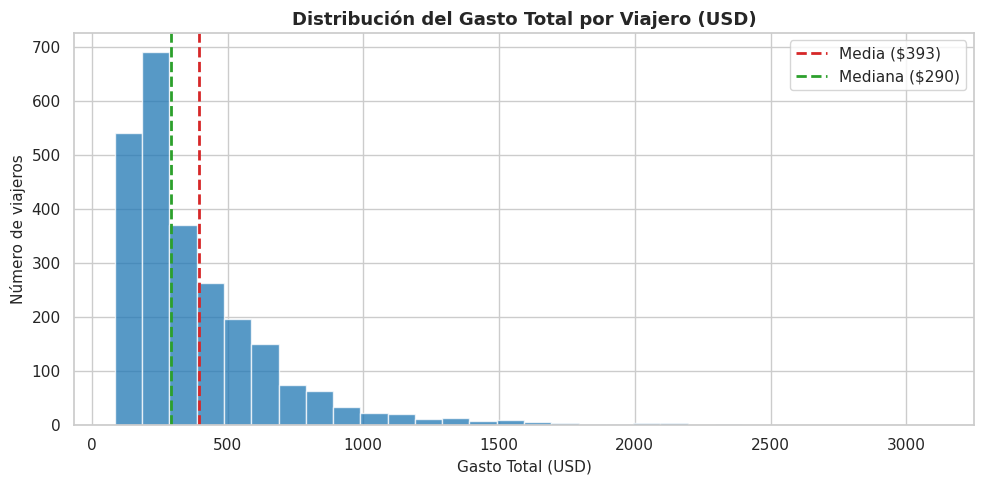

In [17]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

media_gasto = df['Gasto_Total_USD'].mean()
mediana_gasto = df['Gasto_Total_USD'].median()

plt.hist(df['Gasto_Total_USD'], bins=30, color='#1f77b4', alpha=0.75, edgecolor='white')
plt.axvline(media_gasto, color='#d62728', linestyle='--', linewidth=2, label=f'Media (${media_gasto:.0f})')
plt.axvline(mediana_gasto, color='#2ca02c', linestyle='--', linewidth=2, label=f'Mediana (${mediana_gasto:.0f})')

plt.title('Distribución del Gasto Total por Viajero (USD)', fontsize=13, fontweight='bold')
plt.xlabel('Gasto Total (USD)', fontsize=11)
plt.ylabel('Número de viajeros', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()


Descripción de la Gráfica 1:

La distribución está sesgada a la derecha (la media, USD 393, es mayor que la mediana, USD 290), con una cola larga de viajeros de gasto alto (principalmente viajeros de negocios y clase ejecutiva) y una concentración de la mayoría de registros en gastos bajos y medios.

#### Gráfica 2: Gasto Total por Clase Tarifaria (Categórica × Numérica)

Boxplot que compara la distribución del gasto entre las 3 categorías de Clase_Tarifaria — un cruce que solo es posible al contar con variables categóricas.

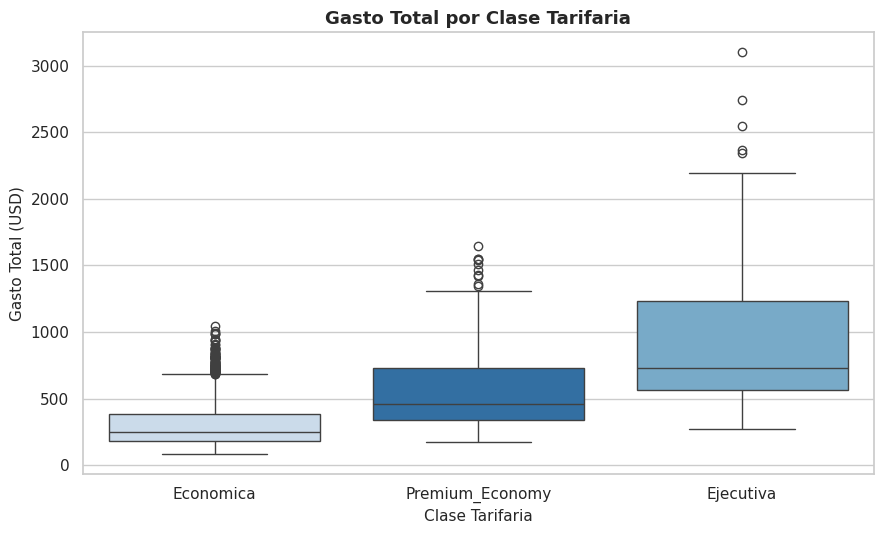

In [18]:
plt.figure(figsize=(9, 5.5))
orden_clase = ['Economica', 'Premium_Economy', 'Ejecutiva']

sns.boxplot(data=df, x='Clase_Tarifaria', y='Gasto_Total_USD', order=orden_clase,
            hue='Clase_Tarifaria', palette='Blues', legend=False)

plt.title('Gasto Total por Clase Tarifaria', fontsize=13, fontweight='bold')
plt.xlabel('Clase Tarifaria', fontsize=11)
plt.ylabel('Gasto Total (USD)', fontsize=11)
plt.tight_layout()
plt.show()

Descripción de la Gráfica 2:

Las medianas de gasto crecen de Económica a Ejecutiva. 

En Económica, la caja va de Q1=USD 180 a Q3=USD 383 (mediana USD 247), con el bigote superior hasta USD 687 y 93 puntos por encima de ese límite (viajeros con gasto atípicamente alto para su clase). 

En Premium_Economy, la caja va de Q1=USD 338 a Q3=USD 727 (mediana USD 461), bigote superior hasta USD 1.308 y 10 puntos por encima. 

En Ejecutiva, la caja es la más ancha y más alta: Q1=USD 563 a Q3=USD 1.233 (mediana USD 728), bigote superior hasta USD 2.192 y 5 puntos por encima de ese límite. 

En las tres clases no se registran valores atípicos por debajo del bigote inferior; todos los puntos fuera de rango están por encima del límite superior.

#### Gráfica 3: Frecuencia de Motivo de Viaje por País

Gráfico de barras apiladas con los conteos de la tabla de contingencia Pais × Motivo_Viaje calculada en el punto 5.3.1.

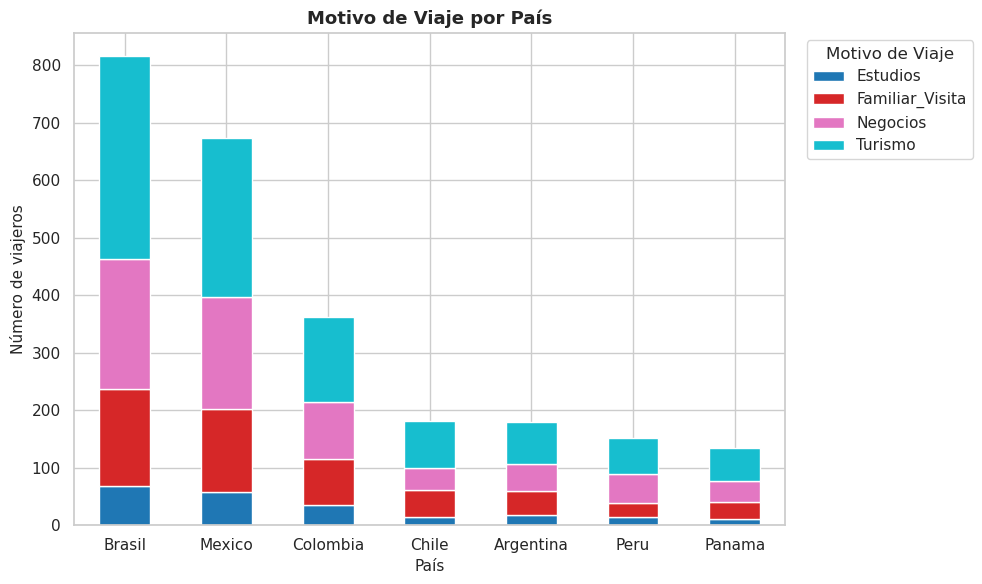

In [19]:
tabla_barras = pd.crosstab(df['Pais'], df['Motivo_Viaje'])
tabla_barras = tabla_barras.loc[tabla_barras.sum(axis=1).sort_values(ascending=False).index]

tabla_barras.plot(kind='bar', stacked=True, figsize=(10, 6),
                   colormap='tab10', edgecolor='white')

plt.title('Motivo de Viaje por País', fontsize=13, fontweight='bold')
plt.xlabel('País', fontsize=11)
plt.ylabel('Número de viajeros', fontsize=11)
plt.xticks(rotation=0)
plt.legend(title='Motivo de Viaje', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Descripción de la Gráfica 3: 

Turismo es la barra más grande en los 7 países, seguida de Negocios; Estudios es, en todos los casos, el segmento más pequeño. Brasil y México, al tener mayor cantidad de registros en la muestra, presentan las barras totales más altas.

#### Gráfica 4: Distancia vs. Gasto Total, diferenciado por Tipo de Vuelo

Diagrama de dispersión entre dos variables numéricas (Distancia_KM y Gasto_Total_USD), coloreado por la categoría Tipo_Vuelo (Doméstico / Internacional).

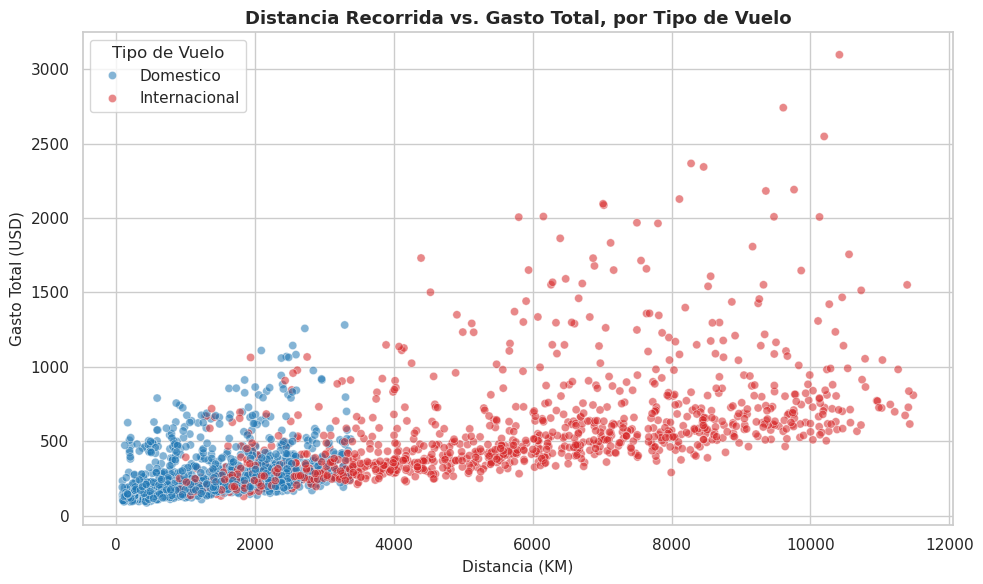

In [20]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='Distancia_KM', y='Gasto_Total_USD', hue='Tipo_Vuelo',
                alpha=0.55, s=35, palette={'Domestico': '#1f77b4', 'Internacional': '#d62728'})

plt.title('Distancia Recorrida vs. Gasto Total, por Tipo de Vuelo', fontsize=13, fontweight='bold')
plt.xlabel('Distancia (KM)', fontsize=11)
plt.ylabel('Gasto Total (USD)', fontsize=11)
plt.legend(title='Tipo de Vuelo')
plt.tight_layout()
plt.show()

#### Descripción de la Gráfica 4:

Los vuelos Domésticos (n=1.416) se concentran entre 90 y 3.393 km (media 1.405 km) con un gasto entre USD 85 y USD 1.281 (media USD 261). Los vuelos Internacionales (n=1.084) van de 913 a 11.483 km (media 5.617 km) con un gasto entre USD 128 y USD 3.099 (media USD 566) — más del doble del gasto promedio doméstico.

La nube de puntos roja (Internacional) se ubica sistemáticamente a la derecha y por encima de la nube azul (Doméstico), con una zona de traslape moderada entre los ~900 y ~3.400 km. Dentro de cada grupo la relación entre distancia y gasto es positiva (correlación de 0.40 en Doméstico y 0.54 en Internacional), y ambas son menores a la correlación global de 0.67, lo que indica que parte de esa relación general responde a la diferencia entre los dos tipos de vuelo.

#### Conclusión General del Punto 6 (Visualización)

Por qué el gasto promedio es más alto que el gasto típico: porque hay un grupo de viajeros de clase Ejecutiva y de vuelos Internacionales que gastan mucho más que el resto, y eso hala la media hacia arriba (Gráficas 1, 2 y 4).

Por qué la mayoría de los datos están en gastos bajos: porque el motivo de viaje más común es Turismo, que generalmente se hace en clase Económica y en vuelos cortos, es decir, en las combinaciones más baratas (Gráficas 3, 2 y 4).

Por qué clase tarifaria y tipo de vuelo cuentan una historia parecida: porque ambas variables 
separan a los viajeros en los mismos dos grupos: uno de gasto bajo (Económica / Doméstico) y otro de gasto alto (Ejecutiva / Internacional).

En resumen, las cuatro gráficas muestran lo mismo desde ángulos distintos: el gasto de un viajero depende sobre todo del tipo de viaje que hace, no de un comportamiento parecido para todos.

## 7. Modelado Predictivo con numpy.polyfit ##

En la Actividad 2 la regresión se hizo sobre dos series de tiempo (año vs. pasajeros, y Brasil vs. Colombia). En esta base no existe una serie temporal —el campo Anio es constante (2022) para todos los registros—, por lo que el ejercicio de regresión se traslada a nivel de viajero individual.

#### 7.0. Agrupación de Variables y Evaluación Previa de Correlaciones

Variable dependiente (Y): Gasto_Total_USD es la única variable de interés a explicar en este ejercicio, por lo que se fija como Y en cualquier regresión que se plantee.

Variables independientes candidatas (X): el resto de variables numéricas de la base — Edad, Tamano_Grupo, Distancia_KM, Duracion_Viaje_Dias, Anticipacion_Compra_Dias y Viajes_Ultimo_Anio.

Antes de ajustar cualquier modelo con numpy.polyfit(), es necesario evaluar la correlación de todas las variables candidatas contra la variable dependiente, para elegir la pareja X–Y con evidencia y no de forma arbitraria.

In [22]:
# 7.0.1. Matriz de correlación entre TODAS las variables numéricas
cols_numericas_relevantes = ['Edad', 'Tamano_Grupo', 'Distancia_KM', 'Duracion_Viaje_Dias',
                              'Anticipacion_Compra_Dias', 'Viajes_Ultimo_Anio', 'Gasto_Total_USD']

matriz_corr = df[cols_numericas_relevantes].corr().round(3)
matriz_corr

,Edad,Tamano_Grupo,Distancia_KM,Duracion_Viaje_Dias,Anticipacion_Compra_Dias,Viajes_Ultimo_Anio,Gasto_Total_USD
Edad,1.000,-0.002,0.002,-0.001,-0.002,-0.006,-0.008
Tamano_Grupo,-0.002,1.000,-0.025,-0.095,0.135,-0.356,-0.085
Distancia_KM,0.002,-0.025,1.000,-0.005,0.012,-0.006,0.665
Duracion_Viaje_Dias,-0.001,-0.095,-0.005,1.000,0.120,-0.231,-0.089
Anticipacion_Compra_Dias,-0.002,0.135,0.012,0.120,1.000,-0.209,-0.031
Viajes_Ultimo_Anio,-0.006,-0.356,-0.006,-0.231,-0.209,1.000,0.111
Gasto_Total_USD,-0.008,-0.085,0.665,-0.089,-0.031,0.111,1.000


#### Gasto_Total_USD como variable dependiente:

Evidencia estadística: es la variable involucrada en la correlación más fuerte de toda la matriz (0.665 con Distancia_KM). Si el objetivo es construir un modelo de regresión con el mayor poder explicativo posible, Gasto_Total_USD es la que ofrece la señal más clara para ser modelada.

Coherencia conceptual: Gasto_Total_USD es, por naturaleza, un resultado del viaje (lo que terminó costando), mientras que Edad, Tamano_Grupo, Distancia_KM, Duracion_Viaje_Dias, Anticipacion_Compra_Dias y Viajes_Ultimo_Anio son características o decisiones previas del viajero y del viaje (quién es, a dónde va, cuánto dura, con cuánta anticipación compra). Es más razonable modelar el gasto en función de esas características, que a la inversa.

Consistencia con el objetivo del ejercicio: desde el punto 5 (medidas descriptivas) y el punto 6 (visualización) ya se venía analizando Gasto_Total_USD como la variable de interés central (por país, por clase tarifaria, por tipo de vuelo). Mantenerla como Y en el modelo de regresión conserva esa misma línea de análisis.

In [24]:
# 7.0.2. Correlación de cada variable candidata contra Gasto_Total_USD
corr_vs_gasto = matriz_corr['Gasto_Total_USD'].drop('Gasto_Total_USD').sort_values(
    key=abs, ascending=False
)
corr_vs_gasto


Distancia_KM                0.665
Viajes_Ultimo_Anio          0.111
Duracion_Viaje_Dias        -0.089
Tamano_Grupo               -0.085
Anticipacion_Compra_Dias   -0.031
Edad                       -0.008
Name: Gasto_Total_USD, dtype: float64

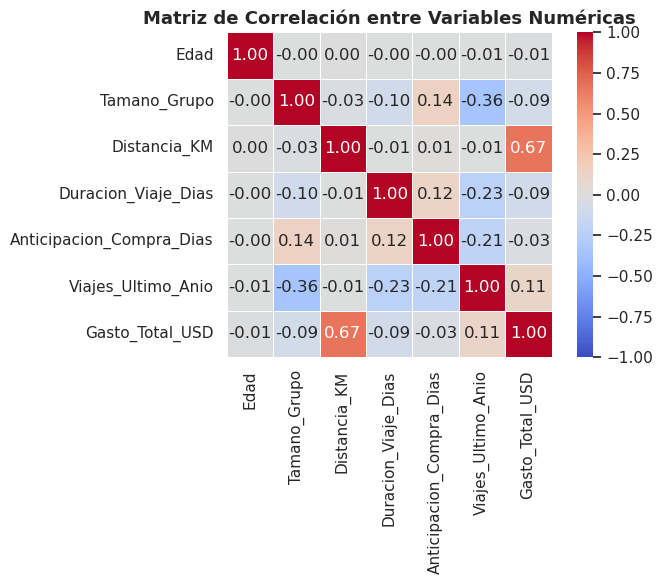

In [25]:
# 7.0.3. Mapa de calor de la matriz de correlación
plt.figure(figsize=(7.5, 6))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Matriz de Correlación entre Variables Numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


#### **Complemento visual — pairplot** ####
La matriz de correlación resume cada relación en un solo número, pero no muestra su forma. El pairplot de Seaborn sí lo hace: grafica cada pareja de variables numéricas como dispersión (y su distribución individual en la diagonal). Se aplica solo entre las 7 variables numéricas —entre categóricas no tiene sentido, ya que no hay una posición numérica que graficar; ese caso ya se cubre con tablas de contingencia y chi-cuadrado—, pero se le agrega la variable Tipo_Vuelo como color (hue) para ver si el patrón cambia según esa categoría, sin mezclar tipos de variable en el propio gráfico.

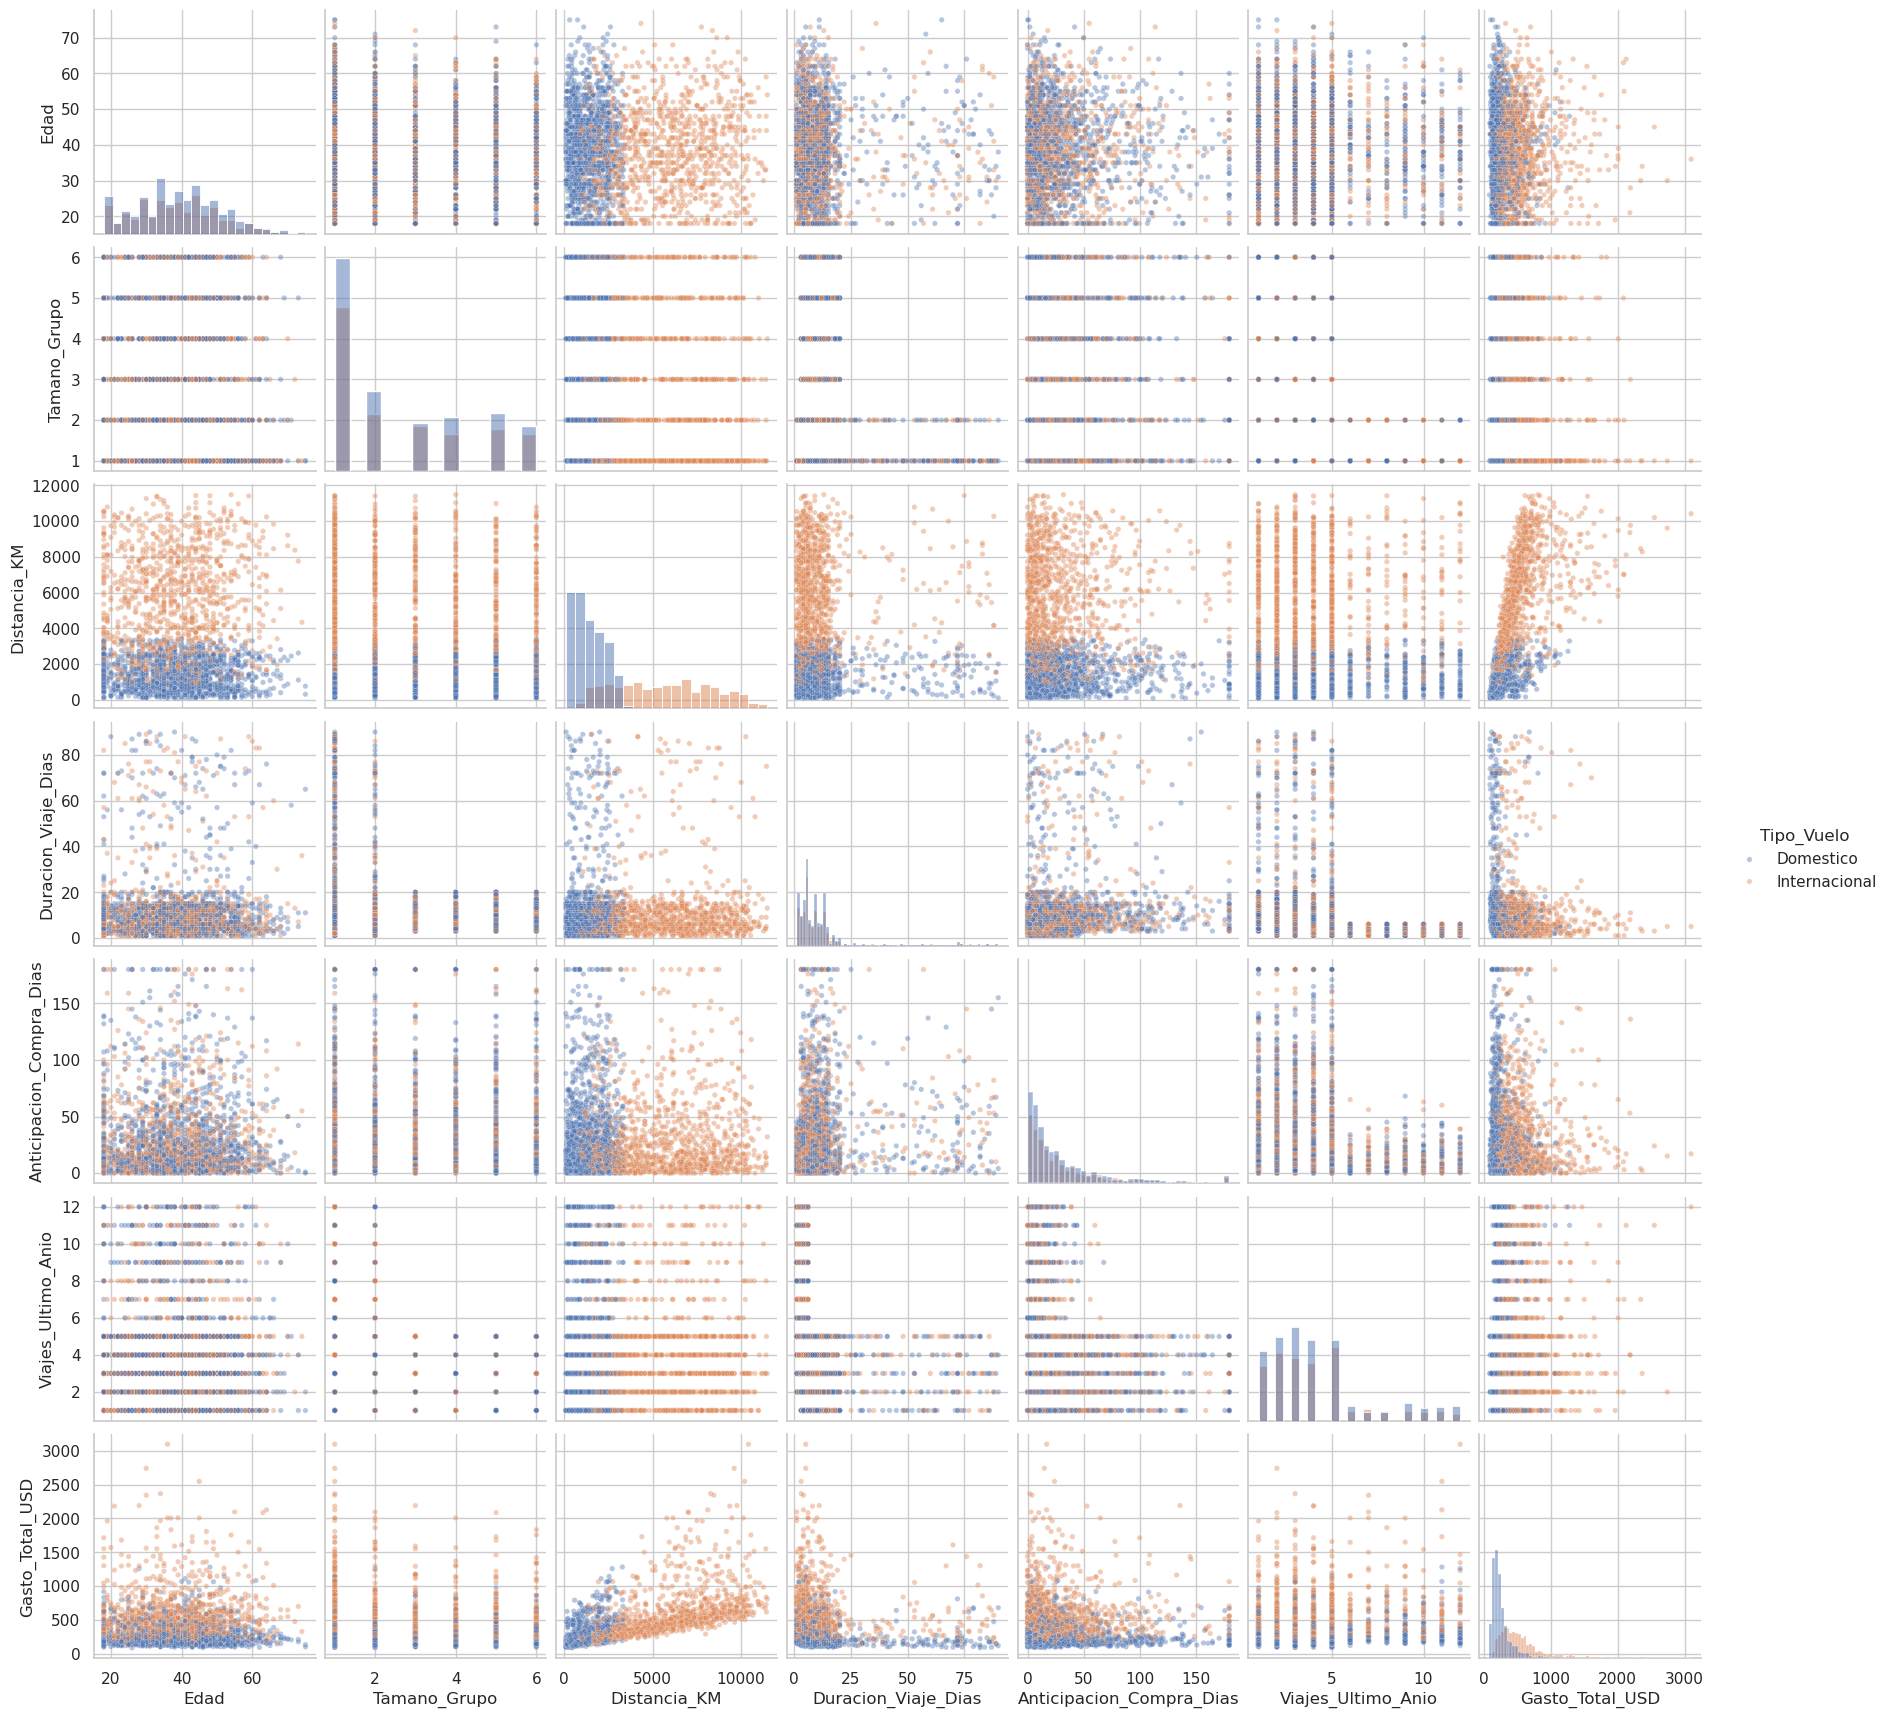

In [32]:
# 7.0.4. Pairplot de las variables numéricas, coloreado por Tipo_Vuelo
sns.pairplot(
    df[cols_numericas_relevantes + ['Tipo_Vuelo']],
    hue='Tipo_Vuelo', diag_kind='hist',
    plot_kws={'alpha': 0.4, 's': 15}
)
plt.show()

#### **Resultado gráfico del pairplot** ####

Confirma visualmente lo que ya decía la matriz de correlación — solo la pareja Distancia_KM – Gasto_Total_USD (fila/columna inferior izquierda) muestra una forma ascendente clara; el resto de combinaciones son nubes de puntos sin patrón reconocible. 

El color por Tipo_Vuelo añade un detalle nuevo: los vuelos Internacionales (naranja) ocupan la zona de mayor distancia y mayor gasto, mientras que los Domésticos (azul) se concentran en el extremo opuesto — el mismo hallazgo ya visto en la Gráfica 4 del punto 6, ahora confirmado desde una vista distinta.

 Distancia_KM es, por un margen amplio, la variable con la correlación más fuerte frente a Gasto_Total_USD (r = 0.665). El resto de variables numéricas (Edad, Tamaño de grupo, Duración del viaje, Anticipación de compra, Viajes en el último año) presentan correlaciones muy débiles, entre -0.09 y 0.11. Con esta evidencia, la pareja seleccionada para el modelo de regresión es Distancia_KM (X) → Gasto_Total_USD (Y), que se desarrolla a continuación.

#### 7.1. Regresión Lineal Simple: Distancia_KM (X) vs. Gasto_Total_USD (Y)

La lógica de la relación es: a mayor distancia recorrida, se espera un mayor gasto total (tarifas más costosas, más noches de estadía, etc.).

In [26]:
# 7.1. Regresión lineal simple: Distancia_KM (X) vs. Gasto_Total_USD (Y)
x = df['Distancia_KM'].to_numpy(dtype=float)
y = df['Gasto_Total_USD'].to_numpy(dtype=float)

coef_lineal = np.polyfit(x, y, 1)
p_lineal = np.poly1d(coef_lineal)
y_pred_lin = p_lineal(x)

r_corr = np.corrcoef(x, y)[0, 1]
r2_lineal = 1 - (np.sum((y - y_pred_lin)**2) / np.sum((y - np.mean(y))**2))

print("=== REGRESIÓN LINEAL: DISTANCIA (X) VS. GASTO TOTAL (Y) ===")
print(f"Ecuación: Y = {coef_lineal[0]:.4f}X + ({coef_lineal[1]:.4f})")
print(f"Coeficiente de correlación (r): {r_corr:.4f}")
print(f"Coeficiente de determinación (R²): {r2_lineal:.4f}")

=== REGRESIÓN LINEAL: DISTANCIA (X) VS. GASTO TOTAL (Y) ===
Ecuación: Y = 0.0729X + (157.9482)
Coeficiente de correlación (r): 0.6652
Coeficiente de determinación (R²): 0.4425


**Ecuación: Y = 0.0729X + (157.9482)**

Es la fórmula de la recta que mejor "resume" la nube de 2.500 puntos. Se lee así:

157.9482 es el punto de partida: si un viaje tuviera 0 km de distancia, el modelo diría que igual gasta cerca de USD 158 (piensa en esto como un "costo base" del viaje, aunque en la realidad nadie viaja 0 km — es solo el punto donde arranca la recta).
0.0729 es cuánto sube el gasto por cada kilómetro adicional. Como es un número pequeño, para verlo más claro conviene pensarlo en tramos más grandes: por cada 1.000 km más de distancia, el gasto esperado sube unos USD 73.

**Coeficiente de correlación (r): 0.6652**

Mide qué tan "acompañadas" se mueven las dos variables, en una escala de -1 a 1:

0 = no tienen ninguna relación.
1 = relación perfecta y positiva (cuando una sube, la otra sube siempre en la misma proporción).
-1 = relación perfecta pero inversa.

0.66 es una relación moderada a fuerte, y positiva: cuando la distancia aumenta, el gasto tiende a aumentar también, aunque no de forma perfecta — hay bastante variación alrededor de esa tendencia (viajeros con la misma distancia que gastan cosas muy distintas).

**Coeficiente de determinación (R²): 0.4425**

Responde a la pregunta: "¿qué porcentaje del gasto queda explicado solo por la distancia?"

0.4425 = 44.25%. Es decir, si solo supieras cuántos kilómetros voló una persona, podrías explicar el 44% de por qué gastó lo que gastó. El 55.75% restante depende de otras cosas que el modelo no está viendo aquí — como la clase tarifaria, el tipo de aerolínea, el motivo del viaje o la temporada (todo lo que ya se analizó en los puntos 5 y 6).

La distancia sí importa para explicar el gasto, y la relación es clara y positiva, pero está lejos de ser la única causa — por eso el R² no es cercano a 1.

**La relación entre r y R²**:

Con una sola variable X, el R² es simplemente r al cuadrado: R² = r².

Se comprueba: 0.6652² = 0.4425. No es casualidad, es una propiedad matemática que siempre se cumple en este caso.

Por qué:

r indica hacia dónde va la relación (positiva o negativa, por eso va de -1 a 1).
R² indica cuánto explica el modelo, sin importar la dirección — por eso siempre es positivo (es un cuadrado).

Lo importante: al elevar al cuadrado, se pierde el signo. Por eso r y R² se reportan juntos: R² indica "explica el 44%", pero solo r indica si es "a más X, más Y" o "a más X, menos Y".

En este caso: r = 0.6652 (positivo) y R² = 0.4425 → la distancia explica el 44% del gasto, y esa relación es directa: a mayor distancia, mayor gasto.

## 8. Conclusión Final Actividad 2 ##

Este ejercicio permitió caracterizar al viajero aéreo en Colombia y en los principales mercados de Latinoamérica combinando, por primera vez en este análisis, variables numéricas y categóricas sobre una misma base de datos.

La base de datos quedó limpia, correctamente tipificada y con una distribución geográfica definida para el ejercicio de 2022 (punto 4).

Las medidas descriptivas caracterizaron al viajero típico (masculino, 36-45 años, vuelo doméstico, motivo turismo, clase económica) y un gasto promedio de USD 393, con Colombia por debajo del promedio regional (punto 5).

La visualización mostró que la clase tarifaria, el tipo de vuelo y el motivo de viaje separan sistemáticamente a los viajeros de gasto bajo de los de gasto alto (punto 6).

La evaluación de correlaciones estableció que, entre las variables numéricas, Distancia_KM es la única con relación fuerte frente al gasto (r = 0.665), y que el modelo lineal resultante explica el 44.25% de su variación (punto 7).

El hallazgo central es que el gasto del viajero no responde a una sola causa, sino a una combinación de características —numéricas y categóricas— del viaje. Esa conclusión abre directamente el alcance de la siguiente actividad, "Actividad práctica contraste de hipótesis y regresión logística": las diferencias de gasto encontradas entre grupos (países, clases tarifarias, tipos de vuelo) son precisamente las que se someterán a contraste de hipótesis para confirmar si son estadísticamente significativas; las variables numéricas ya evaluadas en el punto 7.0 son la base para construir un modelo de regresión lineal múltiple con varias variables independientes en simultáneo; y las variables categóricas binarias ya identificadas permiten plantear un modelo de regresión logística para predecir pertenencia a una categoría en lugar de un valor continuo.


# Actividad Práctica 4 : Contraste de Hipótesis y Regresión Logística

## Hacia Dónde Puede Avanzar este Análisis: Introducción a la Actividad Práctica 4 ##
La "Actividad práctica contraste de hipótesis y regresión logística" retoma este análisis exploratorio para avanzar hacia tres herramientas nuevas: contraste de hipótesis (scipy.stats), regresión lineal múltiple y regresión logística (ambas con scikit-learn). Lo trabajado en los puntos 4 a 7 ya deja identificadas las variables para cada una:


a) Contraste de hipótesis: ya se vieron diferencias de gasto entre países (Brasil USD 421 vs. Panamá USD 318, punto 5.1) y entre clase tarifaria y tipo de vuelo (punto 6). Cualquiera de estos cruces sirve como hipótesis a probar: t de dos muestras para comparar el gasto medio entre dos grupos, o chi-cuadrado para probar independencia entre categorías como Clase_Tarifaria y Tipo_Aerolinea (punto 5.3.2).

b) Regresión lineal múltiple: el punto 7.0 mostró que Distancia_KM es la variable con relación más fuerte con Gasto_Total_USD, pero esta actividad pide al menos 3 variables independientes continuas a la vez. Las candidatas son las mismas del punto 7.0: Distancia_KM, Duracion_Viaje_Dias, Anticipacion_Compra_Dias, Tamano_Grupo y Viajes_Ultimo_Anio, prediciendo Gasto_Total_USD.

c) Regresión logística: necesita una variable continua y una binaria. Ya hay varias binarias listas para usar sin crear umbrales artificiales: Compra_Anticipada, Miembro_Programa_Fidelidad o Tipo_Vuelo, combinadas con Gasto_Total_USD.

In [28]:
# Vista previa de las variables candidatas para la siguiente actividad
print("Variable dependiente (regresión lineal múltiple):")
print("  - Gasto_Total_USD\n")

print("Variables independientes continuas candidatas (regresión lineal múltiple):")
print("  - Distancia_KM, Duracion_Viaje_Dias, Anticipacion_Compra_Dias,")
print("    Tamano_Grupo, Viajes_Ultimo_Anio\n")

print("Variables binarias candidatas (regresión logística):")
for col in ['Compra_Anticipada', 'Miembro_Programa_Fidelidad', 'Tipo_Vuelo']:
    print(f"  - {col}: {df[col].unique().tolist()}")

Variable dependiente (regresión lineal múltiple):
  - Gasto_Total_USD

Variables independientes continuas candidatas (regresión lineal múltiple):
  - Distancia_KM, Duracion_Viaje_Dias, Anticipacion_Compra_Dias,
    Tamano_Grupo, Viajes_Ultimo_Anio

Variables binarias candidatas (regresión logística):
  - Compra_Anticipada: ['No', 'Si']
  - Miembro_Programa_Fidelidad: ['No', 'Si']
  - Tipo_Vuelo: ['Domestico', 'Internacional']


## 9. Planteamiento de la Hipótesis ##

Retomando la pregunta de entrada: desde el punto 2 (Objetivo General) el ejercicio se planteó evaluar la posición de Colombia frente a los principales mercados de Latinoamérica. Esa misma pregunta, aplicada ahora a nivel de viajero individual y a la variable Gasto_Total_USD, se traduce en: ¿cómo se posiciona el gasto por viajero en Colombia frente al del resto de LATAM? El contraste de hipótesis que se desarrolla a continuación es la forma estadísticamente rigurosa de responder esa misma pregunta.
 
Antes de agrupar los 6 países en un solo bloque "Resto LATAM", se muestra primero el gasto promedio de cada país por separado.

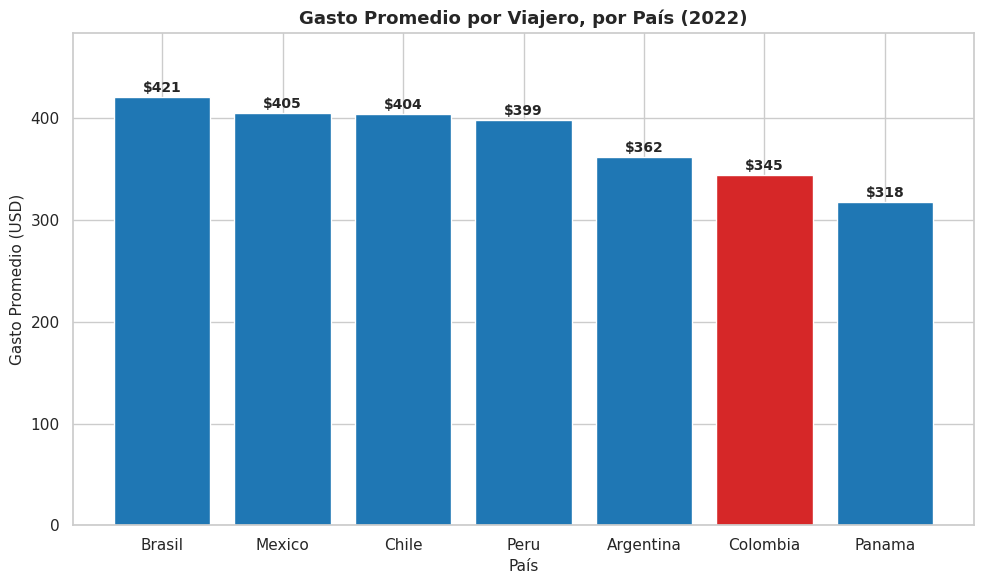

In [29]:
# Script 1: gasto promedio por viajero, país por país
gasto_por_pais_prom = df.groupby('Pais', observed=True)['Gasto_Total_USD'].mean().sort_values(ascending=False)

colores = ['#d62728' if pais == 'Colombia' else '#1f77b4' for pais in gasto_por_pais_prom.index]

plt.figure(figsize=(10, 6))
barras = plt.bar(gasto_por_pais_prom.index, gasto_por_pais_prom.values, color=colores, edgecolor='white')

for barra, valor in zip(barras, gasto_por_pais_prom.values):
    plt.text(barra.get_x() + barra.get_width()/2, valor + 5, f'${valor:.0f}',
             ha='center', fontsize=10, fontweight='bold')

plt.title('Gasto Promedio por Viajero, por País (2022)', fontsize=13, fontweight='bold')
plt.xlabel('País', fontsize=11)
plt.ylabel('Gasto Promedio (USD)', fontsize=11)
plt.ylim(0, max(gasto_por_pais_prom.values) * 1.15)
plt.tight_layout()
plt.show()

Lectura: Brasil (USD 421), México (USD 405) y Chile (USD 404) encabezan el gasto promedio por viajero; Colombia (USD 345, en rojo) se ubica en el sexto lugar de los 7 países, solo por encima de Panamá (USD 318).

Para el contraste de hipótesis planteado a analizar es necesario un cálculo distinto, que no se había hecho todavía: agrupar los 6 países restantes en un solo grupo ("Resto LATAM") y compararlo contra Colombia.

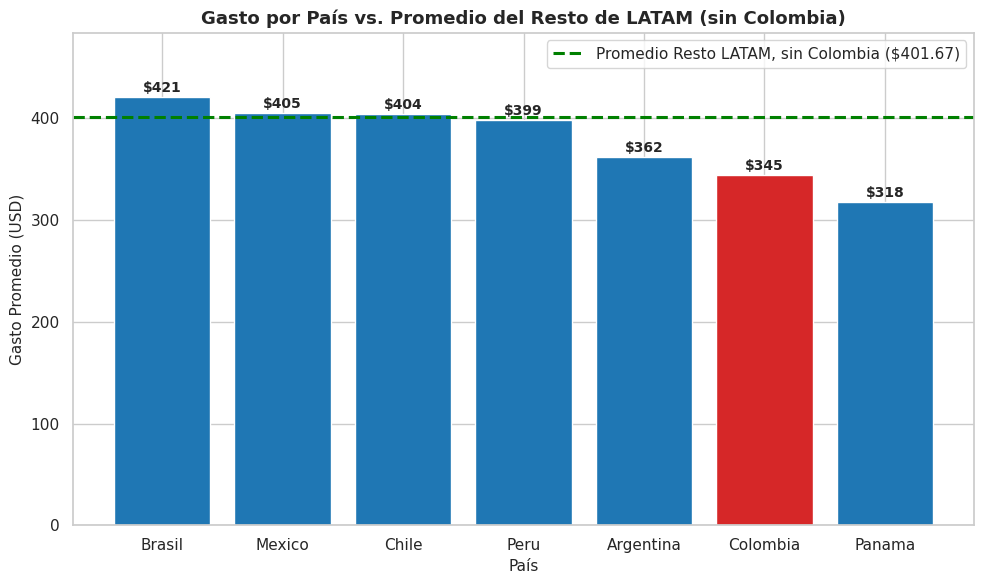


Colombia:      n=363   media=$344.75   desv.est=$287.17
Resto LATAM:   n=2137   media=$401.67   desv.est=$311.47

Diferencia observada de medias: $56.92


In [64]:
# Script 2: construcción del grupo "Resto LATAM" y su promedio, como línea de referencia
gasto_colombia = df.loc[df['Pais'] == 'Colombia', 'Gasto_Total_USD']
gasto_resto_latam = df.loc[df['Pais'] != 'Colombia', 'Gasto_Total_USD']
media_resto_latam = gasto_resto_latam.mean()

plt.figure(figsize=(10, 6))
barras = plt.bar(gasto_por_pais_prom.index, gasto_por_pais_prom.values, color=colores, edgecolor='white')

plt.axhline(media_resto_latam, color='green', linestyle='--', linewidth=2.2,
            label=f'Promedio Resto LATAM, sin Colombia (${media_resto_latam:.2f})')

for barra, valor in zip(barras, gasto_por_pais_prom.values):
    plt.text(barra.get_x() + barra.get_width()/2, valor + 5, f'${valor:.0f}',
             ha='center', fontsize=10, fontweight='bold')

plt.title('Gasto por País vs. Promedio del Resto de LATAM (sin Colombia)', fontsize=13, fontweight='bold')
plt.xlabel('País', fontsize=11)
plt.ylabel('Gasto Promedio (USD)', fontsize=11)
plt.ylim(0, max(gasto_por_pais_prom.values) * 1.15)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f"\nColombia:      n={len(gasto_colombia)}   media=${gasto_colombia.mean():.2f}   desv.est=${gasto_colombia.std():.2f}")
print(f"Resto LATAM:   n={len(gasto_resto_latam)}   media=${gasto_resto_latam.mean():.2f}   desv.est=${gasto_resto_latam.std():.2f}")
print(f"\nDiferencia observada de medias: ${gasto_resto_latam.mean() - gasto_colombia.mean():.2f}")

**Cálculo del numero "Resto LATAM":** de los 2.500 registros, 363 corresponden a Colombia y los 2.137 restantes a los otros 6 países (Brasil, México, Chile, Perú, Argentina y Panamá). El promedio de USD 401.67 (línea verde) es simplemente el promedio del gasto de esos 2.137 registros combinados —no el promedio de los 6 promedios por país—, por lo que refleja el peso real de cada país en la muestra (Brasil y México, al tener más registros, influyen más en ese promedio combinado que Panamá o Perú). En la gráfica se ve claramente que la barra de Colombia queda por debajo de esa línea de referencia.

**Aspecto a investigar:** con este cálculo queda establecida una diferencia de USD 56.92 entre el gasto promedio de Colombia (USD 344.75) y el del resto de LATAM (USD 401.67). La pregunta que guía el contraste de hipótesis es:

**¿esa diferencia observada en la muestra es lo suficientemente grande como para afirmar que existe una diferencia real en el gasto promedio de la población de viajeros colombianos frente a la del resto de LATAM, o pudo haber ocurrido por azar?**

**Hipótesis nula (H0):** no existe diferencia significativa entre el gasto promedio de los viajeros colombianos y el gasto promedio de los viajeros del resto de los mercados de Latinoamérica.
 

**Hipótesis alternativa (H1):** existe una diferencia significativa entre el gasto promedio de los viajeros colombianos y el gasto promedio de los viajeros del resto de los mercados de Latinoamérica
 
Verificabilidad: ambas hipótesis se pueden contrastar de forma estadística, comparando las medias de Gasto_Total_USD de los dos grupos independientes calculados arriba, mediante una prueba de diferencia de medias (t de dos muestras) con scipy.stats.

## 10. Verificación: ¿H0 y H1 son Mutuamente Excluyentes y Colectivamente Exhaustivas? ##

Antes de probar nada, hay que revisar dos cosas: que H0 y H1 no puedan ser ciertas al mismo tiempo (excluyentes), y que entre las dos cubran todos los casos posibles, sin dejar nada por fuera (exhaustivas).

En este caso:

H0 dice que el promedio de Colombia y el del resto de LATAM son iguales.

H1 dice que son distintos, sin decir cuál de los dos es mayor.


Entre dos promedios solo hay tres opciones: que sean iguales, que el de Colombia sea mayor, o que el de Colombia sea menor. H0 se queda con la opción "iguales"; H1 se queda con las otras dos opciones juntas ("mayor" y "menor"), sin distinguir entre ellas.

¿Excluyentes? Sí. Si son iguales, no pueden ser distintas, y al revés.
¿Exhaustivas? Sí. No queda ningún caso por fuera de las dos.
Como H1 junta las dos direcciones posibles (mayor y menor) en una sola hipótesis, la prueba debe hacerse a dos colas. Si se probara solo una dirección (por ejemplo, que Colombia gasta más que el resto de LATAM), la otra dirección quedaría sin cubrir y se rompería la exhaustividad.

## 11. Selección de la Prueba Estadística ##

    
Prueba seleccionada: t de Welch para dos muestras independientes, a dos colas.

La elección se basa en las características concretas de los datos con los que se está trabajando:

Variable a comparar: Gasto_Total_USD es numérica continua, y se compara su promedio entre exactamente 2 grupos (Colombia y Resto LATAM). Este escenario corresponde directamente a una prueba t de dos muestras — no a chi-cuadrado (que es para dos variables categóricas) ni a ANOVA (que aplica con 3 o más grupos).

Grupos independientes: cada viajero pertenece a un solo grupo (es de Colombia o del resto de LATAM, nunca ambos), por lo que las dos muestras no están emparejadas.

Variante de Welch, no la t clásica: el punto 5.1.2 ya mostró que las desviaciones estándar de los dos grupos son distintas (Colombia USD 287 vs. Resto LATAM USD 311). La t clásica asume varianzas iguales entre grupos; Welch no lo asume, por lo que es la opción más segura aquí.

Tamaños de muestra grandes (363 y 2.137): aunque el histograma del punto 6 mostró que Gasto_Total_USD no sigue una distribución normal (está sesgado a la derecha), con muestras de este tamaño el promedio de cada grupo sí se comporta de forma aproximadamente normal (Teorema del Límite Central), lo que hace válido usar una prueba t en vez de recurrir a una alternativa no paramétrica como Mann-Whitney.

Dos colas, no una: ya se estableció en el punto 10 que H1 ("las medias son distintas") cubre tanto "Colombia > Resto LATAM" como "Colombia < Resto LATAM" en una sola hipótesis, por lo que la región de rechazo debe repartirse en ambos extremos de la distribución.

Nivel de significancia: se fija α = 0.05, el valor convencional en ciencias sociales y de negocio, que representa un 5% de probabilidad de rechazar H0 por error cuando en realidad es cierta.

## 12. Ejecución de la Prueba con scipy.stats ##

Se usa scipy.stats.ttest_ind() sobre los dos grupos ya calculados en el punto 9 (gasto_colombia y gasto_resto_latam). Los parámetros elegidos son:

equal_var=False: activa la variante de Welch, justificada en el punto 11 por la diferencia de varianzas entre los dos grupos.

alternative='two-sided': hace explícito que la prueba es a dos colas, justificado en el punto 10 porque H1 cubre tanto "mayor" como "menor" en una sola hipótesis.

In [33]:
from scipy import stats

resultado_ttest = stats.ttest_ind(
    gasto_colombia, gasto_resto_latam,
    equal_var=False,
    alternative='two-sided'
)

print("=== PRUEBA T DE WELCH: COLOMBIA VS. RESTO LATAM (GASTO_TOTAL_USD) ===")
print(f"Estadístico t: {resultado_ttest.statistic:.4f}")
print(f"Grados de libertad: {resultado_ttest.df:.2f}")
print(f"P-valor (dos colas): {resultado_ttest.pvalue:.6f}")

=== PRUEBA T DE WELCH: COLOMBIA VS. RESTO LATAM (GASTO_TOTAL_USD) ===
Estadístico t: -3.4475
Grados de libertad: 517.63
P-valor (dos colas): 0.000612


Estadístico t = -3.4475: dice qué tan lejos está la diferencia encontrada (Colombia gasta menos) de "no hay diferencia" (que sería cero), medido en una escala común. El signo negativo solo indica que Colombia quedó por debajo del Resto LATAM (se restó Colombia menos Resto LATAM); lo que importa para juzgar qué tan grande es la diferencia es el valor sin el signo (3.4475

Grados de libertad = 517.63: es un número de apoyo que usa la fórmula de Welch para calcular el p-valor correctamente cuando los dos grupos tienen tamaños y varianzas distintas. No hace falta interpretarlo más allá de eso.

P-valor = 0.000612: es la probabilidad de haber obtenido una diferencia tan grande como esta, si en realidad Colombia y el Resto de LATAM gastaran lo mismo en promedio. Cuanto más chico es este número, menos creíble es que la diferencia se deba solo al azar. Se interpreta formalmente en el siguiente punto, comparándolo contra α = 0.05.

## 13. Interpretación de los Resultados ##

Se compara el p-valor obtenido contra el nivel de significancia fijado en el punto 11 (α = 0.05), siguiendo la regla de decisión estándar:

Si p-valor < α → se rechaza H0.

Si p-valor ≥ α → no se rechaza H0.

In [34]:
alpha = 0.05
p_valor = resultado_ttest.pvalue

print(f"Estadístico t:  {resultado_ttest.statistic:.4f}")
print(f"P-valor:        {p_valor:.6f}")
print(f"Alfa:           {alpha}")

if p_valor < alpha:
    print("\nDecisión: se RECHAZA H0 (hay evidencia suficiente para afirmar que las medias son distintas)")
else:
    print("\nDecisión: NO se rechaza H0 (no hay evidencia suficiente para afirmar que las medias son distintas)")

Estadístico t:  -3.4475
P-valor:        0.000612
Alfa:           0.05

Decisión: se RECHAZA H0 (hay evidencia suficiente para afirmar que las medias son distintas)


**El p-valor (0.000612) es mucho menor que α (0.05), por lo que se rechaza H0.** Esto significa que la diferencia de USD 56.92 observada entre el gasto promedio de Colombia y el del Resto de LATAM es estadísticamente significativa: es muy poco probable (0.06%) que una diferencia así de grande haya ocurrido solo por azar si en realidad ambos grupos gastaran lo mismo en promedio. 

Con esto hay evidencia suficiente para afirmar que el gasto promedio de los viajeros colombianos es realmente distinto (más bajo) que el del resto de los mercados de Latinoamérica, y no una simple casualidad de esta muestra en particular.

## 14. Conclusión del Contraste de Hipótesis ##
  
La pregunta era: ¿cómo se posiciona el gasto por viajero en Colombia frente al resto de LATAM? Con un p-valor de 0.000612 (muy por debajo de α = 0.05), se rechaza H0.

Hay evidencia estadística de que Colombia (USD 344.75) gasta en promedio menos que el resto de LATAM (USD 401.67). Esta diferencia es estadísticamente detectable bajo los supuestos de la prueba aplicada a la base ficticia; no demuestra una diferencia real entre poblaciones nacionales.

Esto respalda con estadística lo que ya se veía en los puntos 5 y 6: Colombia, sexto lugar de 7 países en gasto promedio, solo por encima de Panamá.

## 15. Regresión Lineal Múltiple 

El contraste de hipótesis del bloque anterior confirmó que Colombia gasta distinto al resto de LATAM, pero no explica por qué varía el gasto de un viajero a otro dentro de esa misma muestra. En el punto 7 ya se vio que Distancia_KM por sí sola explica el 44.25% del gasto (R² = 0.4425) — el objetivo de este bloque es mejorar esa capacidad explicativa combinando varias características del viaje al mismo tiempo, en vez de usar una sola variable.

Con LinearRegression de scikit-learn se construye un modelo que recibe varias variables numéricas de entrada (distancia, duración, anticipación de compra, tamaño del grupo, viajes en el último año) y predice el gasto total como una combinación de todas ellas. Esto contribuye directamente al objetivo general del ejercicio: entender qué factores explican el gasto del viajero, y con qué peso relativo, para tener una lectura más completa que la de una sola variable a la vez.

### 15.1. Selección de Variables ###

Como ya se identificó en el punto "Puente hacia la Actividad 4", la variable dependiente es Gasto_Total_USD. Como variables independientes se usan las 5 restantes de la evaluación de correlaciones del punto 7.0 (Distancia_KM, Duracion_Viaje_Dias, Anticipacion_Compra_Dias, Tamano_Grupo, Viajes_Ultimo_Anio), cumpliendo el mínimo de 3 variables continuas que pide esta actividad — aquí se usan las 5, ya que todas están disponibles y evaluadas.

In [35]:
# Variables independientes (X) y variable dependiente (y)
variables_independientes = ['Distancia_KM', 'Duracion_Viaje_Dias', 'Anticipacion_Compra_Dias',
                             'Tamano_Grupo', 'Viajes_Ultimo_Anio']

X = df[variables_independientes]
y = df['Gasto_Total_USD']

print(f"X: {X.shape[0]} filas, {X.shape[1]} variables independientes")
print(f"y: {y.shape[0]} valores de Gasto_Total_USD")

X: 2500 filas, 5 variables independientes
y: 2500 valores de Gasto_Total_USD


### 15.2. División en Entrenamiento y Prueba (train_test_split)


Antes de ajustar el modelo, los datos se separan en dos grupos: uno para que el modelo aprenda (entrenamiento) y otro que se le oculta por completo hasta el final, para comprobar si lo aprendido realmente sirve con datos nuevos (prueba). Sin esta separación no habría forma de saber si el modelo generaliza o si solo "memorizó" los datos que ya conocía.

Aquí se usa una proporción 70/30: 70% de los registros para entrenar y 30% para evaluar. Es la proporción mínima que pide la actividad, y funciona bien en este caso porque, con 2.500 registros en total, el 30% de prueba (750 viajeros) sigue siendo una muestra amplia para medir el desempeño del modelo con confianza. Se fija random_state=42 para que la división sea siempre la misma cada vez que se vuelva a ejecutar el código.

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]} registros ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Prueba:        {X_test.shape[0]} registros ({X_test.shape[0]/len(X)*100:.0f}%)")

Entrenamiento: 1750 registros (70%)
Prueba:        750 registros (30%)


### 15.3. Instanciar y Ajustar el Modelo (LinearRegression, fit) ###

Se crea el modelo de regresión lineal múltiple y se ajusta (fit) usando únicamente el conjunto de entrenamiento (1.750 registros). El modelo aprende, a partir de esos datos, un coeficiente para cada una de las 5 variables independientes más un intercepto.

In [37]:
from sklearn.linear_model import LinearRegression

modelo_rlm = LinearRegression()
modelo_rlm.fit(X_train, y_train)

print("Modelo ajustado sobre", X_train.shape[0], "registros de entrenamiento.")

Modelo ajustado sobre 1750 registros de entrenamiento.


### 15.4. Coeficientes (coef_) e Intercepto (intercept_) ###


Cada coeficiente indica cuánto cambia el gasto esperado por cada unidad adicional de esa variable, manteniendo las demás fijas. El intercepto es el gasto esperado cuando todas las variables valen cero.

In [38]:
coeficientes = pd.DataFrame({
    'Variable': variables_independientes,
    'Coeficiente': modelo_rlm.coef_.round(4)
})

print(coeficientes)
print(f"\nIntercepto: {modelo_rlm.intercept_:.4f}")

                   Variable  Coeficiente
0              Distancia_KM       0.0742
1       Duracion_Viaje_Dias      -1.1493
2  Anticipacion_Compra_Dias      -0.1120
3              Tamano_Grupo      -7.2220
4        Viajes_Ultimo_Anio       9.2060

Intercepto: 153.3341


In [39]:
# Ecuación completa del modelo, armada a partir de coef_ e intercept_
terminos = ' + '.join(
    f"({coef:+.4f} × {var})" for var, coef in zip(variables_independientes, modelo_rlm.coef_)
)
ecuacion = f"Gasto_Total_USD = {modelo_rlm.intercept_:.4f} + {terminos}"
print(ecuacion)


Gasto_Total_USD = 153.3341 + (+0.0742 × Distancia_KM) + (-1.1493 × Duracion_Viaje_Dias) + (-0.1120 × Anticipacion_Compra_Dias) + (-7.2220 × Tamano_Grupo) + (+9.2060 × Viajes_Ultimo_Anio)


La ecuación completa del modelo queda así:

Gasto_Total_USD = 153.3341 + (0.0742 × Distancia_KM) − (1.1493 × Duracion_Viaje_Dias) − (0.1120 × Anticipacion_Compra_Dias) − (7.2220 × Tamano_Grupo) + (9.2060 × Viajes_Ultimo_Anio)

**Es la misma idea que la ecuación de la recta del punto 7 (Y = 0.0729X + 157.9482), pero con 5 pendientes en vez de una sola.**  Para usarla con un viajero concreto, basta con reemplazar cada variable por su valor real y sumar los 6 términos.



A diferencia de la regresión simple del punto 7 (una sola X), aquí cada coeficiente representa el efecto de esa variable manteniendo las otras 4 fijas — es la contribución "neta" de esa variable, aislada del resto. El signo indica la dirección del efecto (positivo = sube el gasto, negativo = lo baja) y la magnitud indica cuántos dólares cambia el gasto por cada unidad adicional de esa variable (un km, un día, un viajero más en el grupo, etc.). Con esto en mente, así se leen los 5 resultados obtenidos:

Distancia_KM (+0.0742): signo positivo, coherente con el punto 7 (a mayor distancia, mayor gasto). El valor es prácticamente igual al 0.0729 de la regresión simple del punto 7.1: agregar las otras 4 variables casi no cambia su efecto — sigue siendo la más influyente.

Viajes_Ultimo_Anio (+9.206): el coeficiente más alto en magnitud: cada viaje adicional en el último año se asocia a un gasto USD 9.21 mayor. Razonable si se piensa como una señal de viajero frecuente con más presupuesto disponible.

Tamano_Grupo (-7.222): signo negativo, algo menos intuitivo — sugiere que grupos más grandes gastan menos por persona, posiblemente por compras compartidas o tarifas grupales.

Duracion_Viaje_Dias (-1.149) y Anticipacion_Compra_Dias (-0.112): magnitud pequeña, es decir, casi no aportan al modelo frente al peso de Distancia_KM.

En conjunto, el resultado es coherente con lo visto en los puntos 5, 6 y 7: la distancia sigue siendo, por mucho, el factor más determinante del gasto; las demás variables aportan matices menores, y el signo de Tamano_Grupo es importante revisarlo con más detalle antes de sacar conclusiones definitivas.

### 15.5. Predicciones sobre el Conjunto de Prueba (predict) ###

predict() recibe únicamente las 5 variables independientes (X_test: distancia, duración, anticipación, tamaño de grupo, viajes del último año) y devuelve un gasto estimado para cada viajero, aplicando la ecuación del punto 15.4. El modelo nunca ve el gasto real de estos 750 viajeros en este paso — por eso sirve como prueba honesta: si acertara solo porque ya conocía la respuesta, no probaría nada.

El "Gasto Real" (y_test) se guardó aparte desde el punto 15.2 y aquí se usa exclusivamente después de predecir, para comparar contra el "Gasto Predicho" y ver qué tan buena fue la estimación — no entra en el cálculo del modelo en ningún momento.

In [40]:
y_pred = modelo_rlm.predict(X_test)

comparacion = pd.DataFrame({
    'Gasto Real': y_test.values,
    'Gasto Predicho': y_pred.round(2)
})
comparacion['Diferencia'] = (comparacion['Gasto Real'] - comparacion['Gasto Predicho']).round(2)
comparacion.head(10)

,Gasto Real,Gasto Predicho,Diferencia
0,388.17,418.33,-30.16
1,487.36,397.52,89.84
2,314.64,218.88,95.76
3,187.19,204.73,-17.54
4,937.98,856.22,81.76
5,198.44,281.01,-82.57
6,423.82,298.50,125.32
7,163.74,176.57,-12.83
8,415.10,231.22,183.88
9,536.08,353.77,182.31


Cada fila es un viajero de prueba. "Gasto Real" es lo que gastó de verdad; "Gasto Predicho" es lo que el modelo estimó sin conocer ese dato; "Diferencia" es el error (positivo = el modelo se quedó corto, negativo = se pasó). En la fila 6, por ejemplo, predijo USD 298.50 cuando el gasto real fue USD 423.82 — un error de más de USD 125 solo en ese caso. Esos errores, al cuadrado y promediados entre los 750 viajeros, son el MSE del siguiente punto.

¿Se puede proyectar a partir de un valor de gasto real? No. El modelo no acepta el gasto como entrada en ningún momento — sus únicas entradas son las 5 variables independientes. Para proyectar el gasto de un viajero nuevo (real o hipotético) solo se necesitan sus valores de Distancia_KM, Duracion_Viaje_Dias, Anticipacion_Compra_Dias, Tamano_Grupo y Viajes_Ultimo_Anio — nunca su gasto, porque el gasto es precisamente lo que se quiere averiguar.

### 15.6. Error Cuadrático Medio (MSE) y Coeficiente de Determinación (R²) ###

El MSE promedia el cuadrado de la diferencia entre cada predicción y el valor real: cuanto más bajo, más cerca está el modelo de acertar. El R² indica qué porcentaje de la variación del gasto real logra explicar el modelo — el mismo indicador ya usado en el punto 7, pero ahora calculado sobre datos de prueba nunca vistos por el modelo, no sobre los datos de entrenamiento.

In [42]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}  (mismas unidades que Gasto_Total_USD)")
print(f"R²:   {r2:.4f}")

MSE:  49,763.45
RMSE: 223.08  (mismas unidades que Gasto_Total_USD)
R²:   0.4517


El RMSE (raíz del MSE, para volver a la escala original en dólares) es de USD 223.08. Comparado con el gasto promedio real del conjunto de prueba (USD 389.99), el modelo se equivoca, en promedio, por un margen considerable — más de la mitad del valor típico que intenta predecir.

El R² de 0.4517 (45.17%) es prácticamente igual al 0.4425 obtenido con la regresión simple del punto 7 usando solo Distancia_KM. Es decir, agregar las otras 4 variables (duración, anticipación, tamaño de grupo, viajes en el último año) apenas mejoró el poder explicativo del modelo en menos de un punto porcentual — la ganancia real de pasar a un modelo múltiple, en este caso, fue mínima.

### 15.7. Diagnóstico Visual del Modelo ###

El R² resume el ajuste en un solo número, pero puede ocultar patrones importantes en los errores. Dos gráficas ayudan a verlo: la primera compara cada predicción contra su valor real (un modelo perfecto pondría todos los puntos sobre la línea diagonal); la segunda grafica los residuos (real menos predicho) contra el valor predicho, para revisar si el error se comporta igual en todo el rango o cambia según el nivel de gasto.

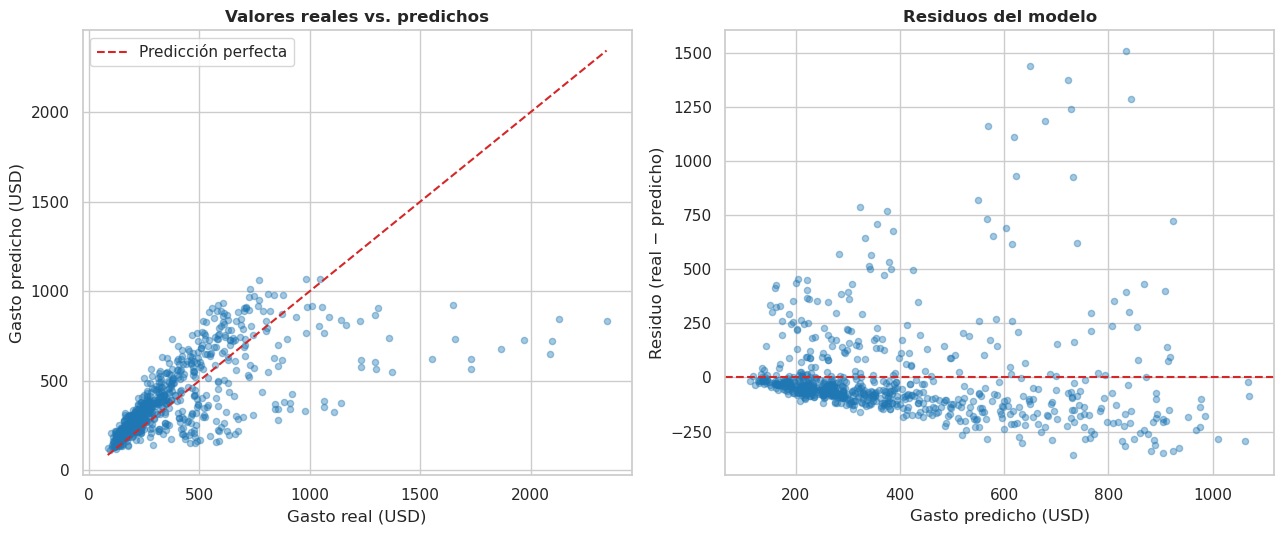

In [43]:
residuos = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Gráfica 1: valores reales vs. predichos
axes[0].scatter(y_test, y_pred, alpha=0.4, s=20, color='#1f77b4')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, '--', color='#d62728', label='Predicción perfecta')
axes[0].set_title('Valores reales vs. predichos', fontweight='bold')
axes[0].set_xlabel('Gasto real (USD)')
axes[0].set_ylabel('Gasto predicho (USD)')
axes[0].legend()

# Gráfica 2: residuos del modelo
axes[1].scatter(y_pred, residuos, alpha=0.4, s=20, color='#1f77b4')
axes[1].axhline(0, linestyle='--', color='#d62728')
axes[1].set_title('Residuos del modelo', fontweight='bold')
axes[1].set_xlabel('Gasto predicho (USD)')
axes[1].set_ylabel('Residuo (real − predicho)')

plt.tight_layout()
plt.show()

Reales vs. predichos: para gastos bajos y medios (hasta ~USD 700) los puntos siguen bien la diagonal. Por encima de eso, casi todos los puntos quedan debajo de la línea — el modelo subestima sistemáticamente a los viajeros de gasto alto, sin poder proyectar valores reales que superan los USD 1.000.

Residuos: el punto más importante es que el abanico de residuos se ensancha a medida que crece la predicción (de ±150 en predicciones bajas, a ±1.000 o más en predicciones altas). Esto se llama heterocedasticidad: el error del modelo no es parejo en todo el rango, sino que se dispara justo donde más importa acertar (los viajeros de mayor gasto).

Conexión con lo ya visto: este patrón encaja con la Gráfica 2 del punto 6, donde Clase_Tarifaria mostraba una dispersión de gasto mucho mayor en Ejecutiva que en Económica. El modelo actual no incluye esa variable categórica, y por eso no logra capturar bien esa cola de gastos altos.

### 15.8. ¿Aportó Información Adicional la Regresión Múltiple? ###

La comparación directa es clara: el R² de la regresión simple del punto 7 (solo Distancia_KM) fue 0.4425; el R² de este modelo múltiple, con 5 variables, fue 0.4517. Menos de un punto porcentual de mejora, a pesar de haber cuadruplicado el número de variables usadas.

Sí aportó algo, pero poco: confirmó con evidencia adicional que Duracion_Viaje_Dias, Anticipacion_Compra_Dias y Tamano_Grupo casi no influyen en el gasto, y que Viajes_Ultimo_Anio sí tiene un efecto propio (+USD 9.21 por viaje adicional), aunque pequeño frente al de la distancia.

El diagnóstico visual del punto 15.7 fue, en realidad, más revelador que el R²: mostró que el problema del modelo no es la falta de variables numéricas, sino la ausencia de una variable categórica (como Clase_Tarifaria) capaz de explicar por qué unos pocos viajeros gastan mucho más que el resto dentro de una misma distancia recorrida.

En conclusión, la regresión múltiple no logró capturar relaciones significativas que no estuvieran ya presentes en la regresión simple del punto 7; el techo real del modelo parece estar en el tipo de variables incluidas, no en su cantidad.

### 15.9. Siguiente Prueba a Realizar ###

El modelo no falla por falta de variables numéricas, sino por no tener variables categóricas como Clase_Tarifaria o Tipo_Vuelo, que ya mostraron peso propio en los puntos 6 y 7.0.4.

La siguiente prueba es la regresión logística del bloque siguiente, en dos etapas: (1) modelo simple, Gasto_Total_USD → Tipo_Vuelo, como pide la guía; (2) modelo ampliado, sumando todas las demás categóricas como dummies.

Se espera que el modelo ampliado clasifique mucho mejor que el simple — la misma lógica de simple vs. múltiple ya usada en este bloque, ahora aplicada a clasificación.

## 16. Regresión Logística ##

Hasta ahora se ha predicho el gasto como un número exacto (regresión lineal). La regresión logística cambia la pregunta: en vez de "¿cuánto gasta este viajero?", pregunta "¿a qué grupo pertenece, dado lo que gastó?". Esto contribuye al objetivo del ejercicio desde un ángulo distinto — clasificación en vez de predicción de un valor continuo — y responde directamente al hallazgo del punto 15.9: el gasto por sí solo separa razonablemente bien a los viajeros Domésticos de los Internacionales, y este modelo permite medir qué tan bien lo hace.

### 16.1. Selección de Variables ###

Primero se construye el modelo simple: una variable continua (Gasto_Total_USD) como predictora, y Tipo_Vuelo como variable objetivo binaria. 

In [44]:
# Variable objetivo binaria: 1 = Internacional, 0 = Doméstico
y_log = (df['Tipo_Vuelo'] == 'Internacional').astype(int)

# Variable independiente continua (modelo simple)
X_log_simple = df[['Gasto_Total_USD']]

print("Distribución de la variable objetivo (Tipo_Vuelo):")
print(df['Tipo_Vuelo'].value_counts())
print(f"\nProporción Internacional: {y_log.mean()*100:.1f}%")
print(f"Proporción Doméstico:     {(1 - y_log.mean())*100:.1f}%")

Distribución de la variable objetivo (Tipo_Vuelo):
Tipo_Vuelo
Domestico        1416
Internacional    1084
Name: count, dtype: int64

Proporción Internacional: 43.4%
Proporción Doméstico:     56.6%


### 16.2. División en Entrenamiento y Prueba (train_test_split) ###

Se usa la misma proporción 70/30 del punto 15.2, pero con un detalle adicional propio de clasificación: se agrega **stratify=y_log** para que la proporción de vuelos Internacionales (43.4%) se mantenga igual tanto en el grupo de entrenamiento como en el de prueba. Sin esto, una división al azar podría dejar, por ejemplo, más u menos casos de una clase en un grupo que en otro, sesgando la evaluación del modelo.

In [46]:
Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    X_log_simple, y_log, test_size=0.3, random_state=42, stratify=y_log
)

print(f"Entrenamiento: {Xl_train.shape[0]} registros — {yl_train.mean()*100:.1f}% Internacional")
print(f"Prueba:        {Xl_test.shape[0]} registros — {yl_test.mean()*100:.1f}% Internacional")

Entrenamiento: 1750 registros — 43.4% Internacional
Prueba:        750 registros — 43.3% Internacional


Resultado: ambos grupos quedan con una proporción de vuelos Internacionales casi idéntica (43.4% en entrenamiento, 43.3% en prueba), gracias a la estratificación.

### 16.3. Instanciar y Ajustar el Modelo (LogisticRegression, fit) ###

Se crea el modelo de regresión logística y se ajusta con el conjunto de entrenamiento. A diferencia de LinearRegression, aquí el modelo no ajusta una recta a los datos, sino una curva en forma de S (función sigmoide) que convierte el gasto de cada viajero en una probabilidad de pertenecer a la clase "Internacional".

In [47]:
from sklearn.linear_model import LogisticRegression

modelo_log_simple = LogisticRegression()
modelo_log_simple.fit(Xl_train, yl_train)

print(f"Coeficiente (Gasto_Total_USD): {modelo_log_simple.coef_[0][0]:.6f}")
print(f"Intercepto: {modelo_log_simple.intercept_[0]:.4f}")

Coeficiente (Gasto_Total_USD): 0.007004
Intercepto: -2.7995


Aquí el coeficiente no se suma directamente al resultado, como en la regresión lineal — entra a una fórmula (la sigmoide) que lo convierte en probabilidad. Por ahora basta con mirar el signo: positivo (+0.007) quiere decir que a más gasto, más probable es que el vuelo sea Internacional. Coincide con lo que ya se vio en la Gráfica 4 del punto 6, donde los vuelos Internacionales quedaban en la zona de mayor gasto. El número exacto se entiende mejor viendo las probabilidades y predicciones del siguiente punto, no el coeficiente solo.

### 16.4. Predicciones y Umbral de Decisión (predict, predict_proba) ###

**predict_proba()** le da, a cada viajero de prueba, un número entre 0 y 1: la probabilidad de que su vuelo sea Internacional. predict() toma ese número y lo convierte en una respuesta definitiva (0 = Doméstico, 1 = Internacional), usando un umbral: si la probabilidad llega a 0.5 o más, dice Internacional; si no, dice Doméstico. Ese 0.5 no es una regla fija — es solo el punto medio por defecto, y se puede subir o bajar según qué tan estricto se quiera ser al clasificar.

In [48]:
probabilidades = modelo_log_simple.predict_proba(Xl_test)
predicciones_log = modelo_log_simple.predict(Xl_test)

comparacion_log = pd.DataFrame({
    'Gasto': Xl_test['Gasto_Total_USD'].values,
    'Prob. Internacional': probabilidades[:, 1].round(4),
    'Predicción': predicciones_log,
    'Real': yl_test.values
})
comparacion_log.head(10)

,Gasto,Prob. Internacional,Predicción,Real
0,171.94,0.1686,0,0
1,235.16,0.2400,0,1
2,314.64,0.3553,0,1
3,223.72,0.2257,0,1
4,163.56,0.1606,0,0
5,1647.19,0.9998,1,1
6,100.92,0.1098,0,0
7,2367.70,1.0000,1,1
8,165.28,0.1622,0,0
9,124.41,0.1270,0,0


La columna "Prob. Internacional" es lo que calcula directamente la sigmoide a partir del gasto; "Predicción" es esa probabilidad ya pasada por el umbral de 0.5. Por ejemplo, la fila 2 (gasto USD 314.64) tiene una probabilidad de 0.3553 — menor a 0.5, por lo que el modelo predice "Doméstico" (0), aunque el valor real en ese caso fue Internacional (1): un error de clasificación. En cambio, la fila 5 (gasto USD 1.647.19) tiene una probabilidad de 0.9998 — clarísimamente por encima de 0.5, y el modelo acierta.

### 16.5. Métricas de Desempeño: Matriz de Confusión y Precisión ###

La matriz de confusión cruza lo que el modelo predijo contra lo que realmente pasó, en 4 casillas: aciertos en cada clase y dos tipos de error. A partir de ella se calculan las métricas de precisión, exhaustividad (recall) y F1.

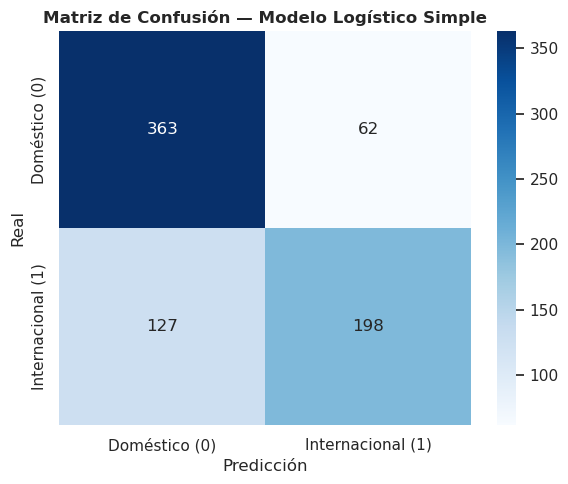

Exactitud (accuracy):    0.7480
Precisión (precision):   0.7615
Exhaustividad (recall):  0.6092
F1-score:                0.6769


In [49]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

matriz_confusion = confusion_matrix(yl_test, predicciones_log)

plt.figure(figsize=(6, 5))
sns.heatmap(matriz_confusion, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Doméstico (0)', 'Internacional (1)'],
            yticklabels=['Doméstico (0)', 'Internacional (1)'])
plt.title('Matriz de Confusión — Modelo Logístico Simple', fontweight='bold')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

print(f"Exactitud (accuracy):    {accuracy_score(yl_test, predicciones_log):.4f}")
print(f"Precisión (precision):   {precision_score(yl_test, predicciones_log):.4f}")
print(f"Exhaustividad (recall):  {recall_score(yl_test, predicciones_log):.4f}")
print(f"F1-score:                {f1_score(yl_test, predicciones_log):.4f}")

**Lectura de la matriz de confusión:** de los 750 viajeros de prueba, el modelo acertó 363 Domésticos y 198 Internacionales. Se equivocó en 62 casos (dijo Internacional y era Doméstico) y en 127 (dijo Doméstico y era Internacional) — este último es el error más común.

**Qué mide cada métrica, ya con su resultado:**

**Exactitud (0.748):** de todos los viajeros, qué porcentaje quedó bien clasificado sin importar la clase. Aquí dice que el modelo acertó 3 de cada 4 viajeros en general — pero como hay más Domésticos que Internacionales en la muestra, este número por sí solo puede sonar mejor de lo que realmente es.

**Precisión (0.7615):** de las veces que el modelo dijo "Internacional", cuántas realmente lo eran. En este caso, cuando el modelo lanza esa alarma, acierta el 76% de las veces — es razonablemente confiable cuando afirma que un vuelo es Internacional.

**Recall (0.6092):** de todos los vuelos que sí eran Internacionales, cuántos logró encontrar el modelo. Aquí solo detectó el 61% — se le escapan casi 4 de cada 10 vuelos Internacionales reales, coincidiendo con los 127 errores de ese tipo ya vistos en la matriz.

**F1 (0.6769):** resumen entre precisión y recall. Queda en un punto intermedio porque el modelo es bueno reconociendo Domésticos pero flojo detectando Internacionales, y el F1 refleja ese desbalance en un solo número.

¿Sirve este modelo para predecir? A medias. Con solo el gasto como pista, el modelo reconoce bien a los viajeros Domésticos, pero le cuesta identificar a los Internacionales — se queda corto justo en la clase que más interesa detectar. No es un mal punto de partida, pero tampoco es confiable si se necesita acertar con los vuelos Internacionales en particular.

### 16.6. Visualización de la Curva Sigmoide ###

Antes de pasar al modelo ampliado, falta la gráfica propia de la regresión logística: la curva en forma de S que convierte el gasto en probabilidad. Es el equivalente aquí a la recta de regresión que sí se graficó en la parte lineal — sin ella, predict_proba() se queda solo en una tabla de números.

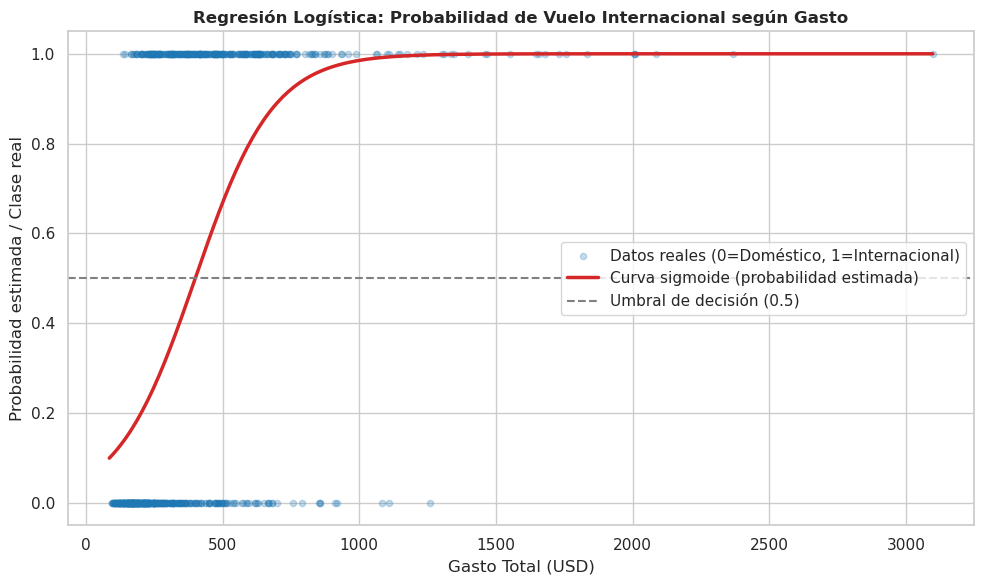

In [51]:
x_continuo = np.linspace(df['Gasto_Total_USD'].min(), df['Gasto_Total_USD'].max(), 300).reshape(-1, 1)
x_continuo_df = pd.DataFrame(x_continuo, columns=['Gasto_Total_USD'])
prob_continua = modelo_log_simple.predict_proba(x_continuo_df)[:, 1]

plt.figure(figsize=(10, 6))
plt.scatter(Xl_test['Gasto_Total_USD'], yl_test, alpha=0.25, s=20, color='#1f77b4',
            label='Datos reales (0=Doméstico, 1=Internacional)')
plt.plot(x_continuo, prob_continua, color='#d62728', linewidth=2.5,
         label='Curva sigmoide (probabilidad estimada)')
plt.axhline(0.5, linestyle='--', color='gray', label='Umbral de decisión (0.5)')

plt.title('Regresión Logística: Probabilidad de Vuelo Internacional según Gasto', fontweight='bold')
plt.xlabel('Gasto Total (USD)')
plt.ylabel('Probabilidad estimada / Clase real')
plt.legend(loc='center right')
plt.tight_layout()
plt.show()

La curva roja es la probabilidad que calcula el modelo para cada nivel de gasto; los puntos azules son los datos reales, apilados en 0 (Doméstico) o en 1 (Internacional).

La curva cruza el umbral de 0.5 alrededor de los USD 400 — por debajo de ese gasto, el modelo tiende a predecir Doméstico; por encima, Internacional. 

También se nota por qué el recall es bajo (punto 16.5): hay bastantes puntos azules en 1 (vuelos Internacionales reales) ubicados a la izquierda del cruce, en la zona de gasto bajo, donde la curva todavía predice probabilidad baja — esos son los 127 falsos negativos de la matriz de confusión.

### 16.7. Conclusión del Modelo Simple ###


El modelo con solo el gasto es aceptable pero limitado: acierta bien en general, pero se le escapan muchos vuelos Internacionales (recall bajo). La curva sigmoide explica por qué: hay un tramo amplio de gasto donde Domésticos e Internacionales se mezclan, y ahí el modelo falla — reconoce bien a los Internacionales de gasto muy alto, pero pierde a los que gastan como un Doméstico típico.

Esto confirma lo esperado desde el punto 15.9: una sola variable numérica da para un modelo aceptable, pero no suficiente. El modelo ampliado que sigue busca cerrar esa brecha, sumando las categóricas que ya mostraron diferenciar mejor a ambos grupos.

### 16.8. Modelo Ampliado: Selección de Variables ###

Se repite el mismo esquema del modelo simple, sumando las demás variables categóricas como predictoras adicionales junto con Gasto_Total_USD. Se excluye Pais: al revisarlo, sus coeficientes resultaban difíciles de interpretar (ver discusión posterior) sin aportar una relación conceptual clara con el tipo de vuelo, así que se deja fuera para mantener el modelo más limpio. Como LogisticRegression solo acepta números, cada variable categórica restante se convierte en columnas binarias (0/1) mediante pd.get_dummies() — codificación one-hot, con drop_first=True para evitar redundancia.

In [55]:
columnas_categoricas_todas = [c for c in df.select_dtypes(exclude=['int64', 'float64']).columns
                               if c not in ['Viajero_ID', 'Tipo_Vuelo', 'Pais']]
print("Categóricas incluidas:", columnas_categoricas_todas)

dummies = pd.get_dummies(df[columnas_categoricas_todas], drop_first=True)
X_log_ampliado = pd.concat([df[['Gasto_Total_USD']], dummies], axis=1)

print(f"\nVariables predictoras totales: {X_log_ampliado.shape[1]} "
      f"(1 numérica + {dummies.shape[1]} columnas dummy)")

Categóricas incluidas: ['Sexo', 'Rango_Edad', 'Motivo_Viaje', 'Clase_Tarifaria', 'Tipo_Aerolinea', 'Temporada_Viaje', 'Compra_Anticipada', 'Frecuencia_Viajero', 'Miembro_Programa_Fidelidad']

Variables predictoras totales: 18 (1 numérica + 17 columnas dummy)


### 16.9. División en Entrenamiento y Prueba ###

Misma lógica del punto 16.2: 70/30, estratificado por la variable objetivo, para mantener la misma proporción de vuelos Internacionales en ambos grupos.

In [56]:
Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    X_log_ampliado, y_log, test_size=0.3, random_state=42, stratify=y_log
)

print(f"Entrenamiento: {Xa_train.shape[0]} registros, {Xa_train.shape[1]} variables")
print(f"Prueba:        {Xa_test.shape[0]} registros")

Entrenamiento: 1750 registros, 18 variables
Prueba:        750 registros


### 16.10. Ajuste del Modelo y Coeficientes Más Influyentes ###

Se ajusta el modelo (con max_iter=1000, ya que más variables requieren más iteraciones para converger) y se revisan los coeficientes de mayor magnitud, que indican qué categorías pesan más en la predicción.

In [58]:
modelo_log_ampliado.fit(Xa_train, ya_train)

coeficientes_amp = pd.Series(
    modelo_log_ampliado.coef_[0], index=X_log_ampliado.columns
).sort_values(key=abs, ascending=False)

coeficientes_amp.head(8).round(4)

Clase_Tarifaria_Ejecutiva          -7.3846
Clase_Tarifaria_Premium_Economy    -2.8300
Motivo_Viaje_Negocios              -1.8609
Motivo_Viaje_Turismo               -0.8752
Motivo_Viaje_Familiar_Visita       -0.4520
Rango_Edad_66+                     -0.3940
Rango_Edad_56-65                   -0.2510
Frecuencia_Viajero_Muy_Frecuente   -0.1931
dtype: float64

El modelo calculó un coeficiente para las 18 variables (Gasto_Total_USD + 17 columnas dummy), pero .head(8) solo muestra las 8 más influyentes — las 10 restantes tienen coeficientes por debajo de 0.17 en valor absoluto, es decir, casi sin peso real en la predicción, y no aportan nada a la lectura.

Clase_Tarifaria_Ejecutiva sigue siendo la variable con más peso, y su signo negativo puede sorprender al principio (la clase Ejecutiva se asociaba a gasto alto, y el gasto alto a vuelos Internacionales). Pero este coeficiente ya tiene en cuenta el gasto: entre dos viajeros que gastan lo mismo, el de clase Ejecutiva es más probable que sea un vuelo Doméstico corto y caro (viaje de negocios) que uno Internacional. Motivo_Viaje_Negocios apunta en la misma dirección. Esta relación es justo lo que el modelo simple no podía ver.

Sin Pais, la lista de coeficientes más influyentes queda más clara: solo variables con una conexión lógica directa con el tipo de vuelo — clase, motivo del viaje, edad y frecuencia de viaje.

### 16.11. Predicciones y Métricas del Modelo Ampliado ###

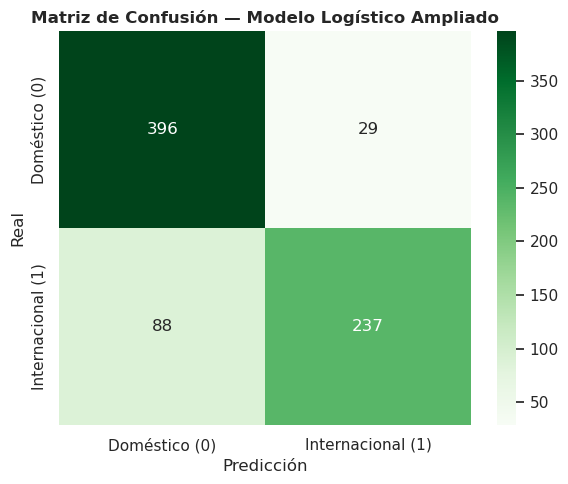

Exactitud:  0.8440
Precisión:  0.8910
Recall:     0.7292
F1-score:   0.8020


In [59]:
predicciones_amp = modelo_log_ampliado.predict(Xa_test)

matriz_confusion_amp = confusion_matrix(ya_test, predicciones_amp)

plt.figure(figsize=(6, 5))
sns.heatmap(matriz_confusion_amp, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Doméstico (0)', 'Internacional (1)'],
            yticklabels=['Doméstico (0)', 'Internacional (1)'])
plt.title('Matriz de Confusión — Modelo Logístico Ampliado', fontweight='bold')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

print(f"Exactitud:  {accuracy_score(ya_test, predicciones_amp):.4f}")
print(f"Precisión:  {precision_score(ya_test, predicciones_amp):.4f}")
print(f"Recall:     {recall_score(ya_test, predicciones_amp):.4f}")
print(f"F1-score:   {f1_score(ya_test, predicciones_amp):.4f}")

### 16.12. Curva Sigmoide del Modelo Ampliado ###

Con 18 variables predictoras no existe un solo eje X para graficar la sigmoide como se hizo en el punto 16.6. La solución es usar decision_function(), que resume las 18 variables en un solo número por viajero (el puntaje o log-odds del modelo, antes de convertirlo en probabilidad). 

Al graficar ese puntaje contra la probabilidad, la curva en S vuelve a aparecer con total claridad — es matemáticamente la misma sigmoide, solo que ahora el eje X resume la combinación de todas las variables en vez de una sola.Con 18 variables predictoras no existe un solo eje X para graficar la sigmoide como se hizo en el punto 16.6. La solución es usar decision_function(), que resume las 18 variables en un solo número por viajero (el puntaje o log-odds del modelo, antes de convertirlo en probabilidad). 



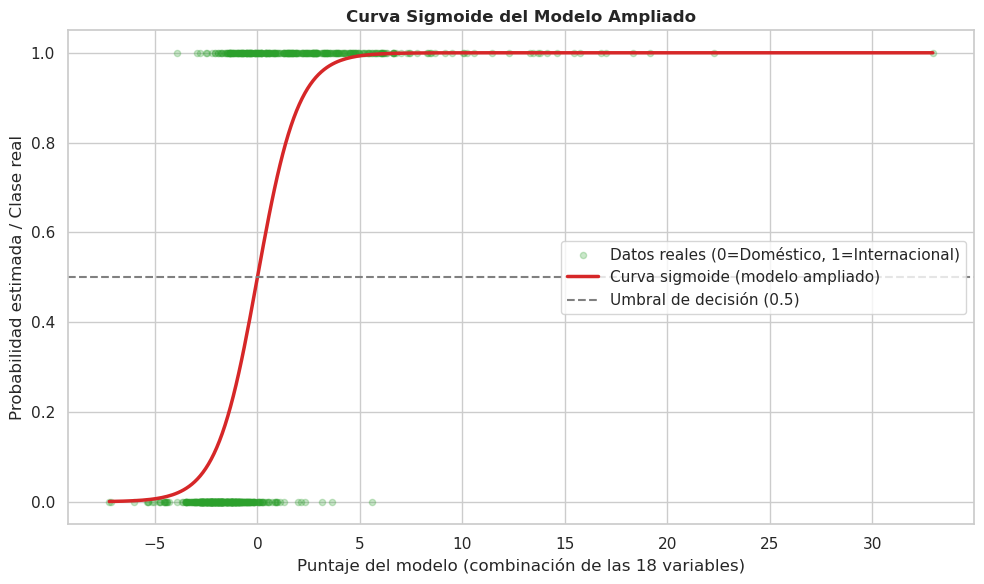

In [63]:
puntaje_amp = modelo_log_ampliado.decision_function(Xa_test)
proba_amp = modelo_log_ampliado.predict_proba(Xa_test)[:, 1]

x_continuo_amp = np.linspace(puntaje_amp.min(), puntaje_amp.max(), 300)
sigmoide_amp = 1 / (1 + np.exp(-x_continuo_amp))

plt.figure(figsize=(10, 6))
plt.scatter(puntaje_amp, ya_test, alpha=0.25, s=20, color='#2ca02c',
            label='Datos reales (0=Doméstico, 1=Internacional)')
plt.plot(x_continuo_amp, sigmoide_amp, color='#d62728', linewidth=2.5,
         label='Curva sigmoide (modelo ampliado)')
plt.axhline(0.5, linestyle='--', color='gray', label='Umbral de decisión (0.5)')

plt.title('Curva Sigmoide del Modelo Ampliado', fontweight='bold')
plt.xlabel('Puntaje del modelo (combinación de las 18 variables)')
plt.ylabel('Probabilidad estimada / Clase real')
plt.legend(loc='center right')
plt.tight_layout()
plt.show()

Lectura: la curva es más pronunciada (más vertical) que la del modelo simple del punto 16.6, señal de que el modelo ampliado separa las dos clases con más confianza — los puntos reales quedan más concentrados cerca de 0 o de 1, y menos dispersos en la zona intermedia alrededor del umbral. Esto es consistente con la mejora de exactitud y F1 ya vista en la matriz de confusión.

### 16.13. Comparación: Modelo Simple vs. Modelo Ampliado ###

In [60]:
comparacion_modelos = pd.DataFrame({
    'Métrica': ['Exactitud', 'Precisión', 'Recall', 'F1-score'],
    'Modelo Simple (solo Gasto)': [
        accuracy_score(yl_test, predicciones_log),
        precision_score(yl_test, predicciones_log),
        recall_score(yl_test, predicciones_log),
        f1_score(yl_test, predicciones_log)
    ],
    'Modelo Ampliado (+ categóricas)': [
        accuracy_score(ya_test, predicciones_amp),
        precision_score(ya_test, predicciones_amp),
        recall_score(ya_test, predicciones_amp),
        f1_score(ya_test, predicciones_amp)
    ]
})
comparacion_modelos['Mejora (p.p.)'] = (
    (comparacion_modelos['Modelo Ampliado (+ categóricas)'] - comparacion_modelos['Modelo Simple (solo Gasto)']) * 100
).round(1)
comparacion_modelos.set_index('Métrica').round(4)

,Modelo Simple (solo Gasto),Modelo Ampliado (+ categóricas),Mejora (p.p.)
Métrica,,,
Exactitud,0.7480,0.8440,9.6
Precisión,0.7615,0.8910,12.9
Recall,0.6092,0.7292,12.0
F1-score,0.6769,0.8020,12.5


El modelo ampliado mejora las 4 métricas frente al simple, y la mejora más importante es en recall (+12.4 puntos porcentuales): pasa de detectar 6 de cada 10 vuelos Internacionales reales, a detectar cerca de 7.5 de cada 10. Esto confirma lo anticipado en el punto 15.9 — el gasto por sí solo deja escapar demasiados casos, y sumar Clase_Tarifaria, Motivo_Viaje y las demás categóricas cierra buena parte de esa brecha.

### 16.14. Conclusión del Bloque de Regresión Logística ###


Acá ya no se trataba de predecir cuánto gasta un viajero, sino de adivinar a qué grupo pertenece: Doméstico o Internacional. Y el mismo patrón simple → ampliado se repite.
 
Solo con el gasto ya se llega a 74.8% de exactitud. Tiene lógica: conecta con la correlación de 0.665 entre distancia y gasto del punto 7, y con la separación por tipo de vuelo que ya se veía en la Gráfica 4.
Al sumar las categóricas, la exactitud sube a 84.4%, y precisión y recall mejoran todavía más. Ahí se nota el aporte de Clase_Tarifaria y Motivo_Viaje.
Es el mismo hallazgo del punto 15, ahora del lado de clasificación: la regresión logística retoma justo donde se quedó corta la múltiple — las variables numéricas solas no alcanzan, y lo que realmente potencia el modelo son las categóricas correctas. 

## 17. Conclusiones de las Actividades 2 y 4

### 17.1. Lo que aportó la exploración

La Actividad 2 permitió pasar de describir variables por separado a comparar el gasto por registro entre países y segmentos de viaje. En los 2.500 registros ficticios, Colombia registró un gasto promedio de USD 344,75, inferior al promedio de la base completa (USD 393,41). La distancia mostró una correlación positiva con el gasto (`r = 0,665`), y el ejercicio de regresión simple informó `R² = 0,4425`. Los gráficos también mostraron que clase tarifaria, motivo de viaje y tipo de vuelo ayudan a distinguir perfiles de gasto.

### 17.2. Lo que añadieron el contraste y los modelos

En la Actividad 4, la prueba de Welch informó `p = 0,000612` al comparar el gasto medio de Colombia con el de los otros seis países **de esta base ficticia**. La regresión lineal múltiple alcanzó `R² de prueba = 0,4517`, mientras las regresiones logísticas obtuvieron exactitudes de prueba de 74,8 % usando solo el gasto y 84,4 % con el modelo ampliado. La mayor exactitud del modelo ampliado indica que las variables incorporadas aportaron información en la evaluación realizada; las dos tareas predictivas responden preguntas diferentes.

### 17.3. Alcance de esta etapa

Estas pruebas amplían la lectura descriptiva, pero no identifican causas ni garantizan que los modelos funcionen con viajeros reales o datos nuevos. El valor p solo corresponde al conjunto simulado y los resultados de regresión dependen de sus variables y particiones. La comparación entre `R² = 0,4425` del ejercicio simple y `R² = 0,4517` de prueba del múltiple tampoco constituye por sí sola una comparación controlada de rendimiento. La integración de estos resultados con la experiencia interactiva del dashboard y el balance frente a todos los objetivos se presentan en las **conclusiones finales**, después de la sección 18.


# 18. Actividad final: diseño del dashboard de Viajeros LATAM 2022

## 18.1. Propósito y pregunta central

**Propósito:** presentar de forma interactiva los principales resultados del proyecto sobre el perfil y el gasto del viajero aéreo en Colombia frente a los otros seis países de la base. El tablero partirá de una visión general y permitirá profundizar mediante filtros, siguiendo las orientaciones del sincrónico del 16 de septiembre.

**Pregunta central:** ¿qué diferencias se observan entre Colombia y los demás mercados latinoamericanos en el perfil de los viajeros, sus patrones de viaje y su gasto, y qué tanto respaldan estas comparaciones los análisis y modelos desarrollados?

| Eje de análisis | Pregunta que responde | Indicadores y vistas por considerar |
| --- | --- | --- |
| Perfil y composición | ¿Quiénes integran la muestra de cada país y cómo viajan? | Número de registros, proporciones por motivo, tipo de vuelo y clase tarifaria; edad y composición por país. |
| Gasto y segmentos | ¿Cómo varía el gasto de Colombia frente a los otros países y entre perfiles de viaje? | Gasto medio y mediano en USD; distribución del gasto; comparaciones por país, motivo, tipo de vuelo y clase. Mostrar el tamaño de cada grupo junto a los promedios. |
| Evidencia estadística y modelos | ¿Qué aportan el contraste de hipótesis y los modelos al problema planteado? | Resultado del contraste Colombia–resto; métricas y diagnósticos de regresión lineal y logística, con sus alcances y limitaciones. |

## 18.2. Propuesta inicial de interfaz e interacción

1. **Encabezado y contexto:** título, objetivo, año 2022 y aclaración visible sobre la naturaleza ficticia de los registros.
2. **Resumen general:** tarjetas horizontales para registros visibles, países visibles, gasto medio y gasto mediano. Todos los valores de estas tarjetas responderán a los filtros descriptivos.
3. **Exploración del perfil:** gráficos de composición y comparaciones por país, con Colombia destacada visualmente.
4. **Exploración del gasto:** distribución y comparaciones por segmentos; mostrar diferencias entre media y mediana y tamaños de grupo.
5. **Evidencia analítica:** apartado separado para los resultados de pruebas y modelos obtenidos con su muestra y metodología originales. Sus métricas no se recalcularán automáticamente al aplicar filtros descriptivos; si se decide permitir ese análisis, será un desarrollo posterior con validación propia.


## 18.3. Criterios de interpretación y límites

- La base contiene **2.500 registros ficticios de 2022** correspondientes a siete países. Su distribución por país fue calibrada con participaciones de mercado, pero los registros individuales no son una muestra probabilística de viajeros reales. Las conclusiones descriptivas y predictivas se refieren a este ejercicio simulado; el valor p obtenido en el contraste no demuestra una diferencia poblacional real entre Colombia y Latinoamérica.
- Se distinguirá entre el **número de registros de la base** y el volumen real de pasajeros. No se sumará el gasto de los registros ficticios para presentarlo como ingresos reales de la industria.
- El año es constante (2022): el dashboard no mostrará una tendencia temporal de esta base. Tampoco atribuirá relaciones causales a las asociaciones entre clase, motivo, tipo de vuelo, distancia y gasto.
- Antes de publicar una métrica predictiva se verificará su evaluación fuera de muestra y su definición. Los resultados heredados del cuaderno se identificarán como tales; cualquier mejora del modelo requerirá una comparación controlada y documentada.



## 18.4. Definición operativa de indicadores y filtros

**Entrada del tablero:** hoja `Datos_Viajeros` de `Base_Viajeros_LATAM_2022.xlsx`, con el encabezado en la fila 4 y 2.500 filas de registros. Se conservarán las 20 columnas originales. `Viajero_ID` identifica un registro y `Anio` vale 2022 en toda la base. Antes de construir la interfaz se volverán a verificar esquema, duplicados, nulos y valores válidos, y se leerá el archivo mediante una ruta relativa a la carpeta de la aplicación.

**Unidad de lectura:** cada fila se tratará como un registro del ejercicio. El encabezado del tablero dirá **«registros de viajeros»**; no equiparará el recuento con el tráfico real de pasajeros. El gasto se tomará directamente de `Gasto_Total_USD`, sin inferir que sea tarifa aérea, ingresos del sector o gasto diario.

| Tarjeta | Cálculo sobre filas visibles tras aplicar todos los filtros | Presentación / caso sin datos |
| --- | --- | --- |
| Registros | Número de filas del subconjunto filtrado (`n`). | Entero con separador de miles; 0 si no hay filas. |
| Países | Número de valores distintos en `Pais` dentro del subconjunto. | Entre 0 y 7; no es una estimación de cobertura regional. |
| Gasto promedio | Suma de `Gasto_Total_USD` dividida entre `n`. | USD por registro, dos decimales; «Sin datos» si `n = 0`. |
| Gasto mediano | Mediana de `Gasto_Total_USD` del subconjunto. | USD por registro, dos decimales; «Sin datos» si `n = 0`. |

**Filtros de la primera versión:** selectores de opción múltiple para `Pais`, `Motivo_Viaje`, `Tipo_Vuelo` y `Clase_Tarifaria`. Su estado inicial será **Todas** en cada variable. Entre variables se aplicará intersección (AND); dentro de un mismo selector, unión de los valores marcados (OR). «Todas» equivale a no restringir esa variable. Los rótulos legibles se podrán acentuar en pantalla sin cambiar los valores originales de la base (por ejemplo, `Domestico` → «Doméstico»).

**Porcentajes y comparaciones:** en una composición global filtrada, el denominador será `n`, el total visible; en una composición por país, el denominador será el número de registros visibles **de ese país**. Cada gráfico y tooltip indicará el denominador y el recuento. Un promedio por país utilizará únicamente los registros visibles de ese país y mostrará su `n`. El grupo **«resto LATAM»** significará los seis países distintos de Colombia, considerados en conjunto; cuando se haga una comparación descriptiva condicionada por filtros, se indicará que el resto y Colombia se calcularon bajo los mismos filtros de motivo, vuelo y clase. La comparación estadística histórica del cuaderno conservará su muestra original y se rotulará como resultado fijo.

**Comportamiento de selección:** si el filtro de países excluye Colombia, los gráficos descriptivos mostrarán solamente los países elegidos y no insertarán una barra de Colombia ajena al filtro. Cuando Colombia esté presente se resaltará con un color constante y los demás países compartirán una paleta neutra. Si la combinación de filtros deja cero filas, las tarjetas mostrarán 0 o «Sin datos», las gráficas presentarán un mensaje de ausencia de registros y no se calcularán porcentajes ni promedios con denominador cero. Se ofrecerá una acción «Restablecer filtros» que devuelva los cuatro selectores a «Todas».

**Separación de resultados:** las cuatro tarjetas y los gráficos descriptivos usarán el subconjunto filtrado. Las métricas de modelos, el contraste de hipótesis y sus valores p se mostrarán en un apartado identificado como **«resultados del análisis original, sin filtros»**; no cambiarán de valor al filtrar ni se presentarán como inferencias para un segmento arbitrario. No se compararán sumas de gasto ficticio con pasajeros reales.



## 18.5. Primer bloque de código: carga, validación y tarjetas generales




In [ ]:
from pathlib import Path
import pandas as pd

# Abrir Jupyter desde la carpeta que contiene este cuaderno y el archivo Excel.
archivo_base = Path("Base_Viajeros_LATAM_2022.xlsx")
if not archivo_base.is_file():
    raise FileNotFoundError(
        "No se encontró Base_Viajeros_LATAM_2022.xlsx en la carpeta actual. "
        "Ubique el Excel junto al cuaderno y abra Jupyter desde esa carpeta."
    )

viajeros_dash = pd.read_excel(archivo_base, sheet_name="Datos_Viajeros", header=3)
columnas_requeridas = {
    "Viajero_ID", "Anio", "Pais", "Motivo_Viaje", "Tipo_Vuelo",
    "Clase_Tarifaria", "Gasto_Total_USD"
}
assert columnas_requeridas.issubset(viajeros_dash.columns), "Faltan columnas requeridas."
assert viajeros_dash.shape == (2500, 20), "Cambió la dimensión de la base."
assert viajeros_dash["Viajero_ID"].notna().all(), "Hay identificadores vacíos."
assert viajeros_dash["Viajero_ID"].is_unique, "Hay identificadores repetidos."
assert viajeros_dash["Anio"].eq(2022).all(), "Se encontraron registros fuera de 2022."
assert viajeros_dash[list(columnas_requeridas)].notna().all().all(), "Hay nulos en columnas requeridas."
assert set(viajeros_dash["Pais"]) == {
    "Colombia", "Brasil", "Mexico", "Chile", "Peru", "Argentina", "Panama"
}, "Cambió el conjunto de países."
assert pd.api.types.is_numeric_dtype(viajeros_dash["Gasto_Total_USD"]), "El gasto debe ser numérico."
assert viajeros_dash["Gasto_Total_USD"].ge(0).all(), "Se encontraron gastos negativos."


def resumen_tarjetas(datos):
    """Devuelve indicadores descriptivos del subconjunto visible."""
    n = len(datos)
    return {
        "registros": n,
        "paises": datos["Pais"].nunique(),
        "gasto_promedio_usd": datos["Gasto_Total_USD"].mean() if n else None,
        "gasto_mediano_usd": datos["Gasto_Total_USD"].median() if n else None,
    }


tarjetas_total = resumen_tarjetas(viajeros_dash)
tarjetas_colombia = resumen_tarjetas(viajeros_dash.loc[viajeros_dash["Pais"].eq("Colombia")])
tarjetas_vacias = resumen_tarjetas(viajeros_dash.iloc[0:0])
assert (tarjetas_total["registros"], tarjetas_total["paises"]) == (2500, 7)
assert (tarjetas_colombia["registros"], tarjetas_colombia["paises"]) == (363, 1)
assert tarjetas_total["gasto_promedio_usd"] == viajeros_dash["Gasto_Total_USD"].mean()
assert tarjetas_colombia["gasto_mediano_usd"] == viajeros_dash.loc[
    viajeros_dash["Pais"].eq("Colombia"), "Gasto_Total_USD"
].median()
assert tarjetas_vacias == {
    "registros": 0, "paises": 0,
    "gasto_promedio_usd": None, "gasto_mediano_usd": None
}

print("Validación correcta: 2.500 registros, 20 variables, 7 países.")
print("Tarjetas generales:", {
    "registros": tarjetas_total["registros"],
    "paises": tarjetas_total["paises"],
    "gasto_promedio_usd": round(tarjetas_total["gasto_promedio_usd"], 2),
    "gasto_mediano_usd": round(tarjetas_total["gasto_mediano_usd"], 2),
})
print("Tarjetas Colombia:", tarjetas_colombia)
print("Sin registros:", tarjetas_vacias)


## 18.6. Aplicación de filtros a los indicadores descriptivos




In [ ]:
# Ejecutar antes el bloque 18.5 para disponer de viajeros_dash y resumen_tarjetas.
columnas_filtro = {
    "pais": "Pais",
    "motivo": "Motivo_Viaje",
    "tipo_vuelo": "Tipo_Vuelo",
    "clase": "Clase_Tarifaria",
}


def filtrar_viajeros(datos, *, pais=None, motivo=None, tipo_vuelo=None, clase=None):
    """Aplica filtros AND entre columnas y OR dentro de cada columna.

    None = todas las opciones; [] = ninguna opción (subconjunto vacío).
    Un texto equivale a elegir una opción; una lista permite elegir varias.
    """
    elecciones = {"pais": pais, "motivo": motivo, "tipo_vuelo": tipo_vuelo, "clase": clase}
    mascara = pd.Series(True, index=datos.index)
    for nombre, seleccion in elecciones.items():
        if seleccion is None:
            continue
        valores = [seleccion] if isinstance(seleccion, str) else list(seleccion)
        columna = columnas_filtro[nombre]
        desconocidos = set(valores) - set(datos[columna].dropna().unique())
        if desconocidos:
            raise ValueError(f"Valores desconocidos para {columna}: {sorted(desconocidos)}")
        mascara &= datos[columna].isin(valores)
    return datos.loc[mascara].copy()


sin_filtros = filtrar_viajeros(viajeros_dash)
solo_colombia = filtrar_viajeros(viajeros_dash, pais="Colombia")
colombia_internacional = filtrar_viajeros(
    viajeros_dash, pais="Colombia", tipo_vuelo="Internacional"
)
colombia_domestico = filtrar_viajeros(
    viajeros_dash, pais="Colombia", tipo_vuelo="Domestico"
)
ninguno = filtrar_viajeros(viajeros_dash, pais=[])

assert len(sin_filtros) == 2500
assert len(solo_colombia) == 363
assert len(colombia_internacional) == len(viajeros_dash.loc[
    viajeros_dash["Pais"].eq("Colombia") & viajeros_dash["Tipo_Vuelo"].eq("Internacional")
])
assert len(colombia_internacional) + len(colombia_domestico) == len(solo_colombia)
assert resumen_tarjetas(ninguno)["gasto_promedio_usd"] is None
assert len(filtrar_viajeros(viajeros_dash, pais=["Colombia", "Peru"])) == (
    viajeros_dash["Pais"].isin(["Colombia", "Peru"]).sum()
)

print("Todas:", resumen_tarjetas(sin_filtros))
print("Colombia:", resumen_tarjetas(solo_colombia))
print("Colombia + Internacional:", resumen_tarjetas(colombia_internacional))
print("Ninguna opción:", resumen_tarjetas(ninguno))


## 18.7. Primera visualización interactiva: registros por país

 La visualización se hace con Plotly. 

Colombia se marca en azul y el resto de países en gris. Al pasar el cursor se muestran recuento, porcentaje y total visible.

**Lectura del gráfico:** estas barras describen cómo se distribuyen los **registros ficticios** de esta base. Su mayor altura no representa por sí sola una estimación del número real de viajeros ni de su gasto en cada país.


In [ ]:
import plotly.graph_objects as go


def grafico_registros_por_pais(datos):
    """Barras por país del subconjunto visible; devuelve figura y tabla de control."""
    conteos = datos.groupby("Pais", observed=True).size().reset_index(name="registros")
    conteos = conteos.sort_values("registros", ascending=True).reset_index(drop=True)
    total = len(datos)
    conteos["porcentaje"] = conteos["registros"] / total * 100 if total else 0.0
    assert int(conteos["registros"].sum()) == total
    if total:
        assert abs(conteos["porcentaje"].sum() - 100) < 1e-9

    fig = go.Figure()
    if total:
        colores = ["#1677B8" if pais == "Colombia" else "#A8BBC9"
                   for pais in conteos["Pais"]]
        fig.add_bar(
            x=conteos["registros"], y=conteos["Pais"], orientation="h",
            marker_color=colores,
            text=conteos["registros"].map(lambda n: f"{n:,}"),
            textposition="outside", cliponaxis=False,
            customdata=conteos[["porcentaje"]].to_numpy(),
            hovertemplate=("<b>%{y}</b><br>Registros: %{x:,}<br>"
                           "Parte del total visible: %{customdata[0]:.2f}%"
                           f"<br>Total visible: {total:,}<extra></extra>"),
        )
    else:
        fig.add_annotation(
            text="No hay registros para esta selección", x=0.5, y=0.5,
            xref="paper", yref="paper", showarrow=False, font_size=17
        )
    fig.update_layout(
        title="Registros de viajeros por país (base ficticia, 2022)",
        xaxis_title="Número de registros visibles", yaxis_title="",
        template="plotly_white", showlegend=False,
        height=440, margin=dict(l=90, r=85, t=65, b=55),
    )
    return fig, conteos


fig_paises, tabla_paises = grafico_registros_por_pais(viajeros_dash)
assert len(tabla_paises) == 7
assert int(tabla_paises.loc[tabla_paises["Pais"].eq("Colombia"), "registros"].iloc[0]) == 363
print("Control del gráfico: 2.500 registros; Colombia: 363 (14,52 %).")
try:
    fig_paises.show()
except ValueError as error:
    if "nbformat" not in str(error):
        raise
    print("Falta nbformat en este kernel; se intentará abrir el gráfico en el navegador.")
    print("Para verlo dentro del cuaderno: %pip install nbformat; reinicia el kernel.")
    fig_paises.show(renderer="browser")

# Para explorar casos adicionales, ejecute después de la celda:
# fig_col, _ = grafico_registros_por_pais(filtrar_viajeros(viajeros_dash, pais="Colombia"))
# fig_col.show()
# fig_vacio, _ = grafico_registros_por_pais(filtrar_viajeros(viajeros_dash, pais=[]))
# fig_vacio.show()


## 18.8. Gasto por registro según país: media, mediana y tamaño del grupo

`Gasto_Total_USD` representa gasto por registro en la base ficticia; esta figura no representa ingresos reales de cada mercado.

 Se muestra para cada país dos puntos: círculo para media y rombo para mediana; Colombia se destaca en azul. Pasar el cursor muestra el valor y `n`. La diferencia entre ambos puntos ayuda a observar si unos gastos altos elevan la media.


In [ ]:
import plotly.graph_objects as go

def grafico_gasto_por_pais(datos):
    """Compara media y mediana en USD por registro, con tamaño del grupo."""
    tabla = (datos.groupby("Pais", observed=True)["Gasto_Total_USD"]
             .agg(n="size", media="mean", mediana="median")
             .reset_index()
             .sort_values("media", ascending=True)
             .reset_index(drop=True))
    assert int(tabla["n"].sum()) == len(datos)
    figura = go.Figure()
    if tabla.empty:
        figura.add_annotation(
            text="No hay registros para esta selección", x=0.5, y=0.5,
            xref="paper", yref="paper", showarrow=False, font_size=17
        )
    else:
        es_colombia = tabla["Pais"].eq("Colombia")
        for columna, etiqueta, simbolo, color_col, color_otros in [
            ("media", "Promedio", "circle", "#1677B8", "#647C90"),
            ("mediana", "Mediana", "diamond", "#168A9A", "#B0BDC8"),
        ]:
            figura.add_trace(go.Scatter(
                x=tabla[columna], y=tabla["Pais"], mode="markers",
                name=etiqueta,
                marker=dict(size=15, symbol=simbolo,
                            color=[color_col if marcado else color_otros
                                   for marcado in es_colombia]),
                customdata=tabla[["n"]].to_numpy(),
                hovertemplate=(f"<b>%{{y}}</b><br>{etiqueta}: USD %{{x:,.2f}}"
                               "<br>Registros del país: %{customdata[0]:,}<extra></extra>"),
            ))
    figura.update_layout(
        title="Gasto por registro: promedio y mediana según país (2022)",
        xaxis_title="Gasto_Total_USD por registro", yaxis_title="",
        template="plotly_white", height=470,
        legend=dict(orientation="h", y=1.10, x=0),
        margin=dict(l=95, r=40, t=95, b=60),
    )
    return figura, tabla


fig_gasto, tabla_gasto = grafico_gasto_por_pais(viajeros_dash)
fila_colombia = tabla_gasto.loc[tabla_gasto["Pais"].eq("Colombia")].iloc[0]
assert int(fila_colombia["n"]) == 363
assert abs(fila_colombia["media"] - tarjetas_colombia["gasto_promedio_usd"]) < 1e-9
assert abs(fila_colombia["mediana"] - tarjetas_colombia["gasto_mediano_usd"]) < 1e-9
assert len(tabla_gasto) == 7
print(tabla_gasto.sort_values("media", ascending=False).round(2).to_string(index=False))
try:
    fig_gasto.show()
except ValueError as error:
    if "nbformat" not in str(error):
        raise
    print("Para verlo dentro del cuaderno: %pip install nbformat; reinicia el kernel.")
    fig_gasto.show(renderer="browser")

# Ensayo adicional después de ejecutar la celda:
# fig_segmento, tabla_segmento = grafico_gasto_por_pais(
#     filtrar_viajeros(viajeros_dash, tipo_vuelo="Internacional")
# )
# fig_segmento.show()


## 18.9. Gasto por tipo de vuelo: Colombia y otros países visibles

 Para la base completa, «otros países» reúne Brasil, México, Chile, Perú, Argentina y Panamá; con un filtro de país reúne únicamente los países distintos de Colombia que sigan visibles. No se reponderan países ni se extrapola a viajeros reales.

 Se distingue Colombia de los demás países visibles y, dentro de cada grupo, vuelos `Domestico` e `Internacional`. Se calcula `n`, mediana y media del gasto por registro. La altura de la barra será la **mediana** y el rótulo mostrará `n`; en el recuadro interactivo también aparecerá la media.

En estos datos simulados el gasto típico es mayor para los vuelos internacionales en ambos conjuntos. La diferencia Colombia–otros países dentro de cada tipo de vuelo es descriptiva; este gráfico no establece una causa ni recalcula el contraste de hipótesis del cuaderno.


In [ ]:
import plotly.graph_objects as go


def grafico_gasto_por_tipo_vuelo(datos):
    """Mediana de gasto por grupo geográfico y tipo de vuelo visibles."""
    vista = datos.assign(
        Grupo=datos["Pais"].eq("Colombia").map(
            {True: "Colombia", False: "Otros países visibles"}
        )
    )
    tabla = (vista.groupby(["Grupo", "Tipo_Vuelo"], observed=True)["Gasto_Total_USD"]
             .agg(n="size", media="mean", mediana="median")
             .reset_index())
    assert int(tabla["n"].sum()) == len(datos)

    fig = go.Figure()
    if tabla.empty:
        fig.add_annotation(
            text="No hay registros para esta selección", x=0.5, y=0.5,
            xref="paper", yref="paper", showarrow=False, font_size=17
        )
    else:
        for tipo, etiqueta, color in [
            ("Domestico", "Doméstico", "#8FB5C9"),
            ("Internacional", "Internacional", "#1677B8"),
        ]:
            filas = tabla.loc[tabla["Tipo_Vuelo"].eq(tipo)]
            if filas.empty:
                continue
            fig.add_bar(
                x=filas["Grupo"], y=filas["mediana"], name=etiqueta,
                marker_color=color,
                text=filas["n"].map(lambda n: f"n={n}"),
                textposition="outside", cliponaxis=False,
                customdata=filas[["n", "media"]].to_numpy(),
                hovertemplate=(
                    f"<b>%{{x}} · {etiqueta}</b>"
                    "<br>Mediana: USD %{y:,.2f}"
                    "<br>Promedio: USD %{customdata[1]:,.2f}"
                    "<br>Registros: %{customdata[0]:,.0f}<extra></extra>"
                ),
            )
    fig.update_layout(
        title="Gasto típico por tipo de vuelo (base ficticia, 2022)",
        xaxis_title="", yaxis_title="Mediana de Gasto_Total_USD por registro",
        barmode="group", template="plotly_white", height=450,
        legend_title_text="Tipo de vuelo",
        margin=dict(l=75, r=35, t=70, b=55),
    )
    return fig, tabla


fig_tipo, tabla_tipo = grafico_gasto_por_tipo_vuelo(viajeros_dash)
assert len(tabla_tipo) == 4
assert int(tabla_tipo.loc[tabla_tipo["Grupo"].eq("Colombia"), "n"].sum()) == 363
assert int(tabla_tipo.loc[
    tabla_tipo["Grupo"].eq("Colombia") & tabla_tipo["Tipo_Vuelo"].eq("Internacional"), "n"
].iloc[0]) == 157
print(tabla_tipo.round(2).to_string(index=False))
try:
    fig_tipo.show()
except ValueError as error:
    if "nbformat" not in str(error):
        raise
    print("Para verlo dentro del cuaderno: %pip install nbformat; reinicia el kernel.")
    fig_tipo.show(renderer="browser")

# Para observar un subconjunto tras ejecutar la celda:
# fig_filtrado, tabla_filtrada = grafico_gasto_por_tipo_vuelo(
#     filtrar_viajeros(viajeros_dash, motivo="Turismo")
# )
# fig_filtrado.show()


## 18.10. Gasto por clase tarifaria: Colombia frente a otros países visibles

Se usan los valores reales de `Clase_Tarifaria`: `Economica`, `Premium_Economy` y `Ejecutiva`.

Se calcula para cada clase y grupo geográfico la mediana del gasto, la media y el número de registros. El gráfico compara medianas; la etiqueta de cada barra muestra `n`. Al pasar el cursor aparecen media y porcentaje de esa clase **dentro de los registros visibles de su mismo grupo geográfico**.

Los registros de clase Ejecutiva presentan un gasto mediano mayor dentro de ambos grupos en esta base simulada. En Colombia ese segmento tiene solo 26 registros; su mediana y la diferencia entre países deben interpretarse con ese tamaño. Esta comparación no demuestra un efecto causal de la clase.


In [ ]:
import plotly.graph_objects as go


def grafico_gasto_por_clase(datos):
    """Gasto mediano por clase y grupo geográfico, con n y participación visibles."""
    vista = datos.assign(Grupo=datos["Pais"].eq("Colombia").map(
        {True: "Colombia", False: "Otros países visibles"}
    ))
    tabla = (vista.groupby(["Grupo", "Clase_Tarifaria"], observed=True)["Gasto_Total_USD"]
             .agg(n="size", media="mean", mediana="median")
             .reset_index())
    assert int(tabla["n"].sum()) == len(datos)
    if not tabla.empty:
        tabla["porcentaje_en_grupo"] = 100 * tabla["n"] / tabla.groupby("Grupo")["n"].transform("sum")
        assert all(abs(p - 100) < 1e-9 for p in tabla.groupby("Grupo")["porcentaje_en_grupo"].sum())
    else:
        tabla["porcentaje_en_grupo"] = pd.Series(dtype=float)

    fig = go.Figure()
    if tabla.empty:
        fig.add_annotation(text="No hay registros para esta selección", x=0.5, y=0.5,
                           xref="paper", yref="paper", showarrow=False, font_size=17)
    else:
        for grupo, color in [("Colombia", "#1677B8"),
                             ("Otros países visibles", "#A8BBC9")]:
            filas = tabla.loc[tabla["Grupo"].eq(grupo)]
            if filas.empty:
                continue
            etiquetas = {"Economica": "Económica", "Premium_Economy": "Premium Economy",
                         "Ejecutiva": "Ejecutiva"}
            fig.add_bar(
                x=[etiquetas[c] for c in filas["Clase_Tarifaria"]],
                y=filas["mediana"], name=grupo, marker_color=color,
                text=filas["n"].map(lambda n: f"n={n}"),
                textposition="outside", cliponaxis=False,
                customdata=filas[["n", "media", "porcentaje_en_grupo"]].to_numpy(),
                hovertemplate=(f"<b>{grupo} · %{{x}}</b><br>Mediana: USD %{{y:,.2f}}"
                               "<br>Promedio: USD %{customdata[1]:,.2f}"
                               "<br>Registros: %{customdata[0]:,.0f}"
                               "<br>Parte del grupo visible: %{customdata[2]:.1f}%<extra></extra>"),
            )
    fig.update_layout(
        title="Gasto mediano por clase tarifaria (base ficticia, 2022)",
        xaxis_title="Clase tarifaria", yaxis_title="Mediana de Gasto_Total_USD por registro",
        xaxis=dict(categoryorder="array", categoryarray=["Económica", "Premium Economy", "Ejecutiva"]),
        barmode="group", template="plotly_white", height=470,
        margin=dict(l=75, r=40, t=75, b=65),
    )
    return fig, tabla


fig_clase, tabla_clase = grafico_gasto_por_clase(viajeros_dash)
assert len(tabla_clase) == 6
assert int(tabla_clase.loc[tabla_clase["Grupo"].eq("Colombia"), "n"].sum()) == 363
print(tabla_clase.round(2).to_string(index=False))
try:
    fig_clase.show()
except ValueError as error:
    if "nbformat" not in str(error):
        raise
    print("Para verlo dentro del cuaderno: %pip install nbformat; reinicia el kernel.")
    fig_clase.show(renderer="browser")

# Ejemplo para explorar solo vuelos internacionales tras ejecutar la celda:
# figura, tabla = grafico_gasto_por_clase(
#     filtrar_viajeros(viajeros_dash, tipo_vuelo="Internacional")
# )
# figura.show()


## 18.11. Gasto por motivo de viaje: Colombia frente a otros países visibles

Los motivos de la base son `Turismo`, `Negocios`, `Familiar_Visita` y `Estudios`.

Se agrupa por motivo y por Colombia u otros países visibles. Se compara el gasto mediano por registro; sobre cada barra aparece el número de registros. Al pasar el cursor se muestran el promedio y el porcentaje del motivo dentro del grupo geográfico visible.

En esta base ficticia, los registros de Negocios tienen una mediana mayor que los de Visita familiar tanto en Colombia como en el resto visible. La composición por otros atributos puede diferir entre motivos; el gráfico describe asociaciones y no establece causas ni representa a la población real de viajeros.


In [ ]:
import plotly.graph_objects as go


def grafico_gasto_por_motivo(datos):
    """Mediana por motivo y grupo geográfico, con tamaño y participación visibles."""
    vista = datos.assign(Grupo=datos["Pais"].eq("Colombia").map(
        {True: "Colombia", False: "Otros países visibles"}
    ))
    tabla = (vista.groupby(["Grupo", "Motivo_Viaje"], observed=True)["Gasto_Total_USD"]
             .agg(n="size", media="mean", mediana="median")
             .reset_index())
    assert int(tabla["n"].sum()) == len(datos)
    if not tabla.empty:
        tabla["porcentaje_en_grupo"] = 100 * tabla["n"] / tabla.groupby("Grupo")["n"].transform("sum")
        assert all(abs(p - 100) < 1e-9 for p in tabla.groupby("Grupo")["porcentaje_en_grupo"].sum())
    else:
        tabla["porcentaje_en_grupo"] = pd.Series(dtype=float)

    fig = go.Figure()
    if tabla.empty:
        fig.add_annotation(text="No hay registros para esta selección", x=0.5, y=0.5,
                           xref="paper", yref="paper", showarrow=False, font_size=17)
    else:
        etiquetas = {"Turismo": "Turismo", "Negocios": "Negocios",
                     "Familiar_Visita": "Visita familiar", "Estudios": "Estudios"}
        for grupo, color in [("Colombia", "#1677B8"),
                             ("Otros países visibles", "#A8BBC9")]:
            filas = tabla.loc[tabla["Grupo"].eq(grupo)]
            if filas.empty:
                continue
            fig.add_bar(
                x=[etiquetas[m] for m in filas["Motivo_Viaje"]],
                y=filas["mediana"], name=grupo, marker_color=color,
                text=filas["n"].map(lambda n: f"n={n}"),
                textposition="outside", cliponaxis=False,
                customdata=filas[["n", "media", "porcentaje_en_grupo"]].to_numpy(),
                hovertemplate=(f"<b>{grupo} · %{{x}}</b><br>Mediana: USD %{{y:,.2f}}"
                               "<br>Promedio: USD %{customdata[1]:,.2f}"
                               "<br>Registros: %{customdata[0]:,.0f}"
                               "<br>Parte del grupo visible: %{customdata[2]:.1f}%<extra></extra>"),
            )
    fig.update_layout(
        title="Gasto mediano por motivo de viaje (base ficticia, 2022)",
        xaxis_title="Motivo de viaje", yaxis_title="Mediana de Gasto_Total_USD por registro",
        xaxis=dict(categoryorder="array", categoryarray=["Turismo", "Negocios", "Visita familiar", "Estudios"]),
        barmode="group", template="plotly_white", height=470,
        margin=dict(l=75, r=40, t=75, b=65),
    )
    return fig, tabla


fig_motivo, tabla_motivo = grafico_gasto_por_motivo(viajeros_dash)
assert len(tabla_motivo) == 8
assert int(tabla_motivo.loc[tabla_motivo["Grupo"].eq("Colombia"), "n"].sum()) == 363
print(tabla_motivo.round(2).to_string(index=False))
try:
    fig_motivo.show()
except ValueError as error:
    if "nbformat" not in str(error):
        raise
    print("Para verlo dentro del cuaderno: %pip install nbformat; reinicia el kernel.")
    fig_motivo.show(renderer="browser")

# Ejemplo para explorar solo clase Económica tras ejecutar la celda:
# figura, tabla = grafico_gasto_por_motivo(
#     filtrar_viajeros(viajeros_dash, clase_tarifaria="Economica")
# )
# figura.show()


## 18.12. Primera interfaz Dash: filtros y tarjetas

Esta celda crea el archivo `dashboard_viajeros.py` en la carpeta actual. El tablero presenta cuatro selectores (país, motivo, tipo de vuelo y clase tarifaria) y cuatro tarjetas: registros, países, gasto promedio y mediano por registro. Un callback actualiza las tarjetas al cambiar cualquier filtro. Las gráficas se conectarán en el siguiente bloque, después de probar los filtros.

En esta etapa el servidor es local y la fuente es ficticia: estos resultados describen los registros de la base y no representan a la población real.


In [ ]:
%%writefile dashboard_viajeros.py
"""Primer tablero de Viajeros LATAM 2022: filtros y tarjetas (sección 18.12)."""

from pathlib import Path

import pandas as pd
from dash import Dash, Input, Output, dcc, html


RUTA_BASE = Path(__file__).resolve().parent / "Base_Viajeros_LATAM_2022.xlsx"
if not RUTA_BASE.is_file():
    raise FileNotFoundError(f"Coloque {RUTA_BASE.name} junto a este script.")
datos = pd.read_excel(RUTA_BASE, sheet_name="Datos_Viajeros", header=3)
assert datos.shape == (2500, 20), "La estructura de la base cambió."
assert datos["Viajero_ID"].is_unique and datos["Anio"].eq(2022).all()

CAMPOS = {
    "pais": ("Pais", "País"),
    "motivo": ("Motivo_Viaje", "Motivo de viaje"),
    "vuelo": ("Tipo_Vuelo", "Tipo de vuelo"),
    "clase": ("Clase_Tarifaria", "Clase tarifaria"),
}
ETIQUETAS = {
    "Economica": "Económica",
    "Familiar_Visita": "Visita familiar",
    "Domestico": "Doméstico",
    "Premium_Economy": "Premium Economy",
}


def filtrar(datos_base, selecciones):
    """Lista completa = todos los valores; lista vacía = cero registros."""
    mascara = pd.Series(True, index=datos_base.index)
    for clave, (columna, _) in CAMPOS.items():
        mascara &= datos_base[columna].isin(selecciones[clave] or [])
    return datos_base.loc[mascara]


def indicadores(vista):
    """Cuatro tarjetas; los gastos quedan ausentes si la selección está vacía."""
    return (len(vista), vista["Pais"].nunique(),
            vista["Gasto_Total_USD"].mean() if len(vista) else None,
            vista["Gasto_Total_USD"].median() if len(vista) else None)


def tarjeta(titulo, valor_id):
    return html.Div([
        html.Span(titulo, style={"fontSize": "0.9rem", "color": "#53677e"}),
        html.Strong(id=valor_id, style={"fontSize": "1.8rem", "display": "block"}),
    ], style={"background": "white", "padding": "1.1rem", "borderRadius": "12px",
              "boxShadow": "0 2px 8px #23344a18", "flex": "1 1 190px"})


app = Dash(__name__)
server = app.server
app.title = "Viajeros LATAM 2022"
app.layout = html.Main([
    html.H1("Viajeros LATAM 2022", style={"marginBottom": "0.2rem"}),
    html.P("Exploración descriptiva de una base ficticia. Cada registro representa un viajero."),
    html.Div([
        html.Div([
            html.Label(nombre, htmlFor=f"filtro-{clave}"),
            dcc.Dropdown(
                id=f"filtro-{clave}", multi=True, clearable=True,
                options=[{"label": ETIQUETAS.get(v, v), "value": v}
                         for v in sorted(datos[columna].dropna().unique())],
                value=sorted(datos[columna].dropna().unique()),
            ),
        ], style={"flex": "1 1 210px", "minWidth": "210px"})
        for clave, (columna, nombre) in CAMPOS.items()
    ], style={"display": "flex", "flexWrap": "wrap", "gap": "1rem", "margin": "1.5rem 0"}),
    html.Div([
        tarjeta("Registros visibles", "total-registros"),
        tarjeta("Países visibles", "total-paises"),
        tarjeta("Gasto promedio por registro (USD)", "gasto-promedio"),
        tarjeta("Gasto mediano por registro (USD)", "gasto-mediano"),
    ], style={"display": "flex", "flexWrap": "wrap", "gap": "1rem"}),
    html.P(id="estado-filtros", role="status", style={"marginTop": "1.4rem"}),
    html.P("Los filtros se combinan entre sí. Sin opciones en un filtro, no hay registros visibles.",
           style={"color": "#53677e"}),
], style={"maxWidth": "1200px", "margin": "2rem auto", "padding": "0 1.5rem",
          "fontFamily": "Arial, sans-serif", "color": "#243951"})


@app.callback(
    Output("total-registros", "children"), Output("total-paises", "children"),
    Output("gasto-promedio", "children"), Output("gasto-mediano", "children"),
    Output("estado-filtros", "children"),
    *(Input(f"filtro-{clave}", "value") for clave in CAMPOS),
)
def actualizar(pais, motivo, vuelo, clase):
    seleccion = dict(zip(CAMPOS, (pais, motivo, vuelo, clase)))
    n, paises, promedio, mediana = indicadores(filtrar(datos, seleccion))
    dinero = lambda valor: f"{valor:,.2f}" if valor is not None else "Sin datos"
    return (f"{n:,}", str(paises), dinero(promedio), dinero(mediana),
            f"Selección actual: {n:,} registros."
            if n else "No hay registros para esta combinación de filtros.")


if __name__ == "__main__":
    app.run(debug=False, host="127.0.0.1", port=8050)


## 18.13. Primera gráfica dentro del tablero: registros por país

Las barras representan cantidades de registros en esta base ficticia, no la población real de viajeros de cada país. Una reducción del gráfico al filtrar refleja los registros seleccionados y no una variación temporal.


In [ ]:
%%writefile dashboard_viajeros.py
"""Tablero de Viajeros LATAM 2022: filtros, tarjetas y país (18.13)."""

from pathlib import Path

import pandas as pd
import plotly.graph_objects as go
from dash import Dash, Input, Output, dcc, html


RUTA_BASE = Path(__file__).resolve().parent / "Base_Viajeros_LATAM_2022.xlsx"
if not RUTA_BASE.is_file():
    raise FileNotFoundError(f"Coloque {RUTA_BASE.name} junto a este script.")
datos = pd.read_excel(RUTA_BASE, sheet_name="Datos_Viajeros", header=3)
assert datos.shape == (2500, 20), "La estructura de la base cambió."
assert datos["Viajero_ID"].is_unique and datos["Anio"].eq(2022).all()

CAMPOS = {
    "pais": ("Pais", "País"),
    "motivo": ("Motivo_Viaje", "Motivo de viaje"),
    "vuelo": ("Tipo_Vuelo", "Tipo de vuelo"),
    "clase": ("Clase_Tarifaria", "Clase tarifaria"),
}
ETIQUETAS = {
    "Economica": "Económica",
    "Familiar_Visita": "Visita familiar",
    "Domestico": "Doméstico",
    "Premium_Economy": "Premium Economy",
}


def filtrar(datos_base, selecciones):
    """Lista completa = todos los valores; lista vacía = cero registros."""
    mascara = pd.Series(True, index=datos_base.index)
    for clave, (columna, _) in CAMPOS.items():
        mascara &= datos_base[columna].isin(selecciones[clave] or [])
    return datos_base.loc[mascara]


def indicadores(vista):
    """Cuatro tarjetas; los gastos quedan ausentes si la selección está vacía."""
    return (len(vista), vista["Pais"].nunique(),
            vista["Gasto_Total_USD"].mean() if len(vista) else None,
            vista["Gasto_Total_USD"].median() if len(vista) else None)


def grafico_paises(vista):
    """Registros por país de la misma selección que alimenta las tarjetas."""
    conteos = vista.groupby("Pais")["Viajero_ID"].count().sort_values(ascending=False)
    assert int(conteos.sum()) == len(vista)
    fig = go.Figure()
    if conteos.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        fig.add_bar(x=conteos.to_numpy(), y=conteos.index.tolist(),
                    orientation="h", text=conteos.to_numpy(), textposition="outside",
                    marker_color=["#1677B8" if pais == "Colombia" else "#A8BBC9"
                                  for pais in conteos.index],
                    hovertemplate="%{y}: %{x:,} registros<extra></extra>")
    fig.update_layout(title="Registros de viajeros por país (base ficticia, 2022)",
                      xaxis_title="Número de registros visibles", yaxis_title="País",
                      yaxis=dict(autorange="reversed"), template="plotly_white",
                      height=440, margin=dict(l=100, r=70, t=75, b=60))
    return fig


def tarjeta(titulo, valor_id):
    return html.Div([
        html.Span(titulo, style={"fontSize": "0.9rem", "color": "#53677e"}),
        html.Strong(id=valor_id, style={"fontSize": "1.8rem", "display": "block"}),
    ], style={"background": "white", "padding": "1.1rem", "borderRadius": "12px",
              "boxShadow": "0 2px 8px #23344a18", "flex": "1 1 190px"})


app = Dash(__name__)
server = app.server
app.title = "Viajeros LATAM 2022"
app.layout = html.Main([
    html.H1("Viajeros LATAM 2022", style={"marginBottom": "0.2rem"}),
    html.P("Exploración descriptiva de una base ficticia. Cada registro representa un viajero."),
    html.Div([
        html.Div([
            html.Label(nombre, htmlFor=f"filtro-{clave}"),
            dcc.Dropdown(
                id=f"filtro-{clave}", multi=True, clearable=True,
                options=[{"label": ETIQUETAS.get(v, v), "value": v}
                         for v in sorted(datos[columna].dropna().unique())],
                value=sorted(datos[columna].dropna().unique()),
            ),
        ], style={"flex": "1 1 210px", "minWidth": "210px"})
        for clave, (columna, nombre) in CAMPOS.items()
    ], style={"display": "flex", "flexWrap": "wrap", "gap": "1rem", "margin": "1.5rem 0"}),
    html.Div([
        tarjeta("Registros visibles", "total-registros"),
        tarjeta("Países visibles", "total-paises"),
        tarjeta("Gasto promedio por registro (USD)", "gasto-promedio"),
        tarjeta("Gasto mediano por registro (USD)", "gasto-mediano"),
    ], style={"display": "flex", "flexWrap": "wrap", "gap": "1rem"}),
    html.P(id="estado-filtros", role="status", style={"marginTop": "1.4rem"}),
    dcc.Graph(id="grafico-paises", style={"marginTop": "0.8rem"}),
    html.P("Los filtros se combinan entre sí. Sin opciones en un filtro, no hay registros visibles.",
           style={"color": "#53677e"}),
], style={"maxWidth": "1200px", "margin": "2rem auto", "padding": "0 1.5rem",
          "fontFamily": "Arial, sans-serif", "color": "#243951"})


@app.callback(
    Output("total-registros", "children"), Output("total-paises", "children"),
    Output("gasto-promedio", "children"), Output("gasto-mediano", "children"),
    Output("estado-filtros", "children"), Output("grafico-paises", "figure"),
    *(Input(f"filtro-{clave}", "value") for clave in CAMPOS),
)
def actualizar(pais, motivo, vuelo, clase):
    seleccion = dict(zip(CAMPOS, (pais, motivo, vuelo, clase)))
    vista = filtrar(datos, seleccion)
    n, paises, promedio, mediana = indicadores(vista)
    dinero = lambda valor: f"{valor:,.2f}" if valor is not None else "Sin datos"
    return (f"{n:,}", str(paises), dinero(promedio), dinero(mediana),
            f"Selección actual: {n:,} registros."
            if n else "No hay registros para esta combinación de filtros.",
            grafico_paises(vista))


if __name__ == "__main__":
    app.run(debug=False, host="127.0.0.1", port=8050)


## 18.14. Gasto promedio y mediano por país en el dashboard

La diferencia entre promedio y mediana ayuda a ver asimetrías de gasto dentro de los registros visibles. El gráfico describe la base ficticia; no permite inferir el gasto de todos los viajeros reales de cada país.


In [ ]:
%%writefile dashboard_viajeros.py
"""Tablero de Viajeros LATAM 2022: filtros y comparación de gasto (18.14)."""

from pathlib import Path

import pandas as pd
import plotly.graph_objects as go
from dash import Dash, Input, Output, dcc, html


RUTA_BASE = Path(__file__).resolve().parent / "Base_Viajeros_LATAM_2022.xlsx"
if not RUTA_BASE.is_file():
    raise FileNotFoundError(f"Coloque {RUTA_BASE.name} junto a este script.")
datos = pd.read_excel(RUTA_BASE, sheet_name="Datos_Viajeros", header=3)
assert datos.shape == (2500, 20), "La estructura de la base cambió."
assert datos["Viajero_ID"].is_unique and datos["Anio"].eq(2022).all()

CAMPOS = {
    "pais": ("Pais", "País"),
    "motivo": ("Motivo_Viaje", "Motivo de viaje"),
    "vuelo": ("Tipo_Vuelo", "Tipo de vuelo"),
    "clase": ("Clase_Tarifaria", "Clase tarifaria"),
}
ETIQUETAS = {
    "Economica": "Económica",
    "Familiar_Visita": "Visita familiar",
    "Domestico": "Doméstico",
    "Premium_Economy": "Premium Economy",
}


def filtrar(datos_base, selecciones):
    """Lista completa = todos los valores; lista vacía = cero registros."""
    mascara = pd.Series(True, index=datos_base.index)
    for clave, (columna, _) in CAMPOS.items():
        mascara &= datos_base[columna].isin(selecciones[clave] or [])
    return datos_base.loc[mascara]


def indicadores(vista):
    """Cuatro tarjetas; los gastos quedan ausentes si la selección está vacía."""
    return (len(vista), vista["Pais"].nunique(),
            vista["Gasto_Total_USD"].mean() if len(vista) else None,
            vista["Gasto_Total_USD"].median() if len(vista) else None)


def grafico_paises(vista):
    """Registros por país de la misma selección que alimenta las tarjetas."""
    conteos = vista.groupby("Pais")["Viajero_ID"].count().sort_values(ascending=False)
    assert int(conteos.sum()) == len(vista)
    fig = go.Figure()
    if conteos.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        fig.add_bar(x=conteos.to_numpy(), y=conteos.index.tolist(),
                    orientation="h", text=conteos.to_numpy(), textposition="outside",
                    marker_color=["#1677B8" if pais == "Colombia" else "#A8BBC9"
                                  for pais in conteos.index],
                    hovertemplate="%{y}: %{x:,} registros<extra></extra>")
    fig.update_layout(title="Registros de viajeros por país (base ficticia, 2022)",
                      xaxis_title="Número de registros visibles", yaxis_title="País",
                      yaxis=dict(autorange="reversed"), template="plotly_white",
                      height=440, margin=dict(l=100, r=70, t=75, b=60))
    return fig


def grafico_gasto_paises(vista):
    """Media y mediana por registro para cada país visible."""
    resumen = (vista.groupby("Pais")["Gasto_Total_USD"]
               .agg(n="size", promedio="mean", mediana="median")
               .sort_values("n", ascending=False))
    assert int(resumen["n"].sum()) == len(vista)
    fig = go.Figure()
    if resumen.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        for columna, nombre, simbolo, color in [
            ("promedio", "Promedio", "circle", "#627E93"),
            ("mediana", "Mediana", "diamond", "#A8BBC9"),
        ]:
            colores = ["#1677B8" if pais == "Colombia" and columna == "promedio"
                       else "#118B9A" if pais == "Colombia" else color
                       for pais in resumen.index]
            fig.add_scatter(
                x=resumen[columna].to_numpy(), y=resumen.index.tolist(),
                mode="markers", name=nombre,
                marker=dict(symbol=simbolo, size=13, color=colores),
                customdata=resumen["n"].to_numpy(),
                hovertemplate=(f"%{{y}} · {nombre}: USD %{{x:,.2f}}"
                               "<br>Registros: %{customdata:,}<extra></extra>"),
            )
    fig.update_layout(title="Gasto por registro: promedio y mediana según país (2022)",
                      xaxis_title="Gasto_Total_USD por registro", yaxis_title="País",
                      yaxis=dict(autorange="reversed"), template="plotly_white",
                      height=460, margin=dict(l=100, r=55, t=80, b=65))
    return fig


def tarjeta(titulo, valor_id):
    return html.Div([
        html.Span(titulo, style={"fontSize": "0.9rem", "color": "#53677e"}),
        html.Strong(id=valor_id, style={"fontSize": "1.8rem", "display": "block"}),
    ], style={"background": "white", "padding": "1.1rem", "borderRadius": "12px",
              "boxShadow": "0 2px 8px #23344a18", "flex": "1 1 190px"})


app = Dash(__name__)
server = app.server
app.title = "Viajeros LATAM 2022"
app.layout = html.Main([
    html.H1("Viajeros LATAM 2022", style={"marginBottom": "0.2rem"}),
    html.P("Exploración descriptiva de una base ficticia. Cada registro representa un viajero."),
    html.Div([
        html.Div([
            html.Label(nombre, htmlFor=f"filtro-{clave}"),
            dcc.Dropdown(
                id=f"filtro-{clave}", multi=True, clearable=True,
                options=[{"label": ETIQUETAS.get(v, v), "value": v}
                         for v in sorted(datos[columna].dropna().unique())],
                value=sorted(datos[columna].dropna().unique()),
            ),
        ], style={"flex": "1 1 210px", "minWidth": "210px"})
        for clave, (columna, nombre) in CAMPOS.items()
    ], style={"display": "flex", "flexWrap": "wrap", "gap": "1rem", "margin": "1.5rem 0"}),
    html.Div([
        tarjeta("Registros visibles", "total-registros"),
        tarjeta("Países visibles", "total-paises"),
        tarjeta("Gasto promedio por registro (USD)", "gasto-promedio"),
        tarjeta("Gasto mediano por registro (USD)", "gasto-mediano"),
    ], style={"display": "flex", "flexWrap": "wrap", "gap": "1rem"}),
    html.P(id="estado-filtros", role="status", style={"marginTop": "1.4rem"}),
    dcc.Graph(id="grafico-paises", style={"marginTop": "0.8rem"}),
    dcc.Graph(id="grafico-gasto-paises"),
    html.P("Los filtros se combinan entre sí. Sin opciones en un filtro, no hay registros visibles.",
           style={"color": "#53677e"}),
], style={"maxWidth": "1200px", "margin": "2rem auto", "padding": "0 1.5rem",
          "fontFamily": "Arial, sans-serif", "color": "#243951"})


@app.callback(
    Output("total-registros", "children"), Output("total-paises", "children"),
    Output("gasto-promedio", "children"), Output("gasto-mediano", "children"),
    Output("estado-filtros", "children"), Output("grafico-paises", "figure"),
    Output("grafico-gasto-paises", "figure"),
    *(Input(f"filtro-{clave}", "value") for clave in CAMPOS),
)
def actualizar(pais, motivo, vuelo, clase):
    seleccion = dict(zip(CAMPOS, (pais, motivo, vuelo, clase)))
    vista = filtrar(datos, seleccion)
    n, paises, promedio, mediana = indicadores(vista)
    dinero = lambda valor: f"{valor:,.2f}" if valor is not None else "Sin datos"
    return (f"{n:,}", str(paises), dinero(promedio), dinero(mediana),
            f"Selección actual: {n:,} registros."
            if n else "No hay registros para esta combinación de filtros.",
            grafico_paises(vista), grafico_gasto_paises(vista))


if __name__ == "__main__":
    app.run(debug=False, host="127.0.0.1", port=8050)


## 18.15. Tipo de vuelo y gasto mediano en el dashboard

**Qué entra:** los registros visibles tras combinar los cuatro filtros, y el script `dashboard_viajeros.py` creado en las secciones anteriores.

 Las barras representan la mediana de `Gasto_Total_USD` por registro para Colombia y para los otros países que permanezcan visibles. Sobre cada barra se muestra `n`; al pasar el cursor aparecen también el promedio y el tamaño del grupo. Tarjetas y tres gráficas se actualizan con el mismo subconjunto filtrado.

las diferencias observadas en esta base ficticia describen segmentos con distintas características; no prueban que el tipo de vuelo cause un gasto determinado ni se generalizan a viajeros reales.


In [ ]:
%%writefile dashboard_viajeros.py
"""Tablero de Viajeros LATAM 2022: filtros y tipos de vuelo (18.15)."""

from pathlib import Path

import pandas as pd
import plotly.graph_objects as go
from dash import Dash, Input, Output, dcc, html


RUTA_BASE = Path(__file__).resolve().parent / "Base_Viajeros_LATAM_2022.xlsx"
if not RUTA_BASE.is_file():
    raise FileNotFoundError(f"Coloque {RUTA_BASE.name} junto a este script.")
datos = pd.read_excel(RUTA_BASE, sheet_name="Datos_Viajeros", header=3)
assert datos.shape == (2500, 20), "La estructura de la base cambió."
assert datos["Viajero_ID"].is_unique and datos["Anio"].eq(2022).all()

CAMPOS = {
    "pais": ("Pais", "País"),
    "motivo": ("Motivo_Viaje", "Motivo de viaje"),
    "vuelo": ("Tipo_Vuelo", "Tipo de vuelo"),
    "clase": ("Clase_Tarifaria", "Clase tarifaria"),
}
ETIQUETAS = {
    "Economica": "Económica",
    "Familiar_Visita": "Visita familiar",
    "Domestico": "Doméstico",
    "Premium_Economy": "Premium Economy",
}


def filtrar(datos_base, selecciones):
    """Lista completa = todos los valores; lista vacía = cero registros."""
    mascara = pd.Series(True, index=datos_base.index)
    for clave, (columna, _) in CAMPOS.items():
        mascara &= datos_base[columna].isin(selecciones[clave] or [])
    return datos_base.loc[mascara]


def indicadores(vista):
    """Cuatro tarjetas; los gastos quedan ausentes si la selección está vacía."""
    return (len(vista), vista["Pais"].nunique(),
            vista["Gasto_Total_USD"].mean() if len(vista) else None,
            vista["Gasto_Total_USD"].median() if len(vista) else None)


def grafico_paises(vista):
    """Registros por país de la misma selección que alimenta las tarjetas."""
    conteos = vista.groupby("Pais")["Viajero_ID"].count().sort_values(ascending=False)
    assert int(conteos.sum()) == len(vista)
    fig = go.Figure()
    if conteos.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        fig.add_bar(x=conteos.to_numpy(), y=conteos.index.tolist(),
                    orientation="h", text=conteos.to_numpy(), textposition="outside",
                    marker_color=["#1677B8" if pais == "Colombia" else "#A8BBC9"
                                  for pais in conteos.index],
                    hovertemplate="%{y}: %{x:,} registros<extra></extra>")
    fig.update_layout(title="Registros de viajeros por país (base ficticia, 2022)",
                      xaxis_title="Número de registros visibles", yaxis_title="País",
                      yaxis=dict(autorange="reversed"), template="plotly_white",
                      height=440, margin=dict(l=100, r=70, t=75, b=60))
    return fig


def grafico_gasto_paises(vista):
    """Media y mediana por registro para cada país visible."""
    resumen = (vista.groupby("Pais")["Gasto_Total_USD"]
               .agg(n="size", promedio="mean", mediana="median")
               .sort_values("n", ascending=False))
    assert int(resumen["n"].sum()) == len(vista)
    fig = go.Figure()
    if resumen.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        for columna, nombre, simbolo, color in [
            ("promedio", "Promedio", "circle", "#627E93"),
            ("mediana", "Mediana", "diamond", "#A8BBC9"),
        ]:
            colores = ["#1677B8" if pais == "Colombia" and columna == "promedio"
                       else "#118B9A" if pais == "Colombia" else color
                       for pais in resumen.index]
            fig.add_scatter(
                x=resumen[columna].to_numpy(), y=resumen.index.tolist(),
                mode="markers", name=nombre,
                marker=dict(symbol=simbolo, size=13, color=colores),
                customdata=resumen["n"].to_numpy(),
                hovertemplate=(f"%{{y}} · {nombre}: USD %{{x:,.2f}}"
                               "<br>Registros: %{customdata:,}<extra></extra>"),
            )
    fig.update_layout(title="Gasto por registro: promedio y mediana según país (2022)",
                      xaxis_title="Gasto_Total_USD por registro", yaxis_title="País",
                      yaxis=dict(autorange="reversed"), template="plotly_white",
                      height=460, margin=dict(l=100, r=55, t=80, b=65))
    return fig


def grafico_tipo_vuelo(vista):
    """Gasto mediano por tipo de vuelo en Colombia y otros países visibles."""
    grupos = vista.assign(Grupo=vista["Pais"].eq("Colombia").map(
        {True: "Colombia", False: "Otros países visibles"}))
    resumen = (grupos.groupby(["Grupo", "Tipo_Vuelo"])["Gasto_Total_USD"]
               .agg(n="size", promedio="mean", mediana="median").reset_index())
    assert int(resumen["n"].sum()) == len(vista)
    fig = go.Figure()
    if resumen.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        for grupo, color in [("Colombia", "#1677B8"),
                             ("Otros países visibles", "#A8BBC9")]:
            filas = resumen.loc[resumen["Grupo"].eq(grupo)]
            if filas.empty:
                continue
            fig.add_bar(
                x=[ETIQUETAS.get(tipo, tipo) for tipo in filas["Tipo_Vuelo"]],
                y=filas["mediana"].to_numpy(), name=grupo, marker_color=color,
                text=filas["n"].map(lambda n: f"n={n}"),
                textposition="outside", cliponaxis=False,
                customdata=filas[["n", "promedio"]].to_numpy(),
                hovertemplate=(f"<b>{grupo} · %{{x}}</b>"
                               "<br>Mediana: USD %{y:,.2f}"
                               "<br>Promedio: USD %{customdata[1]:,.2f}"
                               "<br>Registros: %{customdata[0]:,.0f}<extra></extra>"),
            )
    fig.update_layout(title="Gasto mediano por tipo de vuelo (base ficticia, 2022)",
                      xaxis_title="Tipo de vuelo",
                      xaxis=dict(categoryorder="array", categoryarray=["Doméstico", "Internacional"]),
                      yaxis_title="Mediana de Gasto_Total_USD por registro",
                      barmode="group", template="plotly_white", height=460,
                      margin=dict(l=80, r=55, t=80, b=65))
    return fig


def tarjeta(titulo, valor_id):
    return html.Div([
        html.Span(titulo, style={"fontSize": "0.9rem", "color": "#53677e"}),
        html.Strong(id=valor_id, style={"fontSize": "1.8rem", "display": "block"}),
    ], style={"background": "white", "padding": "1.1rem", "borderRadius": "12px",
              "boxShadow": "0 2px 8px #23344a18", "flex": "1 1 190px"})


app = Dash(__name__)
server = app.server
app.title = "Viajeros LATAM 2022"
app.layout = html.Main([
    html.H1("Viajeros LATAM 2022", style={"marginBottom": "0.2rem"}),
    html.P("Exploración descriptiva de una base ficticia. Cada registro representa un viajero."),
    html.Div([
        html.Div([
            html.Label(nombre, htmlFor=f"filtro-{clave}"),
            dcc.Dropdown(
                id=f"filtro-{clave}", multi=True, clearable=True,
                options=[{"label": ETIQUETAS.get(v, v), "value": v}
                         for v in sorted(datos[columna].dropna().unique())],
                value=sorted(datos[columna].dropna().unique()),
            ),
        ], style={"flex": "1 1 210px", "minWidth": "210px"})
        for clave, (columna, nombre) in CAMPOS.items()
    ], style={"display": "flex", "flexWrap": "wrap", "gap": "1rem", "margin": "1.5rem 0"}),
    html.Div([
        tarjeta("Registros visibles", "total-registros"),
        tarjeta("Países visibles", "total-paises"),
        tarjeta("Gasto promedio por registro (USD)", "gasto-promedio"),
        tarjeta("Gasto mediano por registro (USD)", "gasto-mediano"),
    ], style={"display": "flex", "flexWrap": "wrap", "gap": "1rem"}),
    html.P(id="estado-filtros", role="status", style={"marginTop": "1.4rem"}),
    dcc.Graph(id="grafico-paises", style={"marginTop": "0.8rem"}),
    dcc.Graph(id="grafico-gasto-paises"),
    dcc.Graph(id="grafico-tipo-vuelo"),
    html.P("Los filtros se combinan entre sí. Sin opciones en un filtro, no hay registros visibles.",
           style={"color": "#53677e"}),
], style={"maxWidth": "1200px", "margin": "2rem auto", "padding": "0 1.5rem",
          "fontFamily": "Arial, sans-serif", "color": "#243951"})


@app.callback(
    Output("total-registros", "children"), Output("total-paises", "children"),
    Output("gasto-promedio", "children"), Output("gasto-mediano", "children"),
    Output("estado-filtros", "children"), Output("grafico-paises", "figure"),
    Output("grafico-gasto-paises", "figure"),
    Output("grafico-tipo-vuelo", "figure"),
    *(Input(f"filtro-{clave}", "value") for clave in CAMPOS),
)
def actualizar(pais, motivo, vuelo, clase):
    seleccion = dict(zip(CAMPOS, (pais, motivo, vuelo, clase)))
    vista = filtrar(datos, seleccion)
    n, paises, promedio, mediana = indicadores(vista)
    dinero = lambda valor: f"{valor:,.2f}" if valor is not None else "Sin datos"
    return (f"{n:,}", str(paises), dinero(promedio), dinero(mediana),
            f"Selección actual: {n:,} registros."
            if n else "No hay registros para esta combinación de filtros.",
            grafico_paises(vista), grafico_gasto_paises(vista),
            grafico_tipo_vuelo(vista))


if __name__ == "__main__":
    app.run(debug=False, host="127.0.0.1", port=8050)


## 18.16. Clase tarifaria y gasto mediano en el dashboard

La gráfica muestra la mediana de gasto por registro para cada clase y grupo geográfico (Colombia y otros países visibles). Los rótulos indican `n` y el cursor muestra promedio y porcentaje dentro del grupo geográfico visible. La suma de los tamaños coincide con las tarjetas.

 Las medianas son descriptivas y se recalculan sobre el subconjunto visible de esta base ficticia. En Ejecutiva, Colombia tiene solo 26 registros. Estas diferencias no establecen un efecto causal ni representan una población real.


In [ ]:
%%writefile dashboard_viajeros.py
"""Tablero de Viajeros LATAM 2022: filtros y clases tarifarias (18.16)."""

from pathlib import Path

import pandas as pd
import plotly.graph_objects as go
from dash import Dash, Input, Output, dcc, html


RUTA_BASE = Path(__file__).resolve().parent / "Base_Viajeros_LATAM_2022.xlsx"
if not RUTA_BASE.is_file():
    raise FileNotFoundError(f"Coloque {RUTA_BASE.name} junto a este script.")
datos = pd.read_excel(RUTA_BASE, sheet_name="Datos_Viajeros", header=3)
assert datos.shape == (2500, 20), "La estructura de la base cambió."
assert datos["Viajero_ID"].is_unique and datos["Anio"].eq(2022).all()

CAMPOS = {
    "pais": ("Pais", "País"),
    "motivo": ("Motivo_Viaje", "Motivo de viaje"),
    "vuelo": ("Tipo_Vuelo", "Tipo de vuelo"),
    "clase": ("Clase_Tarifaria", "Clase tarifaria"),
}
ETIQUETAS = {
    "Economica": "Económica",
    "Familiar_Visita": "Visita familiar",
    "Domestico": "Doméstico",
    "Premium_Economy": "Premium Economy",
}


def filtrar(datos_base, selecciones):
    """Lista completa = todos los valores; lista vacía = cero registros."""
    mascara = pd.Series(True, index=datos_base.index)
    for clave, (columna, _) in CAMPOS.items():
        mascara &= datos_base[columna].isin(selecciones[clave] or [])
    return datos_base.loc[mascara]


def indicadores(vista):
    """Cuatro tarjetas; los gastos quedan ausentes si la selección está vacía."""
    return (len(vista), vista["Pais"].nunique(),
            vista["Gasto_Total_USD"].mean() if len(vista) else None,
            vista["Gasto_Total_USD"].median() if len(vista) else None)


def grafico_paises(vista):
    """Registros por país de la misma selección que alimenta las tarjetas."""
    conteos = vista.groupby("Pais")["Viajero_ID"].count().sort_values(ascending=False)
    assert int(conteos.sum()) == len(vista)
    fig = go.Figure()
    if conteos.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        fig.add_bar(x=conteos.to_numpy(), y=conteos.index.tolist(),
                    orientation="h", text=conteos.to_numpy(), textposition="outside",
                    marker_color=["#1677B8" if pais == "Colombia" else "#A8BBC9"
                                  for pais in conteos.index],
                    hovertemplate="%{y}: %{x:,} registros<extra></extra>")
    fig.update_layout(title="Registros de viajeros por país (base ficticia, 2022)",
                      xaxis_title="Número de registros visibles", yaxis_title="País",
                      yaxis=dict(autorange="reversed"), template="plotly_white",
                      height=440, margin=dict(l=100, r=70, t=75, b=60))
    return fig


def grafico_gasto_paises(vista):
    """Media y mediana por registro para cada país visible."""
    resumen = (vista.groupby("Pais")["Gasto_Total_USD"]
               .agg(n="size", promedio="mean", mediana="median")
               .sort_values("n", ascending=False))
    assert int(resumen["n"].sum()) == len(vista)
    fig = go.Figure()
    if resumen.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        for columna, nombre, simbolo, color in [
            ("promedio", "Promedio", "circle", "#627E93"),
            ("mediana", "Mediana", "diamond", "#A8BBC9"),
        ]:
            colores = ["#1677B8" if pais == "Colombia" and columna == "promedio"
                       else "#118B9A" if pais == "Colombia" else color
                       for pais in resumen.index]
            fig.add_scatter(
                x=resumen[columna].to_numpy(), y=resumen.index.tolist(),
                mode="markers", name=nombre,
                marker=dict(symbol=simbolo, size=13, color=colores),
                customdata=resumen["n"].to_numpy(),
                hovertemplate=(f"%{{y}} · {nombre}: USD %{{x:,.2f}}"
                               "<br>Registros: %{customdata:,}<extra></extra>"),
            )
    fig.update_layout(title="Gasto por registro: promedio y mediana según país (2022)",
                      xaxis_title="Gasto_Total_USD por registro", yaxis_title="País",
                      yaxis=dict(autorange="reversed"), template="plotly_white",
                      height=460, margin=dict(l=100, r=55, t=80, b=65))
    return fig


def grafico_tipo_vuelo(vista):
    """Gasto mediano por tipo de vuelo en Colombia y otros países visibles."""
    grupos = vista.assign(Grupo=vista["Pais"].eq("Colombia").map(
        {True: "Colombia", False: "Otros países visibles"}))
    resumen = (grupos.groupby(["Grupo", "Tipo_Vuelo"])["Gasto_Total_USD"]
               .agg(n="size", promedio="mean", mediana="median").reset_index())
    assert int(resumen["n"].sum()) == len(vista)
    fig = go.Figure()
    if resumen.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        for grupo, color in [("Colombia", "#1677B8"),
                             ("Otros países visibles", "#A8BBC9")]:
            filas = resumen.loc[resumen["Grupo"].eq(grupo)]
            if filas.empty:
                continue
            fig.add_bar(
                x=[ETIQUETAS.get(tipo, tipo) for tipo in filas["Tipo_Vuelo"]],
                y=filas["mediana"].to_numpy(), name=grupo, marker_color=color,
                text=filas["n"].map(lambda n: f"n={n}"),
                textposition="outside", cliponaxis=False,
                customdata=filas[["n", "promedio"]].to_numpy(),
                hovertemplate=(f"<b>{grupo} · %{{x}}</b>"
                               "<br>Mediana: USD %{y:,.2f}"
                               "<br>Promedio: USD %{customdata[1]:,.2f}"
                               "<br>Registros: %{customdata[0]:,.0f}<extra></extra>"),
            )
    fig.update_layout(title="Gasto mediano por tipo de vuelo (base ficticia, 2022)",
                      xaxis_title="Tipo de vuelo",
                      xaxis=dict(categoryorder="array", categoryarray=["Doméstico", "Internacional"]),
                      yaxis_title="Mediana de Gasto_Total_USD por registro",
                      barmode="group", template="plotly_white", height=460,
                      margin=dict(l=80, r=55, t=80, b=65))
    return fig


def grafico_clase(vista):
    """Mediana de gasto por clase para Colombia y otros países visibles."""
    grupos = vista.assign(Grupo=vista["Pais"].eq("Colombia").map(
        {True: "Colombia", False: "Otros países visibles"}))
    resumen = (grupos.groupby(["Grupo", "Clase_Tarifaria"])["Gasto_Total_USD"]
               .agg(n="size", promedio="mean", mediana="median").reset_index())
    assert int(resumen["n"].sum()) == len(vista)
    if not resumen.empty:
        resumen["porcentaje"] = (100 * resumen["n"] /
                                 resumen.groupby("Grupo")["n"].transform("sum"))
    fig = go.Figure()
    if resumen.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        for grupo, color in [("Colombia", "#1677B8"),
                             ("Otros países visibles", "#A8BBC9")]:
            filas = resumen.loc[resumen["Grupo"].eq(grupo)]
            if filas.empty:
                continue
            fig.add_bar(
                x=[ETIQUETAS.get(clase, clase) for clase in filas["Clase_Tarifaria"]],
                y=filas["mediana"].to_numpy(), name=grupo, marker_color=color,
                text=filas["n"].map(lambda n: f"n={n}"),
                textposition="outside", cliponaxis=False,
                customdata=filas[["n", "promedio", "porcentaje"]].to_numpy(),
                hovertemplate=(f"<b>{grupo} · %{{x}}</b>"
                               "<br>Mediana: USD %{y:,.2f}"
                               "<br>Promedio: USD %{customdata[1]:,.2f}"
                               "<br>Registros: %{customdata[0]:,.0f}"
                               "<br>Parte del grupo visible: %{customdata[2]:.1f}%<extra></extra>"),
            )
    fig.update_layout(
        title="Gasto mediano por clase tarifaria (base ficticia, 2022)",
        xaxis_title="Clase tarifaria",
        xaxis=dict(categoryorder="array",
                   categoryarray=["Económica", "Premium Economy", "Ejecutiva"]),
        yaxis_title="Mediana de Gasto_Total_USD por registro",
        barmode="group", template="plotly_white", height=460,
        margin=dict(l=80, r=55, t=80, b=65))
    return fig


def tarjeta(titulo, valor_id):
    return html.Div([
        html.Span(titulo, style={"fontSize": "0.9rem", "color": "#53677e"}),
        html.Strong(id=valor_id, style={"fontSize": "1.8rem", "display": "block"}),
    ], style={"background": "white", "padding": "1.1rem", "borderRadius": "12px",
              "boxShadow": "0 2px 8px #23344a18", "flex": "1 1 190px"})


app = Dash(__name__)
server = app.server
app.title = "Viajeros LATAM 2022"
app.layout = html.Main([
    html.H1("Viajeros LATAM 2022", style={"marginBottom": "0.2rem"}),
    html.P("Exploración descriptiva de una base ficticia. Cada registro representa un viajero."),
    html.Div([
        html.Div([
            html.Label(nombre, htmlFor=f"filtro-{clave}"),
            dcc.Dropdown(
                id=f"filtro-{clave}", multi=True, clearable=True,
                options=[{"label": ETIQUETAS.get(v, v), "value": v}
                         for v in sorted(datos[columna].dropna().unique())],
                value=sorted(datos[columna].dropna().unique()),
            ),
        ], style={"flex": "1 1 210px", "minWidth": "210px"})
        for clave, (columna, nombre) in CAMPOS.items()
    ], style={"display": "flex", "flexWrap": "wrap", "gap": "1rem", "margin": "1.5rem 0"}),
    html.Div([
        tarjeta("Registros visibles", "total-registros"),
        tarjeta("Países visibles", "total-paises"),
        tarjeta("Gasto promedio por registro (USD)", "gasto-promedio"),
        tarjeta("Gasto mediano por registro (USD)", "gasto-mediano"),
    ], style={"display": "flex", "flexWrap": "wrap", "gap": "1rem"}),
    html.P(id="estado-filtros", role="status", style={"marginTop": "1.4rem"}),
    dcc.Graph(id="grafico-paises", style={"marginTop": "0.8rem"}),
    dcc.Graph(id="grafico-gasto-paises"),
    dcc.Graph(id="grafico-tipo-vuelo"),
    dcc.Graph(id="grafico-clase"),
    html.P("Los filtros se combinan entre sí. Sin opciones en un filtro, no hay registros visibles.",
           style={"color": "#53677e"}),
], style={"maxWidth": "1200px", "margin": "2rem auto", "padding": "0 1.5rem",
          "fontFamily": "Arial, sans-serif", "color": "#243951"})


@app.callback(
    Output("total-registros", "children"), Output("total-paises", "children"),
    Output("gasto-promedio", "children"), Output("gasto-mediano", "children"),
    Output("estado-filtros", "children"), Output("grafico-paises", "figure"),
    Output("grafico-gasto-paises", "figure"),
    Output("grafico-tipo-vuelo", "figure"),
    Output("grafico-clase", "figure"),
    *(Input(f"filtro-{clave}", "value") for clave in CAMPOS),
)
def actualizar(pais, motivo, vuelo, clase):
    seleccion = dict(zip(CAMPOS, (pais, motivo, vuelo, clase)))
    vista = filtrar(datos, seleccion)
    n, paises, promedio, mediana = indicadores(vista)
    dinero = lambda valor: f"{valor:,.2f}" if valor is not None else "Sin datos"
    return (f"{n:,}", str(paises), dinero(promedio), dinero(mediana),
            f"Selección actual: {n:,} registros."
            if n else "No hay registros para esta combinación de filtros.",
            grafico_paises(vista), grafico_gasto_paises(vista),
            grafico_tipo_vuelo(vista), grafico_clase(vista))


if __name__ == "__main__":
    app.run(debug=False, host="127.0.0.1", port=8050)


## 18.17. Motivo de viaje y gasto mediano en el dashboard

 Se compara la mediana de gasto por registro entre Colombia y los otros países visibles; mostramos `n` sobre las barras y, al pasar el cursor, el promedio y el porcentaje dentro de cada grupo geográfico visible. Todas las vistas usan el mismo subconjunto filtrado.

 El gráfico muestra asociaciones de una base ficticia; la composición por clase y tipo de vuelo puede cambiar entre motivos. No demuestra relaciones causales ni describe la población real.


In [ ]:
%%writefile dashboard_viajeros.py
"""Tablero de Viajeros LATAM 2022: filtros y motivos de viaje (18.17)."""

from pathlib import Path

import pandas as pd
import plotly.graph_objects as go
from dash import Dash, Input, Output, dcc, html


RUTA_BASE = Path(__file__).resolve().parent / "Base_Viajeros_LATAM_2022.xlsx"
if not RUTA_BASE.is_file():
    raise FileNotFoundError(f"Coloque {RUTA_BASE.name} junto a este script.")
datos = pd.read_excel(RUTA_BASE, sheet_name="Datos_Viajeros", header=3)
assert datos.shape == (2500, 20), "La estructura de la base cambió."
assert datos["Viajero_ID"].is_unique and datos["Anio"].eq(2022).all()

CAMPOS = {
    "pais": ("Pais", "País"),
    "motivo": ("Motivo_Viaje", "Motivo de viaje"),
    "vuelo": ("Tipo_Vuelo", "Tipo de vuelo"),
    "clase": ("Clase_Tarifaria", "Clase tarifaria"),
}
ETIQUETAS = {
    "Economica": "Económica",
    "Familiar_Visita": "Visita familiar",
    "Domestico": "Doméstico",
    "Premium_Economy": "Premium Economy",
}


def filtrar(datos_base, selecciones):
    """Lista completa = todos los valores; lista vacía = cero registros."""
    mascara = pd.Series(True, index=datos_base.index)
    for clave, (columna, _) in CAMPOS.items():
        mascara &= datos_base[columna].isin(selecciones[clave] or [])
    return datos_base.loc[mascara]


def indicadores(vista):
    """Cuatro tarjetas; los gastos quedan ausentes si la selección está vacía."""
    return (len(vista), vista["Pais"].nunique(),
            vista["Gasto_Total_USD"].mean() if len(vista) else None,
            vista["Gasto_Total_USD"].median() if len(vista) else None)


def grafico_paises(vista):
    """Registros por país de la misma selección que alimenta las tarjetas."""
    conteos = vista.groupby("Pais")["Viajero_ID"].count().sort_values(ascending=False)
    assert int(conteos.sum()) == len(vista)
    fig = go.Figure()
    if conteos.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        fig.add_bar(x=conteos.to_numpy(), y=conteos.index.tolist(),
                    orientation="h", text=conteos.to_numpy(), textposition="outside",
                    marker_color=["#1677B8" if pais == "Colombia" else "#A8BBC9"
                                  for pais in conteos.index],
                    hovertemplate="%{y}: %{x:,} registros<extra></extra>")
    fig.update_layout(title="Registros de viajeros por país (base ficticia, 2022)",
                      xaxis_title="Número de registros visibles", yaxis_title="País",
                      yaxis=dict(autorange="reversed"), template="plotly_white",
                      height=440, margin=dict(l=100, r=70, t=75, b=60))
    return fig


def grafico_gasto_paises(vista):
    """Media y mediana por registro para cada país visible."""
    resumen = (vista.groupby("Pais")["Gasto_Total_USD"]
               .agg(n="size", promedio="mean", mediana="median")
               .sort_values("n", ascending=False))
    assert int(resumen["n"].sum()) == len(vista)
    fig = go.Figure()
    if resumen.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        for columna, nombre, simbolo, color in [
            ("promedio", "Promedio", "circle", "#627E93"),
            ("mediana", "Mediana", "diamond", "#A8BBC9"),
        ]:
            colores = ["#1677B8" if pais == "Colombia" and columna == "promedio"
                       else "#118B9A" if pais == "Colombia" else color
                       for pais in resumen.index]
            fig.add_scatter(
                x=resumen[columna].to_numpy(), y=resumen.index.tolist(),
                mode="markers", name=nombre,
                marker=dict(symbol=simbolo, size=13, color=colores),
                customdata=resumen["n"].to_numpy(),
                hovertemplate=(f"%{{y}} · {nombre}: USD %{{x:,.2f}}"
                               "<br>Registros: %{customdata:,}<extra></extra>"),
            )
    fig.update_layout(title="Gasto por registro: promedio y mediana según país (2022)",
                      xaxis_title="Gasto_Total_USD por registro", yaxis_title="País",
                      yaxis=dict(autorange="reversed"), template="plotly_white",
                      height=460, margin=dict(l=100, r=55, t=80, b=65))
    return fig


def grafico_tipo_vuelo(vista):
    """Gasto mediano por tipo de vuelo en Colombia y otros países visibles."""
    grupos = vista.assign(Grupo=vista["Pais"].eq("Colombia").map(
        {True: "Colombia", False: "Otros países visibles"}))
    resumen = (grupos.groupby(["Grupo", "Tipo_Vuelo"])["Gasto_Total_USD"]
               .agg(n="size", promedio="mean", mediana="median").reset_index())
    assert int(resumen["n"].sum()) == len(vista)
    fig = go.Figure()
    if resumen.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        for grupo, color in [("Colombia", "#1677B8"),
                             ("Otros países visibles", "#A8BBC9")]:
            filas = resumen.loc[resumen["Grupo"].eq(grupo)]
            if filas.empty:
                continue
            fig.add_bar(
                x=[ETIQUETAS.get(tipo, tipo) for tipo in filas["Tipo_Vuelo"]],
                y=filas["mediana"].to_numpy(), name=grupo, marker_color=color,
                text=filas["n"].map(lambda n: f"n={n}"),
                textposition="outside", cliponaxis=False,
                customdata=filas[["n", "promedio"]].to_numpy(),
                hovertemplate=(f"<b>{grupo} · %{{x}}</b>"
                               "<br>Mediana: USD %{y:,.2f}"
                               "<br>Promedio: USD %{customdata[1]:,.2f}"
                               "<br>Registros: %{customdata[0]:,.0f}<extra></extra>"),
            )
    fig.update_layout(title="Gasto mediano por tipo de vuelo (base ficticia, 2022)",
                      xaxis_title="Tipo de vuelo",
                      xaxis=dict(categoryorder="array", categoryarray=["Doméstico", "Internacional"]),
                      yaxis_title="Mediana de Gasto_Total_USD por registro",
                      barmode="group", template="plotly_white", height=460,
                      margin=dict(l=80, r=55, t=80, b=65))
    return fig


def grafico_clase(vista):
    """Mediana de gasto por clase para Colombia y otros países visibles."""
    grupos = vista.assign(Grupo=vista["Pais"].eq("Colombia").map(
        {True: "Colombia", False: "Otros países visibles"}))
    resumen = (grupos.groupby(["Grupo", "Clase_Tarifaria"])["Gasto_Total_USD"]
               .agg(n="size", promedio="mean", mediana="median").reset_index())
    assert int(resumen["n"].sum()) == len(vista)
    if not resumen.empty:
        resumen["porcentaje"] = (100 * resumen["n"] /
                                 resumen.groupby("Grupo")["n"].transform("sum"))
    fig = go.Figure()
    if resumen.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        for grupo, color in [("Colombia", "#1677B8"),
                             ("Otros países visibles", "#A8BBC9")]:
            filas = resumen.loc[resumen["Grupo"].eq(grupo)]
            if filas.empty:
                continue
            fig.add_bar(
                x=[ETIQUETAS.get(clase, clase) for clase in filas["Clase_Tarifaria"]],
                y=filas["mediana"].to_numpy(), name=grupo, marker_color=color,
                text=filas["n"].map(lambda n: f"n={n}"),
                textposition="outside", cliponaxis=False,
                customdata=filas[["n", "promedio", "porcentaje"]].to_numpy(),
                hovertemplate=(f"<b>{grupo} · %{{x}}</b>"
                               "<br>Mediana: USD %{y:,.2f}"
                               "<br>Promedio: USD %{customdata[1]:,.2f}"
                               "<br>Registros: %{customdata[0]:,.0f}"
                               "<br>Parte del grupo visible: %{customdata[2]:.1f}%<extra></extra>"),
            )
    fig.update_layout(
        title="Gasto mediano por clase tarifaria (base ficticia, 2022)",
        xaxis_title="Clase tarifaria",
        xaxis=dict(categoryorder="array",
                   categoryarray=["Económica", "Premium Economy", "Ejecutiva"]),
        yaxis_title="Mediana de Gasto_Total_USD por registro",
        barmode="group", template="plotly_white", height=460,
        margin=dict(l=80, r=55, t=80, b=65))
    return fig


def grafico_motivo(vista):
    """Mediana de gasto por motivo para Colombia y otros países visibles."""
    grupos = vista.assign(Grupo=vista["Pais"].eq("Colombia").map(
        {True: "Colombia", False: "Otros países visibles"}))
    resumen = (grupos.groupby(["Grupo", "Motivo_Viaje"])["Gasto_Total_USD"]
               .agg(n="size", promedio="mean", mediana="median").reset_index())
    assert int(resumen["n"].sum()) == len(vista)
    if not resumen.empty:
        resumen["porcentaje"] = (100 * resumen["n"] /
                                 resumen.groupby("Grupo")["n"].transform("sum"))
    fig = go.Figure()
    if resumen.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        for grupo, color in [("Colombia", "#1677B8"),
                             ("Otros países visibles", "#A8BBC9")]:
            filas = resumen.loc[resumen["Grupo"].eq(grupo)]
            if filas.empty:
                continue
            fig.add_bar(
                x=[ETIQUETAS.get(motivo, motivo) for motivo in filas["Motivo_Viaje"]],
                y=filas["mediana"].to_numpy(), name=grupo, marker_color=color,
                text=filas["n"].map(lambda n: f"n={n}"),
                textposition="outside", cliponaxis=False,
                customdata=filas[["n", "promedio", "porcentaje"]].to_numpy(),
                hovertemplate=(f"<b>{grupo} · %{{x}}</b>"
                               "<br>Mediana: USD %{y:,.2f}"
                               "<br>Promedio: USD %{customdata[1]:,.2f}"
                               "<br>Registros: %{customdata[0]:,.0f}"
                               "<br>Parte del grupo visible: %{customdata[2]:.1f}%<extra></extra>"),
            )
    fig.update_layout(
        title="Gasto mediano por motivo de viaje (base ficticia, 2022)",
        xaxis_title="Motivo de viaje",
        xaxis=dict(categoryorder="array",
                   categoryarray=["Turismo", "Negocios", "Visita familiar", "Estudios"]),
        yaxis_title="Mediana de Gasto_Total_USD por registro",
        barmode="group", template="plotly_white", height=460,
        margin=dict(l=80, r=55, t=80, b=65))
    return fig


def tarjeta(titulo, valor_id):
    return html.Div([
        html.Span(titulo, style={"fontSize": "0.9rem", "color": "#53677e"}),
        html.Strong(id=valor_id, style={"fontSize": "1.8rem", "display": "block"}),
    ], style={"background": "white", "padding": "1.1rem", "borderRadius": "12px",
              "boxShadow": "0 2px 8px #23344a18", "flex": "1 1 190px"})


app = Dash(__name__)
server = app.server
app.title = "Viajeros LATAM 2022"
app.layout = html.Main([
    html.H1("Viajeros LATAM 2022", style={"marginBottom": "0.2rem"}),
    html.P("Exploración descriptiva de una base ficticia. Cada registro representa un viajero."),
    html.Div([
        html.Div([
            html.Label(nombre, htmlFor=f"filtro-{clave}"),
            dcc.Dropdown(
                id=f"filtro-{clave}", multi=True, clearable=True,
                options=[{"label": ETIQUETAS.get(v, v), "value": v}
                         for v in sorted(datos[columna].dropna().unique())],
                value=sorted(datos[columna].dropna().unique()),
            ),
        ], style={"flex": "1 1 210px", "minWidth": "210px"})
        for clave, (columna, nombre) in CAMPOS.items()
    ], style={"display": "flex", "flexWrap": "wrap", "gap": "1rem", "margin": "1.5rem 0"}),
    html.Div([
        tarjeta("Registros visibles", "total-registros"),
        tarjeta("Países visibles", "total-paises"),
        tarjeta("Gasto promedio por registro (USD)", "gasto-promedio"),
        tarjeta("Gasto mediano por registro (USD)", "gasto-mediano"),
    ], style={"display": "flex", "flexWrap": "wrap", "gap": "1rem"}),
    html.P(id="estado-filtros", role="status", style={"marginTop": "1.4rem"}),
    dcc.Graph(id="grafico-paises", style={"marginTop": "0.8rem"}),
    dcc.Graph(id="grafico-gasto-paises"),
    dcc.Graph(id="grafico-tipo-vuelo"),
    dcc.Graph(id="grafico-clase"),
    dcc.Graph(id="grafico-motivo"),
    html.P("Los filtros se combinan entre sí. Sin opciones en un filtro, no hay registros visibles.",
           style={"color": "#53677e"}),
], style={"maxWidth": "1200px", "margin": "2rem auto", "padding": "0 1.5rem",
          "fontFamily": "Arial, sans-serif", "color": "#243951"})


@app.callback(
    Output("total-registros", "children"), Output("total-paises", "children"),
    Output("gasto-promedio", "children"), Output("gasto-mediano", "children"),
    Output("estado-filtros", "children"), Output("grafico-paises", "figure"),
    Output("grafico-gasto-paises", "figure"),
    Output("grafico-tipo-vuelo", "figure"),
    Output("grafico-clase", "figure"),
    Output("grafico-motivo", "figure"),
    *(Input(f"filtro-{clave}", "value") for clave in CAMPOS),
)
def actualizar(pais, motivo, vuelo, clase):
    seleccion = dict(zip(CAMPOS, (pais, motivo, vuelo, clase)))
    vista = filtrar(datos, seleccion)
    n, paises, promedio, mediana = indicadores(vista)
    dinero = lambda valor: f"{valor:,.2f}" if valor is not None else "Sin datos"
    return (f"{n:,}", str(paises), dinero(promedio), dinero(mediana),
            f"Selección actual: {n:,} registros."
            if n else "No hay registros para esta combinación de filtros.",
            grafico_paises(vista), grafico_gasto_paises(vista),
            grafico_tipo_vuelo(vista), grafico_clase(vista),
            grafico_motivo(vista))


if __name__ == "__main__":
    app.run(debug=False, host="127.0.0.1", port=8050)


## 18.18. Comprobación integral de filtros, tarjetas y gráficas

Se comprueban automáticamente cuatro escenarios: base completa, solo Colombia, Colombia con vuelo internacional y selección de País vacía. Se comparan  los recuentos de las tarjetas y la suma de `n` en las gráficas de país, vuelo, clase y motivo con los registros visibles; se verifica que las cinco gráficas respondan también cuando no hay datos.

Pasar estas comprobaciones respalda la coherencia interna del tablero con la base ficticia, pero no acredita validez externa de los datos ni del modelo estadístico trabajado en otras secciones.


In [ ]:
"""Comprobación del tablero desde Jupyter, integrada como sección 18.18."""

import importlib.util
from pathlib import Path

import pandas as pd


archivo_script = Path("dashboard_viajeros.py").resolve()
if not archivo_script.is_file():
    raise FileNotFoundError("Ejecute Jupyter desde la carpeta que contiene dashboard_viajeros.py")
if importlib.util.find_spec("dash") is None:
    raise ModuleNotFoundError("Dash falta en este kernel. Ejecute %pip install dash y reinicie el kernel.")

especificacion = importlib.util.spec_from_file_location("tablero_viajeros_control", archivo_script)
tablero = importlib.util.module_from_spec(especificacion)
especificacion.loader.exec_module(tablero)  # Importar no inicia el servidor.

seleccion_total = {
    clave: sorted(tablero.datos[columna].dropna().unique().tolist())
    for clave, (columna, _) in tablero.CAMPOS.items()
}


def verificar(nombre, elecciones, n_esperado, paises_esperados):
    vista = tablero.filtrar(tablero.datos, elecciones)
    indicadores = tablero.indicadores(vista)
    assert indicadores[:2] == (n_esperado, paises_esperados)
    assert len(vista) == n_esperado
    salida = tablero.actualizar(*(elecciones[k] for k in tablero.CAMPOS))
    assert len(salida) == 10, "Deben existir cinco tarjetas/mensajes y cinco gráficas."
    assert salida[0] == f"{n_esperado:,}" and salida[1] == str(paises_esperados)
    figuras = salida[5:]
    if n_esperado == 0:
        assert salida[2] == salida[3] == "Sin datos"
        assert all(len(fig.data) == 0 and len(fig.layout.annotations) == 1 for fig in figuras)
    else:
        assert all(fig.data for fig in figuras)
        assert sum(figuras[0].data[0].x) == n_esperado  # Barras de países.
        assert sum(int(text.removeprefix("n=")) for traza in figuras[2].data
                   for text in traza.text) == n_esperado  # Tipo de vuelo.
        assert sum(int(text.removeprefix("n=")) for traza in figuras[3].data
                   for text in traza.text) == n_esperado  # Clase.
        assert sum(int(text.removeprefix("n=")) for traza in figuras[4].data
                   for text in traza.text) == n_esperado  # Motivo.
    print(f"{nombre}: {n_esperado:,} registros, {paises_esperados} países; cinco gráficas correctas.")


verificar("Toda la base", seleccion_total, 2500, 7)
verificar("Solo Colombia", {**seleccion_total, "pais": ["Colombia"]}, 363, 1)
verificar("Colombia + internacional", {
    **seleccion_total, "pais": ["Colombia"], "vuelo": ["Internacional"]
}, 157, 1)
verificar("Sin países", {**seleccion_total, "pais": []}, 0, 0)

colombia = tablero.filtrar(tablero.datos, {**seleccion_total, "pais": ["Colombia"]})
assert round(colombia["Gasto_Total_USD"].mean(), 2) == 344.75
assert round(colombia["Gasto_Total_USD"].median(), 2) == 238.11
print("Revisión de consistencia completada. La prueba visual en navegador sigue siendo necesaria.")


## 18.19. Colores de aviación y vista simultánea en una pantalla

No existe una paleta universal obligatoria para el transporte aéreo. Como referentes visuales, Airbus emplea azul en su identidad y la OACI describe azul y blanco en su bandera. Aquí usamos una **paleta original del proyecto**, sin copiar una identidad corporativa: azul noche `#102A43` para títulos, azul aéreo `#1769AA` para Colombia, azul cielo `#79BDE8` para destacar la mediana colombiana, y gris ala `#A6B8C8` para los otros países visibles. Fuentes: [Airbus, Colour palette](https://www.brand.airbus.com/en/asset-library/colours) y [OACI, historia de la bandera](https://www.icao.int/sites/default/files/postalhistory/the_icao_flag.htm).



In [ ]:
%%writefile dashboard_viajeros.py
"""Tablero de Viajeros LATAM 2022: diseño de aviación compacto (18.19)."""

from pathlib import Path

import pandas as pd
import plotly.graph_objects as go
from dash import Dash, Input, Output, dcc, html


RUTA_BASE = Path(__file__).resolve().parent / "Base_Viajeros_LATAM_2022.xlsx"
if not RUTA_BASE.is_file():
    raise FileNotFoundError(f"Coloque {RUTA_BASE.name} junto a este script.")
datos = pd.read_excel(RUTA_BASE, sheet_name="Datos_Viajeros", header=3)
assert datos.shape == (2500, 20), "La estructura de la base cambió."
assert datos["Viajero_ID"].is_unique and datos["Anio"].eq(2022).all()

CAMPOS = {
    "pais": ("Pais", "País"),
    "motivo": ("Motivo_Viaje", "Motivo de viaje"),
    "vuelo": ("Tipo_Vuelo", "Tipo de vuelo"),
    "clase": ("Clase_Tarifaria", "Clase tarifaria"),
}
ETIQUETAS = {
    "Economica": "Económica",
    "Familiar_Visita": "Visita familiar",
    "Domestico": "Doméstico",
    "Premium_Economy": "Premium Economy",
}

# Paleta original inspirada en cielo y señalética aeronáutica; no es marca ajena.
AZUL_NOCHE = "#102A43"
AZUL_AEREO = "#1769AA"
AZUL_CIELO = "#79BDE8"
GRIS_ALA = "#A6B8C8"


def compactar(fig, titulo, lateral=48, leyenda=False):
    """Márgenes y tipografía para paneles de dos filas sin perder detalle al pasar el cursor."""
    fig.update_layout(
        title=dict(text=titulo, font=dict(size=14, color=AZUL_NOCHE), x=0.02, y=0.97),
        autosize=True, height=None, margin=dict(l=lateral, r=18, t=34, b=32),
        template="plotly_white", font=dict(size=10, color=AZUL_NOCHE),
        paper_bgcolor="white", plot_bgcolor="white",
        showlegend=leyenda, legend=dict(orientation="h", x=0, y=1.01,
                                         font=dict(size=10), bgcolor="rgba(255,255,255,.75)"),
        xaxis=dict(title=None, automargin=True, tickfont=dict(size=9),
                   gridcolor="#E8F0F7"),
        yaxis=dict(title=None, automargin=True, tickfont=dict(size=9),
                   gridcolor="#E8F0F7"),
    )
    return fig


def filtrar(datos_base, selecciones):
    """Lista completa = todos los valores; lista vacía = cero registros."""
    mascara = pd.Series(True, index=datos_base.index)
    for clave, (columna, _) in CAMPOS.items():
        mascara &= datos_base[columna].isin(selecciones[clave] or [])
    return datos_base.loc[mascara]


def indicadores(vista):
    """Cuatro tarjetas; los gastos quedan ausentes si la selección está vacía."""
    return (len(vista), vista["Pais"].nunique(),
            vista["Gasto_Total_USD"].mean() if len(vista) else None,
            vista["Gasto_Total_USD"].median() if len(vista) else None)


def grafico_paises(vista):
    """Registros por país de la misma selección que alimenta las tarjetas."""
    conteos = vista.groupby("Pais")["Viajero_ID"].count().sort_values(ascending=False)
    assert int(conteos.sum()) == len(vista)
    fig = go.Figure()
    if conteos.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        fig.add_bar(x=conteos.to_numpy(), y=conteos.index.tolist(),
                    orientation="h", text=conteos.to_numpy(), textposition="outside",
                    marker_color=[AZUL_AEREO if pais == "Colombia" else GRIS_ALA
                                  for pais in conteos.index],
                    hovertemplate="%{y}: %{x:,} registros<extra></extra>")
    fig.update_layout(title="Registros de viajeros por país (base ficticia, 2022)",
                      xaxis_title="Número de registros visibles", yaxis_title="País",
                      yaxis=dict(autorange="reversed"), template="plotly_white",
                      height=440, margin=dict(l=100, r=70, t=75, b=60))
    return compactar(fig, "Viajeros por país · n", lateral=62)


def grafico_gasto_paises(vista):
    """Media y mediana por registro para cada país visible."""
    resumen = (vista.groupby("Pais")["Gasto_Total_USD"]
               .agg(n="size", promedio="mean", mediana="median")
               .sort_values("n", ascending=False))
    assert int(resumen["n"].sum()) == len(vista)
    fig = go.Figure()
    if resumen.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        for columna, nombre, simbolo, color in [
            ("promedio", "Promedio", "circle", AZUL_NOCHE),
            ("mediana", "Mediana", "diamond", GRIS_ALA),
        ]:
            colores = [AZUL_AEREO if pais == "Colombia" and columna == "promedio"
                       else AZUL_CIELO if pais == "Colombia" else color
                       for pais in resumen.index]
            fig.add_scatter(
                x=resumen[columna].to_numpy(), y=resumen.index.tolist(),
                mode="markers", name=nombre,
                marker=dict(symbol=simbolo, size=9, color=colores),
                customdata=resumen["n"].to_numpy(),
                hovertemplate=(f"%{{y}} · {nombre}: USD %{{x:,.2f}}"
                               "<br>Registros: %{customdata:,}<extra></extra>"),
            )
    fig.update_layout(title="Gasto por registro: promedio y mediana según país (2022)",
                      xaxis_title="Gasto_Total_USD por registro", yaxis_title="País",
                      yaxis=dict(autorange="reversed"), template="plotly_white",
                      height=460, margin=dict(l=100, r=55, t=80, b=65))
    return compactar(fig, "Gasto por país · media y mediana USD", lateral=62, leyenda=True)


def grafico_tipo_vuelo(vista):
    """Gasto mediano por tipo de vuelo en Colombia y otros países visibles."""
    grupos = vista.assign(Grupo=vista["Pais"].eq("Colombia").map(
        {True: "Colombia", False: "Otros países visibles"}))
    resumen = (grupos.groupby(["Grupo", "Tipo_Vuelo"])["Gasto_Total_USD"]
               .agg(n="size", promedio="mean", mediana="median").reset_index())
    assert int(resumen["n"].sum()) == len(vista)
    fig = go.Figure()
    if resumen.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        for grupo, color in [("Colombia", AZUL_AEREO),
                             ("Otros países visibles", GRIS_ALA)]:
            filas = resumen.loc[resumen["Grupo"].eq(grupo)]
            if filas.empty:
                continue
            fig.add_bar(
                x=[ETIQUETAS.get(tipo, tipo) for tipo in filas["Tipo_Vuelo"]],
                y=filas["mediana"].to_numpy(), name=grupo, marker_color=color,
                text=filas["n"].map(lambda n: f"n={n}"),
                textposition="outside", cliponaxis=False,
                customdata=filas[["n", "promedio"]].to_numpy(),
                hovertemplate=(f"<b>{grupo} · %{{x}}</b>"
                               "<br>Mediana: USD %{y:,.2f}"
                               "<br>Promedio: USD %{customdata[1]:,.2f}"
                               "<br>Registros: %{customdata[0]:,.0f}<extra></extra>"),
            )
    fig.update_layout(title="Gasto mediano por tipo de vuelo (base ficticia, 2022)",
                      xaxis_title="Tipo de vuelo",
                      xaxis=dict(categoryorder="array", categoryarray=["Doméstico", "Internacional"]),
                      yaxis_title="Mediana de Gasto_Total_USD por registro",
                      barmode="group", template="plotly_white", height=460,
                      margin=dict(l=80, r=55, t=80, b=65))
    return compactar(fig, "Gasto mediano · tipo de vuelo", leyenda=True)


def grafico_clase(vista):
    """Mediana de gasto por clase para Colombia y otros países visibles."""
    grupos = vista.assign(Grupo=vista["Pais"].eq("Colombia").map(
        {True: "Colombia", False: "Otros países visibles"}))
    resumen = (grupos.groupby(["Grupo", "Clase_Tarifaria"])["Gasto_Total_USD"]
               .agg(n="size", promedio="mean", mediana="median").reset_index())
    assert int(resumen["n"].sum()) == len(vista)
    if not resumen.empty:
        resumen["porcentaje"] = (100 * resumen["n"] /
                                 resumen.groupby("Grupo")["n"].transform("sum"))
    fig = go.Figure()
    if resumen.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        for grupo, color in [("Colombia", AZUL_AEREO),
                             ("Otros países visibles", GRIS_ALA)]:
            filas = resumen.loc[resumen["Grupo"].eq(grupo)]
            if filas.empty:
                continue
            fig.add_bar(
                x=[ETIQUETAS.get(clase, clase) for clase in filas["Clase_Tarifaria"]],
                y=filas["mediana"].to_numpy(), name=grupo, marker_color=color,
                text=filas["n"].map(lambda n: f"n={n}"),
                textposition="outside", cliponaxis=False,
                customdata=filas[["n", "promedio", "porcentaje"]].to_numpy(),
                hovertemplate=(f"<b>{grupo} · %{{x}}</b>"
                               "<br>Mediana: USD %{y:,.2f}"
                               "<br>Promedio: USD %{customdata[1]:,.2f}"
                               "<br>Registros: %{customdata[0]:,.0f}"
                               "<br>Parte del grupo visible: %{customdata[2]:.1f}%<extra></extra>"),
            )
    fig.update_layout(
        title="Gasto mediano por clase tarifaria (base ficticia, 2022)",
        xaxis_title="Clase tarifaria",
        xaxis=dict(categoryorder="array",
                   categoryarray=["Económica", "Premium Economy", "Ejecutiva"]),
        yaxis_title="Mediana de Gasto_Total_USD por registro",
        barmode="group", template="plotly_white", height=460,
        margin=dict(l=80, r=55, t=80, b=65))
    return compactar(fig, "Gasto mediano · clase tarifaria", leyenda=True)


def grafico_motivo(vista):
    """Mediana de gasto por motivo para Colombia y otros países visibles."""
    grupos = vista.assign(Grupo=vista["Pais"].eq("Colombia").map(
        {True: "Colombia", False: "Otros países visibles"}))
    resumen = (grupos.groupby(["Grupo", "Motivo_Viaje"])["Gasto_Total_USD"]
               .agg(n="size", promedio="mean", mediana="median").reset_index())
    assert int(resumen["n"].sum()) == len(vista)
    if not resumen.empty:
        resumen["porcentaje"] = (100 * resumen["n"] /
                                 resumen.groupby("Grupo")["n"].transform("sum"))
    fig = go.Figure()
    if resumen.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        for grupo, color in [("Colombia", AZUL_AEREO),
                             ("Otros países visibles", GRIS_ALA)]:
            filas = resumen.loc[resumen["Grupo"].eq(grupo)]
            if filas.empty:
                continue
            fig.add_bar(
                x=[ETIQUETAS.get(motivo, motivo) for motivo in filas["Motivo_Viaje"]],
                y=filas["mediana"].to_numpy(), name=grupo, marker_color=color,
                text=filas["n"].map(lambda n: f"n={n}"),
                textposition="outside", cliponaxis=False,
                customdata=filas[["n", "promedio", "porcentaje"]].to_numpy(),
                hovertemplate=(f"<b>{grupo} · %{{x}}</b>"
                               "<br>Mediana: USD %{y:,.2f}"
                               "<br>Promedio: USD %{customdata[1]:,.2f}"
                               "<br>Registros: %{customdata[0]:,.0f}"
                               "<br>Parte del grupo visible: %{customdata[2]:.1f}%<extra></extra>"),
            )
    fig.update_layout(
        title="Gasto mediano por motivo de viaje (base ficticia, 2022)",
        xaxis_title="Motivo de viaje",
        xaxis=dict(categoryorder="array",
                   categoryarray=["Turismo", "Negocios", "Visita familiar", "Estudios"]),
        yaxis_title="Mediana de Gasto_Total_USD por registro",
        barmode="group", template="plotly_white", height=460,
        margin=dict(l=80, r=55, t=80, b=65))
    return compactar(fig, "Gasto mediano · motivo de viaje", leyenda=True)


def tarjeta(titulo, valor_id):
    return html.Div([
        html.Span(titulo, className="kpi-label"),
        html.Strong(id=valor_id, className="kpi-value"),
    ], className="kpi")


app = Dash(__name__)
server = app.server
app.title = "Viajeros LATAM 2022"
# CSS incorporado: el script sigue siendo un solo archivo junto al Excel.
ESTILOS = """
:root { --noche:#102A43; --aereo:#1769AA; --cielo:#79BDE8;
        --ala:#A6B8C8; --fondo:#ECF4FA; }
* { box-sizing:border-box; }
body { margin:0; background:var(--fondo); color:var(--noche);
       font-family:Arial,Helvetica,sans-serif; }
.dashboard { height:100dvh; min-height:690px; padding:10px 14px; display:grid;
             grid-template-rows:auto auto auto minmax(0,1fr) auto; gap:7px; }
.cabecera { display:flex; align-items:baseline; gap:14px; border-bottom:3px solid var(--cielo); }
.cabecera h1 { font-size:19px; margin:0 0 5px; color:var(--noche); }
.cabecera p { margin:0; font-size:11px; color:#466077; }
.filtros { display:grid; grid-template-columns:repeat(4,minmax(0,1fr)); gap:9px; }
.filtro { min-width:0; font-size:11px; font-weight:bold; }
.filtro label { display:block; margin-bottom:2px; }
.filtro .Select-control { min-height:32px; border-color:#AAC4D7; }
.filtro .Select-value-label { color:var(--noche)!important; }
.kpis { display:grid; grid-template-columns:repeat(4,minmax(0,1fr)); gap:9px; }
.kpi { padding:7px 10px; background:white; border:1px solid #D7E5EE;
       border-left:3px solid var(--aereo); border-radius:7px; min-width:0; }
.kpi-label { font-size:11px; color:#466077; display:block; }
.kpi-value { font-size:19px; display:block; color:var(--noche); }
.contenido { min-height:0; display:grid; grid-template-rows:auto minmax(0,1fr);
             gap:5px; }
.estado { margin:0; font-size:11px; font-weight:bold; color:var(--aereo); }
.graficas { min-height:0; display:grid; grid-template-columns:repeat(3,minmax(0,1fr));
            grid-template-rows:repeat(2,minmax(0,1fr)); gap:7px; }
.panel { min-height:0; min-width:0; overflow:hidden; background:white;
         border-radius:8px; border:1px solid #D7E5EE; }
.panel .dash-graph { height:100%; }
.nota { padding:12px; display:flex; flex-direction:column; justify-content:center;
        font-size:12px; line-height:1.5; }
.nota strong { color:var(--aereo); font-size:14px; }
.pie { margin:0; font-size:10px; color:#466077; }
@media (max-width:1100px), (max-height:690px) {
 .dashboard { height:auto; min-height:100dvh; }
 .graficas { grid-template-columns:repeat(2,minmax(0,1fr));
             grid-template-rows:none; grid-auto-rows:270px; }
 .filtros { grid-template-columns:repeat(2,minmax(0,1fr)); }
}
@media (max-width:650px) {
 .cabecera { display:block; }
 .filtros,.kpis,.graficas { grid-template-columns:1fr; }
 .graficas { grid-auto-rows:300px; }
}
"""
app.index_string = app.index_string.replace("</head>", "<style>" + ESTILOS + "</style></head>")
app.layout = html.Main([
    html.Header([
        html.H1("Viajeros LATAM 2022"),
        html.P("Base ficticia · 2022 · cada registro representa un viajero"),
    ], className="cabecera"),
    html.Div([
        html.Div([
            html.Label(nombre, htmlFor=f"filtro-{clave}"),
            dcc.Dropdown(
                id=f"filtro-{clave}", multi=True, clearable=True,
                options=[{"label": ETIQUETAS.get(v, v), "value": v}
                         for v in sorted(datos[columna].dropna().unique())],
                value=sorted(datos[columna].dropna().unique()),
            ),
        ], className="filtro")
        for clave, (columna, nombre) in CAMPOS.items()
    ], className="filtros"),
    html.Div([
        tarjeta("Registros visibles", "total-registros"),
        tarjeta("Países visibles", "total-paises"),
        tarjeta("Promedio USD / registro", "gasto-promedio"),
        tarjeta("Mediana USD / registro", "gasto-mediano"),
    ], className="kpis"),
    html.Div([
        html.P(id="estado-filtros", role="status", className="estado"),
        html.Div([
            html.Div(dcc.Graph(id="grafico-paises", responsive=True,
                               config={"displayModeBar": False}), className="panel"),
            html.Div(dcc.Graph(id="grafico-gasto-paises", responsive=True,
                               config={"displayModeBar": False}), className="panel"),
            html.Div(dcc.Graph(id="grafico-tipo-vuelo", responsive=True,
                               config={"displayModeBar": False}), className="panel"),
            html.Div(dcc.Graph(id="grafico-clase", responsive=True,
                               config={"displayModeBar": False}), className="panel"),
            html.Div(dcc.Graph(id="grafico-motivo", responsive=True,
                               config={"displayModeBar": False}), className="panel"),
            html.Aside([
                html.Strong("Cómo leer las gráficas"),
                html.P("Colombia aparece en azul; los demás países visibles, en gris. "
                       "Los gastos son valores por registro, no ingresos agregados."),
                html.P("Los filtros se combinan. Pase el cursor sobre barras y puntos "
                       "para ver cifras y tamaños de grupo."),
            ], className="panel nota"),
        ], className="graficas"),
    ], className="contenido"),
    html.P("Datos ficticios: estos resultados no describen la población real de viajeros.",
           className="pie"),
], className="dashboard")


@app.callback(
    Output("total-registros", "children"), Output("total-paises", "children"),
    Output("gasto-promedio", "children"), Output("gasto-mediano", "children"),
    Output("estado-filtros", "children"), Output("grafico-paises", "figure"),
    Output("grafico-gasto-paises", "figure"),
    Output("grafico-tipo-vuelo", "figure"),
    Output("grafico-clase", "figure"),
    Output("grafico-motivo", "figure"),
    *(Input(f"filtro-{clave}", "value") for clave in CAMPOS),
)
def actualizar(pais, motivo, vuelo, clase):
    seleccion = dict(zip(CAMPOS, (pais, motivo, vuelo, clase)))
    vista = filtrar(datos, seleccion)
    n, paises, promedio, mediana = indicadores(vista)
    dinero = lambda valor: f"{valor:,.2f}" if valor is not None else "Sin datos"
    return (f"{n:,}", str(paises), dinero(promedio), dinero(mediana),
            f"Selección actual: {n:,} registros."
            if n else "No hay registros para esta combinación de filtros.",
            grafico_paises(vista), grafico_gasto_paises(vista),
            grafico_tipo_vuelo(vista), grafico_clase(vista),
            grafico_motivo(vista))


if __name__ == "__main__":
    app.run(debug=False, host="127.0.0.1", port=8050)


## 18.20. Botón para restablecer los cuatro filtros

**Pregunta de uso:** después de explorar una combinación de país, motivo, tipo de vuelo y clase tarifaria, ¿cómo se vuelve a la vista inicial de los 2.500 registros sin cambiar manualmente cada filtro?

**Solución:** el botón «Restablecer filtros» aparece arriba a la derecha. Al pulsarlo se seleccionan otra vez **todas las opciones** de los cuatro desplegables. Como los gráficos y tarjetas ya escuchan esos cuatro filtros, vuelven a la visión completa. También funciona si habías eliminado todas las opciones de un filtro. No altera la base de datos.

 


In [ ]:
%%writefile dashboard_viajeros.py
"""Tablero de Viajeros LATAM 2022: diseño compacto y reinicio (18.20)."""

from pathlib import Path

import pandas as pd
import plotly.graph_objects as go
from dash import Dash, Input, Output, dcc, html


RUTA_BASE = Path(__file__).resolve().parent / "Base_Viajeros_LATAM_2022.xlsx"
if not RUTA_BASE.is_file():
    raise FileNotFoundError(f"Coloque {RUTA_BASE.name} junto a este script.")
datos = pd.read_excel(RUTA_BASE, sheet_name="Datos_Viajeros", header=3)
assert datos.shape == (2500, 20), "La estructura de la base cambió."
assert datos["Viajero_ID"].is_unique and datos["Anio"].eq(2022).all()

CAMPOS = {
    "pais": ("Pais", "País"),
    "motivo": ("Motivo_Viaje", "Motivo de viaje"),
    "vuelo": ("Tipo_Vuelo", "Tipo de vuelo"),
    "clase": ("Clase_Tarifaria", "Clase tarifaria"),
}
ETIQUETAS = {
    "Economica": "Económica",
    "Familiar_Visita": "Visita familiar",
    "Domestico": "Doméstico",
    "Premium_Economy": "Premium Economy",
}

# Paleta original inspirada en cielo y señalética aeronáutica; no es marca ajena.
AZUL_NOCHE = "#102A43"
AZUL_AEREO = "#1769AA"
AZUL_CIELO = "#79BDE8"
GRIS_ALA = "#A6B8C8"


def compactar(fig, titulo, lateral=48, leyenda=False):
    """Márgenes y tipografía para paneles de dos filas sin perder detalle al pasar el cursor."""
    fig.update_layout(
        title=dict(text=titulo, font=dict(size=14, color=AZUL_NOCHE), x=0.02, y=0.97),
        autosize=True, height=None, margin=dict(l=lateral, r=18, t=34, b=32),
        template="plotly_white", font=dict(size=10, color=AZUL_NOCHE),
        paper_bgcolor="white", plot_bgcolor="white",
        showlegend=leyenda, legend=dict(orientation="h", x=0, y=1.01,
                                         font=dict(size=10), bgcolor="rgba(255,255,255,.75)"),
        xaxis=dict(title=None, automargin=True, tickfont=dict(size=9),
                   gridcolor="#E8F0F7"),
        yaxis=dict(title=None, automargin=True, tickfont=dict(size=9),
                   gridcolor="#E8F0F7"),
    )
    return fig


def filtrar(datos_base, selecciones):
    """Lista completa = todos los valores; lista vacía = cero registros."""
    mascara = pd.Series(True, index=datos_base.index)
    for clave, (columna, _) in CAMPOS.items():
        mascara &= datos_base[columna].isin(selecciones[clave] or [])
    return datos_base.loc[mascara]


def indicadores(vista):
    """Cuatro tarjetas; los gastos quedan ausentes si la selección está vacía."""
    return (len(vista), vista["Pais"].nunique(),
            vista["Gasto_Total_USD"].mean() if len(vista) else None,
            vista["Gasto_Total_USD"].median() if len(vista) else None)


def grafico_paises(vista):
    """Registros por país de la misma selección que alimenta las tarjetas."""
    conteos = vista.groupby("Pais")["Viajero_ID"].count().sort_values(ascending=False)
    assert int(conteos.sum()) == len(vista)
    fig = go.Figure()
    if conteos.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        fig.add_bar(x=conteos.to_numpy(), y=conteos.index.tolist(),
                    orientation="h", text=conteos.to_numpy(), textposition="outside",
                    marker_color=[AZUL_AEREO if pais == "Colombia" else GRIS_ALA
                                  for pais in conteos.index],
                    hovertemplate="%{y}: %{x:,} registros<extra></extra>")
    fig.update_layout(title="Registros de viajeros por país (base ficticia, 2022)",
                      xaxis_title="Número de registros visibles", yaxis_title="País",
                      yaxis=dict(autorange="reversed"), template="plotly_white",
                      height=440, margin=dict(l=100, r=70, t=75, b=60))
    return compactar(fig, "Viajeros por país · n", lateral=62)


def grafico_gasto_paises(vista):
    """Media y mediana por registro para cada país visible."""
    resumen = (vista.groupby("Pais")["Gasto_Total_USD"]
               .agg(n="size", promedio="mean", mediana="median")
               .sort_values("n", ascending=False))
    assert int(resumen["n"].sum()) == len(vista)
    fig = go.Figure()
    if resumen.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        for columna, nombre, simbolo, color in [
            ("promedio", "Promedio", "circle", AZUL_NOCHE),
            ("mediana", "Mediana", "diamond", GRIS_ALA),
        ]:
            colores = [AZUL_AEREO if pais == "Colombia" and columna == "promedio"
                       else AZUL_CIELO if pais == "Colombia" else color
                       for pais in resumen.index]
            fig.add_scatter(
                x=resumen[columna].to_numpy(), y=resumen.index.tolist(),
                mode="markers", name=nombre,
                marker=dict(symbol=simbolo, size=9, color=colores),
                customdata=resumen["n"].to_numpy(),
                hovertemplate=(f"%{{y}} · {nombre}: USD %{{x:,.2f}}"
                               "<br>Registros: %{customdata:,}<extra></extra>"),
            )
    fig.update_layout(title="Gasto por registro: promedio y mediana según país (2022)",
                      xaxis_title="Gasto_Total_USD por registro", yaxis_title="País",
                      yaxis=dict(autorange="reversed"), template="plotly_white",
                      height=460, margin=dict(l=100, r=55, t=80, b=65))
    return compactar(fig, "Gasto por país · media y mediana USD", lateral=62, leyenda=True)


def grafico_tipo_vuelo(vista):
    """Gasto mediano por tipo de vuelo en Colombia y otros países visibles."""
    grupos = vista.assign(Grupo=vista["Pais"].eq("Colombia").map(
        {True: "Colombia", False: "Otros países visibles"}))
    resumen = (grupos.groupby(["Grupo", "Tipo_Vuelo"])["Gasto_Total_USD"]
               .agg(n="size", promedio="mean", mediana="median").reset_index())
    assert int(resumen["n"].sum()) == len(vista)
    fig = go.Figure()
    if resumen.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        for grupo, color in [("Colombia", AZUL_AEREO),
                             ("Otros países visibles", GRIS_ALA)]:
            filas = resumen.loc[resumen["Grupo"].eq(grupo)]
            if filas.empty:
                continue
            fig.add_bar(
                x=[ETIQUETAS.get(tipo, tipo) for tipo in filas["Tipo_Vuelo"]],
                y=filas["mediana"].to_numpy(), name=grupo, marker_color=color,
                text=filas["n"].map(lambda n: f"n={n}"),
                textposition="outside", cliponaxis=False,
                customdata=filas[["n", "promedio"]].to_numpy(),
                hovertemplate=(f"<b>{grupo} · %{{x}}</b>"
                               "<br>Mediana: USD %{y:,.2f}"
                               "<br>Promedio: USD %{customdata[1]:,.2f}"
                               "<br>Registros: %{customdata[0]:,.0f}<extra></extra>"),
            )
    fig.update_layout(title="Gasto mediano por tipo de vuelo (base ficticia, 2022)",
                      xaxis_title="Tipo de vuelo",
                      xaxis=dict(categoryorder="array", categoryarray=["Doméstico", "Internacional"]),
                      yaxis_title="Mediana de Gasto_Total_USD por registro",
                      barmode="group", template="plotly_white", height=460,
                      margin=dict(l=80, r=55, t=80, b=65))
    return compactar(fig, "Gasto mediano · tipo de vuelo", leyenda=True)


def grafico_clase(vista):
    """Mediana de gasto por clase para Colombia y otros países visibles."""
    grupos = vista.assign(Grupo=vista["Pais"].eq("Colombia").map(
        {True: "Colombia", False: "Otros países visibles"}))
    resumen = (grupos.groupby(["Grupo", "Clase_Tarifaria"])["Gasto_Total_USD"]
               .agg(n="size", promedio="mean", mediana="median").reset_index())
    assert int(resumen["n"].sum()) == len(vista)
    if not resumen.empty:
        resumen["porcentaje"] = (100 * resumen["n"] /
                                 resumen.groupby("Grupo")["n"].transform("sum"))
    fig = go.Figure()
    if resumen.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        for grupo, color in [("Colombia", AZUL_AEREO),
                             ("Otros países visibles", GRIS_ALA)]:
            filas = resumen.loc[resumen["Grupo"].eq(grupo)]
            if filas.empty:
                continue
            fig.add_bar(
                x=[ETIQUETAS.get(clase, clase) for clase in filas["Clase_Tarifaria"]],
                y=filas["mediana"].to_numpy(), name=grupo, marker_color=color,
                text=filas["n"].map(lambda n: f"n={n}"),
                textposition="outside", cliponaxis=False,
                customdata=filas[["n", "promedio", "porcentaje"]].to_numpy(),
                hovertemplate=(f"<b>{grupo} · %{{x}}</b>"
                               "<br>Mediana: USD %{y:,.2f}"
                               "<br>Promedio: USD %{customdata[1]:,.2f}"
                               "<br>Registros: %{customdata[0]:,.0f}"
                               "<br>Parte del grupo visible: %{customdata[2]:.1f}%<extra></extra>"),
            )
    fig.update_layout(
        title="Gasto mediano por clase tarifaria (base ficticia, 2022)",
        xaxis_title="Clase tarifaria",
        xaxis=dict(categoryorder="array",
                   categoryarray=["Económica", "Premium Economy", "Ejecutiva"]),
        yaxis_title="Mediana de Gasto_Total_USD por registro",
        barmode="group", template="plotly_white", height=460,
        margin=dict(l=80, r=55, t=80, b=65))
    return compactar(fig, "Gasto mediano · clase tarifaria", leyenda=True)


def grafico_motivo(vista):
    """Mediana de gasto por motivo para Colombia y otros países visibles."""
    grupos = vista.assign(Grupo=vista["Pais"].eq("Colombia").map(
        {True: "Colombia", False: "Otros países visibles"}))
    resumen = (grupos.groupby(["Grupo", "Motivo_Viaje"])["Gasto_Total_USD"]
               .agg(n="size", promedio="mean", mediana="median").reset_index())
    assert int(resumen["n"].sum()) == len(vista)
    if not resumen.empty:
        resumen["porcentaje"] = (100 * resumen["n"] /
                                 resumen.groupby("Grupo")["n"].transform("sum"))
    fig = go.Figure()
    if resumen.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        for grupo, color in [("Colombia", AZUL_AEREO),
                             ("Otros países visibles", GRIS_ALA)]:
            filas = resumen.loc[resumen["Grupo"].eq(grupo)]
            if filas.empty:
                continue
            fig.add_bar(
                x=[ETIQUETAS.get(motivo, motivo) for motivo in filas["Motivo_Viaje"]],
                y=filas["mediana"].to_numpy(), name=grupo, marker_color=color,
                text=filas["n"].map(lambda n: f"n={n}"),
                textposition="outside", cliponaxis=False,
                customdata=filas[["n", "promedio", "porcentaje"]].to_numpy(),
                hovertemplate=(f"<b>{grupo} · %{{x}}</b>"
                               "<br>Mediana: USD %{y:,.2f}"
                               "<br>Promedio: USD %{customdata[1]:,.2f}"
                               "<br>Registros: %{customdata[0]:,.0f}"
                               "<br>Parte del grupo visible: %{customdata[2]:.1f}%<extra></extra>"),
            )
    fig.update_layout(
        title="Gasto mediano por motivo de viaje (base ficticia, 2022)",
        xaxis_title="Motivo de viaje",
        xaxis=dict(categoryorder="array",
                   categoryarray=["Turismo", "Negocios", "Visita familiar", "Estudios"]),
        yaxis_title="Mediana de Gasto_Total_USD por registro",
        barmode="group", template="plotly_white", height=460,
        margin=dict(l=80, r=55, t=80, b=65))
    return compactar(fig, "Gasto mediano · motivo de viaje", leyenda=True)


def tarjeta(titulo, valor_id):
    return html.Div([
        html.Span(titulo, className="kpi-label"),
        html.Strong(id=valor_id, className="kpi-value"),
    ], className="kpi")


app = Dash(__name__)
server = app.server
app.title = "Viajeros LATAM 2022"
# CSS incorporado: el script sigue siendo un solo archivo junto al Excel.
ESTILOS = """
:root { --noche:#102A43; --aereo:#1769AA; --cielo:#79BDE8;
        --ala:#A6B8C8; --fondo:#ECF4FA; }
* { box-sizing:border-box; }
body { margin:0; background:var(--fondo); color:var(--noche);
       font-family:Arial,Helvetica,sans-serif; }
.dashboard { height:100dvh; min-height:690px; padding:10px 14px; display:grid;
             grid-template-rows:auto auto auto minmax(0,1fr) auto; gap:7px; }
.cabecera { display:flex; align-items:baseline; gap:14px; border-bottom:3px solid var(--cielo); }
.cabecera h1 { font-size:19px; margin:0 0 5px; color:var(--noche); }
.cabecera p { margin:0; font-size:11px; color:#466077; }
.reiniciar { margin-left:auto; flex-shrink:0; border:1px solid var(--aereo);
            background:var(--aereo); color:white; font-weight:bold;
            font-size:11px; border-radius:6px; padding:6px 11px; cursor:pointer; }
.reiniciar:hover,.reiniciar:focus-visible { background:var(--noche); }
.filtros { display:grid; grid-template-columns:repeat(4,minmax(0,1fr)); gap:9px; }
.filtro { min-width:0; font-size:11px; font-weight:bold; }
.filtro label { display:block; margin-bottom:2px; }
.filtro .Select-control { min-height:32px; border-color:#AAC4D7; }
.filtro .Select-value-label { color:var(--noche)!important; }
.kpis { display:grid; grid-template-columns:repeat(4,minmax(0,1fr)); gap:9px; }
.kpi { padding:7px 10px; background:white; border:1px solid #D7E5EE;
       border-left:3px solid var(--aereo); border-radius:7px; min-width:0; }
.kpi-label { font-size:11px; color:#466077; display:block; }
.kpi-value { font-size:19px; display:block; color:var(--noche); }
.contenido { min-height:0; display:grid; grid-template-rows:auto minmax(0,1fr);
             gap:5px; }
.estado { margin:0; font-size:11px; font-weight:bold; color:var(--aereo); }
.graficas { min-height:0; display:grid; grid-template-columns:repeat(3,minmax(0,1fr));
            grid-template-rows:repeat(2,minmax(0,1fr)); gap:7px; }
.panel { min-height:0; min-width:0; overflow:hidden; background:white;
         border-radius:8px; border:1px solid #D7E5EE; }
.panel .dash-graph { height:100%; }
.nota { padding:12px; display:flex; flex-direction:column; justify-content:center;
        font-size:12px; line-height:1.5; }
.nota strong { color:var(--aereo); font-size:14px; }
.pie { margin:0; font-size:10px; color:#466077; }
@media (max-width:1100px), (max-height:690px) {
 .dashboard { height:auto; min-height:100dvh; }
 .graficas { grid-template-columns:repeat(2,minmax(0,1fr));
             grid-template-rows:none; grid-auto-rows:270px; }
 .filtros { grid-template-columns:repeat(2,minmax(0,1fr)); }
}
@media (max-width:650px) {
 .cabecera { display:block; }
 .reiniciar { margin:5px 0; }
 .filtros,.kpis,.graficas { grid-template-columns:1fr; }
 .graficas { grid-auto-rows:300px; }
}
"""
app.index_string = app.index_string.replace("</head>", "<style>" + ESTILOS + "</style></head>")
app.layout = html.Main([
    html.Header([
        html.H1("Viajeros LATAM 2022"),
        html.P("Base ficticia · 2022 · cada registro representa un viajero"),
        html.Button("Restablecer filtros", id="reiniciar-filtros", n_clicks=0,
                    className="reiniciar", title="Volver a mostrar toda la base"),
    ], className="cabecera"),
    html.Div([
        html.Div([
            html.Label(nombre, htmlFor=f"filtro-{clave}"),
            dcc.Dropdown(
                id=f"filtro-{clave}", multi=True, clearable=True,
                options=[{"label": ETIQUETAS.get(v, v), "value": v}
                         for v in sorted(datos[columna].dropna().unique())],
                value=sorted(datos[columna].dropna().unique()),
            ),
        ], className="filtro")
        for clave, (columna, nombre) in CAMPOS.items()
    ], className="filtros"),
    html.Div([
        tarjeta("Registros visibles", "total-registros"),
        tarjeta("Países visibles", "total-paises"),
        tarjeta("Promedio USD / registro", "gasto-promedio"),
        tarjeta("Mediana USD / registro", "gasto-mediano"),
    ], className="kpis"),
    html.Div([
        html.P(id="estado-filtros", role="status", className="estado"),
        html.Div([
            html.Div(dcc.Graph(id="grafico-paises", responsive=True,
                               config={"displayModeBar": False}), className="panel"),
            html.Div(dcc.Graph(id="grafico-gasto-paises", responsive=True,
                               config={"displayModeBar": False}), className="panel"),
            html.Div(dcc.Graph(id="grafico-tipo-vuelo", responsive=True,
                               config={"displayModeBar": False}), className="panel"),
            html.Div(dcc.Graph(id="grafico-clase", responsive=True,
                               config={"displayModeBar": False}), className="panel"),
            html.Div(dcc.Graph(id="grafico-motivo", responsive=True,
                               config={"displayModeBar": False}), className="panel"),
            html.Aside([
                html.Strong("Cómo leer las gráficas"),
                html.P("Colombia aparece en azul; los demás países visibles, en gris. "
                       "Los gastos son valores por registro, no ingresos agregados."),
                html.P("Los filtros se combinan. Pase el cursor sobre barras y puntos "
                       "para ver cifras y tamaños de grupo."),
            ], className="panel nota"),
        ], className="graficas"),
    ], className="contenido"),
    html.P("Datos ficticios: estos resultados no describen la población real de viajeros.",
           className="pie"),
], className="dashboard")


@app.callback(
    Output("total-registros", "children"), Output("total-paises", "children"),
    Output("gasto-promedio", "children"), Output("gasto-mediano", "children"),
    Output("estado-filtros", "children"), Output("grafico-paises", "figure"),
    Output("grafico-gasto-paises", "figure"),
    Output("grafico-tipo-vuelo", "figure"),
    Output("grafico-clase", "figure"),
    Output("grafico-motivo", "figure"),
    *(Input(f"filtro-{clave}", "value") for clave in CAMPOS),
)
def actualizar(pais, motivo, vuelo, clase):
    seleccion = dict(zip(CAMPOS, (pais, motivo, vuelo, clase)))
    vista = filtrar(datos, seleccion)
    n, paises, promedio, mediana = indicadores(vista)
    dinero = lambda valor: f"{valor:,.2f}" if valor is not None else "Sin datos"
    return (f"{n:,}", str(paises), dinero(promedio), dinero(mediana),
            f"Selección actual: {n:,} registros."
            if n else "No hay registros para esta combinación de filtros.",
            grafico_paises(vista), grafico_gasto_paises(vista),
            grafico_tipo_vuelo(vista), grafico_clase(vista),
            grafico_motivo(vista))


@app.callback(
    *(Output(f"filtro-{clave}", "value") for clave in CAMPOS),
    Input("reiniciar-filtros", "n_clicks"),
    prevent_initial_call=True,
)
def restablecer_filtros(_clics):
    """Un clic vuelve a marcar todas las opciones de los cuatro filtros."""
    return tuple(sorted(datos[columna].dropna().unique().tolist())
                 for columna, _nombre in CAMPOS.values())


if __name__ == "__main__":
    app.run(debug=False, host="127.0.0.1", port=8050)


## 18.21. Dependencias para ejecutar el dashboard en otro equipo

**Objetivo.** Crear `requirements.txt` en la misma carpeta que `dashboard_viajeros.py` y `Base_Viajeros_LATAM_2022.xlsx`. Las cuatro bibliotecas necesarias son Dash (interfaz y filtros), Plotly (gráficas), pandas (tablas y cálculos) y openpyxl (lectura de Excel). 


In [ ]:
%%writefile requirements.txt
dash>=2.16,<4
plotly>=5.20,<7
pandas>=2.0,<3
openpyxl>=3.1,<4


## 18.22. Manual breve de uso del dashboard (`README.md`)

**Objetivo.** Dar a quien reciba la carpeta una guía independiente del historial de esta conversación: contenido de archivos, instalación, ejecución, uso de filtros, significado de indicadores, comprobaciones y limitaciones de la base ficticia.



In [ ]:
%%writefile README.md
# Dashboard Viajeros LATAM 2022

Tablero interactivo para explorar una **base ficticia** de 2.500 registros de viajeros de siete países en 2022. Cada fila es un registro de viajero; los resultados describen únicamente esta base de práctica y no estiman el comportamiento real de la población latinoamericana.

## Archivos necesarios

Coloque juntos en la misma carpeta:

- `dashboard_viajeros.py`: aplicación Dash y cálculos de las visualizaciones.
- `Base_Viajeros_LATAM_2022.xlsx`: datos originales; hoja `Datos_Viajeros`.
- `requirements.txt`: dependencias de Python.

El cuaderno `Pasajeros_Actividades 2 y 4.ipynb` documenta la construcción y comprobación del tablero. No es necesario ejecutar el cuaderno para usar la aplicación si ya está presente el archivo `.py`.

## Ejecutar en computador propio

Abra una terminal **dentro de esa carpeta** y ejecute:

```bash
python3 -m pip install -r requirements.txt
python3 dashboard_viajeros.py
```

Abra `http://127.0.0.1:8050/` en el navegador. Mantenga abierta la terminal mientras use el tablero. Para detenerlo, pulse **Control+C**. El proyecto se ha usado con Python 3.10; la instalación en otra máquina se comprobará en una etapa posterior.

## Cómo explorarlo

Los cuatro filtros permiten escoger una o varias opciones de **país, motivo de viaje, tipo de vuelo y clase tarifaria**. Se combinan: cada gráfico y tarjeta muestra los registros que cumplen todas las selecciones. Si deja un filtro sin opciones, se muestran cero registros y «Sin datos» en los indicadores de gasto. Pulse **Restablecer filtros** para volver a seleccionar todas las opciones y recuperar la vista de 2.500 registros.

Las cuatro tarjetas muestran registros visibles, países visibles y gasto promedio y mediano por registro (USD). Las cinco gráficas presentan registros por país, gasto medio y mediano por país, gasto mediano según tipo de vuelo, clase tarifaria y motivo de viaje. En las comparaciones agrupadas, azul identifica a Colombia y gris a los demás países visibles. Al pasar el cursor aparece el tamaño de cada grupo y más detalle.

En pantallas de escritorio se muestran conjuntamente indicadores y gráficas; en dispositivos más pequeños se puede desplazar la página para preservar legibilidad. Las cifras por país son conteos de registros de esta base y **no tasas de viajeros de esos países**. El gasto es por registro, no una suma de ingresos ni un pronóstico.

## Comprobaciones realizadas y alcance

El cuaderno, en su sección 18.18, comprueba filtros, indicadores y cinco gráficas con base completa (2.500 registros y 7 países), solo Colombia (363 y 1), Colombia con vuelo internacional (157 y 1) y selección vacía (0 y 0). También se revisaron en el navegador los filtros y el botón de reinicio. Estas pruebas comprueban coherencia interna; la base ficticia no permite inferencias sobre viajeros reales.

## Diseño visual

La paleta es propia del proyecto, inspirada en el uso de azules y blancos en comunicación aeronáutica, sin reproducir la marca de una compañía. Referencias: [paleta corporativa de Airbus](https://www.brand.airbus.com/en/asset-library/colours) e [historia de la bandera de la OACI](https://www.icao.int/sites/default/files/postalhistory/the_icao_flag.htm).


## 18.23. Preparación del arranque en Binder


In [ ]:
%%writefile requirements.txt
dash>=2.16,<4
plotly>=5.20,<7
pandas>=2.0,<3
openpyxl>=3.1,<4
jupyter-server-proxy>=4,<5


In [ ]:
%%writefile start
#!/bin/bash
set -e
# Jupyter encontrará la configuración del proxy en esta carpeta.
export JUPYTER_CONFIG_DIR="$(pwd)"
exec "$@"


In [ ]:
%%writefile jupyter_server_config.py
"""Inicia el dashboard bajo el proxy de Jupyter cuando Binder abre /viajeros/."""
import sys

c = get_config()  # Objeto de configuración que entrega Jupyter.
c.ServerProxy.servers = {
    "viajeros": {
        "command": [sys.executable, "dashboard_viajeros.py"],
        "environment": {
            "PORT": "{port}",
            "DASH_REQUESTS_PATHNAME_PREFIX": "{base_url}viajeros/",
        },
        "absolute_url": False,
        "timeout": 60,
        "launcher_entry": {"title": "Viajeros LATAM 2022"},
    }
}


In [ ]:
from pathlib import Path
Path("start").chmod(0o755)
print("Archivo start listo para Binder.")


In [ ]:
%%writefile dashboard_viajeros.py
"""Tablero de Viajeros LATAM 2022: compatible con ejecución local y Binder (18.23)."""

import os
from pathlib import Path

import pandas as pd
import plotly.graph_objects as go
from dash import Dash, Input, Output, dcc, html


RUTA_BASE = Path(__file__).resolve().parent / "Base_Viajeros_LATAM_2022.xlsx"
if not RUTA_BASE.is_file():
    raise FileNotFoundError(f"Coloque {RUTA_BASE.name} junto a este script.")
datos = pd.read_excel(RUTA_BASE, sheet_name="Datos_Viajeros", header=3)
assert datos.shape == (2500, 20), "La estructura de la base cambió."
assert datos["Viajero_ID"].is_unique and datos["Anio"].eq(2022).all()

CAMPOS = {
    "pais": ("Pais", "País"),
    "motivo": ("Motivo_Viaje", "Motivo de viaje"),
    "vuelo": ("Tipo_Vuelo", "Tipo de vuelo"),
    "clase": ("Clase_Tarifaria", "Clase tarifaria"),
}
ETIQUETAS = {
    "Economica": "Económica",
    "Familiar_Visita": "Visita familiar",
    "Domestico": "Doméstico",
    "Premium_Economy": "Premium Economy",
}

# Paleta original inspirada en cielo y señalética aeronáutica; no es marca ajena.
AZUL_NOCHE = "#102A43"
AZUL_AEREO = "#1769AA"
AZUL_CIELO = "#79BDE8"
GRIS_ALA = "#A6B8C8"


def compactar(fig, titulo, lateral=48, leyenda=False):
    """Márgenes y tipografía para paneles de dos filas sin perder detalle al pasar el cursor."""
    fig.update_layout(
        title=dict(text=titulo, font=dict(size=14, color=AZUL_NOCHE), x=0.02, y=0.97),
        autosize=True, height=None, margin=dict(l=lateral, r=18, t=34, b=32),
        template="plotly_white", font=dict(size=10, color=AZUL_NOCHE),
        paper_bgcolor="white", plot_bgcolor="white",
        showlegend=leyenda, legend=dict(orientation="h", x=0, y=1.01,
                                         font=dict(size=10), bgcolor="rgba(255,255,255,.75)"),
        xaxis=dict(title=None, automargin=True, tickfont=dict(size=9),
                   gridcolor="#E8F0F7"),
        yaxis=dict(title=None, automargin=True, tickfont=dict(size=9),
                   gridcolor="#E8F0F7"),
    )
    return fig


def filtrar(datos_base, selecciones):
    """Lista completa = todos los valores; lista vacía = cero registros."""
    mascara = pd.Series(True, index=datos_base.index)
    for clave, (columna, _) in CAMPOS.items():
        mascara &= datos_base[columna].isin(selecciones[clave] or [])
    return datos_base.loc[mascara]


def indicadores(vista):
    """Cuatro tarjetas; los gastos quedan ausentes si la selección está vacía."""
    return (len(vista), vista["Pais"].nunique(),
            vista["Gasto_Total_USD"].mean() if len(vista) else None,
            vista["Gasto_Total_USD"].median() if len(vista) else None)


def grafico_paises(vista):
    """Registros por país de la misma selección que alimenta las tarjetas."""
    conteos = vista.groupby("Pais")["Viajero_ID"].count().sort_values(ascending=False)
    assert int(conteos.sum()) == len(vista)
    fig = go.Figure()
    if conteos.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        fig.add_bar(x=conteos.to_numpy(), y=conteos.index.tolist(),
                    orientation="h", text=conteos.to_numpy(), textposition="outside",
                    marker_color=[AZUL_AEREO if pais == "Colombia" else GRIS_ALA
                                  for pais in conteos.index],
                    hovertemplate="%{y}: %{x:,} registros<extra></extra>")
    fig.update_layout(title="Registros de viajeros por país (base ficticia, 2022)",
                      xaxis_title="Número de registros visibles", yaxis_title="País",
                      yaxis=dict(autorange="reversed"), template="plotly_white",
                      height=440, margin=dict(l=100, r=70, t=75, b=60))
    return compactar(fig, "Viajeros por país · n", lateral=62)


def grafico_gasto_paises(vista):
    """Media y mediana por registro para cada país visible."""
    resumen = (vista.groupby("Pais")["Gasto_Total_USD"]
               .agg(n="size", promedio="mean", mediana="median")
               .sort_values("n", ascending=False))
    assert int(resumen["n"].sum()) == len(vista)
    fig = go.Figure()
    if resumen.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        for columna, nombre, simbolo, color in [
            ("promedio", "Promedio", "circle", AZUL_NOCHE),
            ("mediana", "Mediana", "diamond", GRIS_ALA),
        ]:
            colores = [AZUL_AEREO if pais == "Colombia" and columna == "promedio"
                       else AZUL_CIELO if pais == "Colombia" else color
                       for pais in resumen.index]
            fig.add_scatter(
                x=resumen[columna].to_numpy(), y=resumen.index.tolist(),
                mode="markers", name=nombre,
                marker=dict(symbol=simbolo, size=9, color=colores),
                customdata=resumen["n"].to_numpy(),
                hovertemplate=(f"%{{y}} · {nombre}: USD %{{x:,.2f}}"
                               "<br>Registros: %{customdata:,}<extra></extra>"),
            )
    fig.update_layout(title="Gasto por registro: promedio y mediana según país (2022)",
                      xaxis_title="Gasto_Total_USD por registro", yaxis_title="País",
                      yaxis=dict(autorange="reversed"), template="plotly_white",
                      height=460, margin=dict(l=100, r=55, t=80, b=65))
    return compactar(fig, "Gasto por país · media y mediana USD", lateral=62, leyenda=True)


def grafico_tipo_vuelo(vista):
    """Gasto mediano por tipo de vuelo en Colombia y otros países visibles."""
    grupos = vista.assign(Grupo=vista["Pais"].eq("Colombia").map(
        {True: "Colombia", False: "Otros países visibles"}))
    resumen = (grupos.groupby(["Grupo", "Tipo_Vuelo"])["Gasto_Total_USD"]
               .agg(n="size", promedio="mean", mediana="median").reset_index())
    assert int(resumen["n"].sum()) == len(vista)
    fig = go.Figure()
    if resumen.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        for grupo, color in [("Colombia", AZUL_AEREO),
                             ("Otros países visibles", GRIS_ALA)]:
            filas = resumen.loc[resumen["Grupo"].eq(grupo)]
            if filas.empty:
                continue
            fig.add_bar(
                x=[ETIQUETAS.get(tipo, tipo) for tipo in filas["Tipo_Vuelo"]],
                y=filas["mediana"].to_numpy(), name=grupo, marker_color=color,
                text=filas["n"].map(lambda n: f"n={n}"),
                textposition="outside", cliponaxis=False,
                customdata=filas[["n", "promedio"]].to_numpy(),
                hovertemplate=(f"<b>{grupo} · %{{x}}</b>"
                               "<br>Mediana: USD %{y:,.2f}"
                               "<br>Promedio: USD %{customdata[1]:,.2f}"
                               "<br>Registros: %{customdata[0]:,.0f}<extra></extra>"),
            )
    fig.update_layout(title="Gasto mediano por tipo de vuelo (base ficticia, 2022)",
                      xaxis_title="Tipo de vuelo",
                      xaxis=dict(categoryorder="array", categoryarray=["Doméstico", "Internacional"]),
                      yaxis_title="Mediana de Gasto_Total_USD por registro",
                      barmode="group", template="plotly_white", height=460,
                      margin=dict(l=80, r=55, t=80, b=65))
    return compactar(fig, "Gasto mediano · tipo de vuelo", leyenda=True)


def grafico_clase(vista):
    """Mediana de gasto por clase para Colombia y otros países visibles."""
    grupos = vista.assign(Grupo=vista["Pais"].eq("Colombia").map(
        {True: "Colombia", False: "Otros países visibles"}))
    resumen = (grupos.groupby(["Grupo", "Clase_Tarifaria"])["Gasto_Total_USD"]
               .agg(n="size", promedio="mean", mediana="median").reset_index())
    assert int(resumen["n"].sum()) == len(vista)
    if not resumen.empty:
        resumen["porcentaje"] = (100 * resumen["n"] /
                                 resumen.groupby("Grupo")["n"].transform("sum"))
    fig = go.Figure()
    if resumen.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        for grupo, color in [("Colombia", AZUL_AEREO),
                             ("Otros países visibles", GRIS_ALA)]:
            filas = resumen.loc[resumen["Grupo"].eq(grupo)]
            if filas.empty:
                continue
            fig.add_bar(
                x=[ETIQUETAS.get(clase, clase) for clase in filas["Clase_Tarifaria"]],
                y=filas["mediana"].to_numpy(), name=grupo, marker_color=color,
                text=filas["n"].map(lambda n: f"n={n}"),
                textposition="outside", cliponaxis=False,
                customdata=filas[["n", "promedio", "porcentaje"]].to_numpy(),
                hovertemplate=(f"<b>{grupo} · %{{x}}</b>"
                               "<br>Mediana: USD %{y:,.2f}"
                               "<br>Promedio: USD %{customdata[1]:,.2f}"
                               "<br>Registros: %{customdata[0]:,.0f}"
                               "<br>Parte del grupo visible: %{customdata[2]:.1f}%<extra></extra>"),
            )
    fig.update_layout(
        title="Gasto mediano por clase tarifaria (base ficticia, 2022)",
        xaxis_title="Clase tarifaria",
        xaxis=dict(categoryorder="array",
                   categoryarray=["Económica", "Premium Economy", "Ejecutiva"]),
        yaxis_title="Mediana de Gasto_Total_USD por registro",
        barmode="group", template="plotly_white", height=460,
        margin=dict(l=80, r=55, t=80, b=65))
    return compactar(fig, "Gasto mediano · clase tarifaria", leyenda=True)


def grafico_motivo(vista):
    """Mediana de gasto por motivo para Colombia y otros países visibles."""
    grupos = vista.assign(Grupo=vista["Pais"].eq("Colombia").map(
        {True: "Colombia", False: "Otros países visibles"}))
    resumen = (grupos.groupby(["Grupo", "Motivo_Viaje"])["Gasto_Total_USD"]
               .agg(n="size", promedio="mean", mediana="median").reset_index())
    assert int(resumen["n"].sum()) == len(vista)
    if not resumen.empty:
        resumen["porcentaje"] = (100 * resumen["n"] /
                                 resumen.groupby("Grupo")["n"].transform("sum"))
    fig = go.Figure()
    if resumen.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        for grupo, color in [("Colombia", AZUL_AEREO),
                             ("Otros países visibles", GRIS_ALA)]:
            filas = resumen.loc[resumen["Grupo"].eq(grupo)]
            if filas.empty:
                continue
            fig.add_bar(
                x=[ETIQUETAS.get(motivo, motivo) for motivo in filas["Motivo_Viaje"]],
                y=filas["mediana"].to_numpy(), name=grupo, marker_color=color,
                text=filas["n"].map(lambda n: f"n={n}"),
                textposition="outside", cliponaxis=False,
                customdata=filas[["n", "promedio", "porcentaje"]].to_numpy(),
                hovertemplate=(f"<b>{grupo} · %{{x}}</b>"
                               "<br>Mediana: USD %{y:,.2f}"
                               "<br>Promedio: USD %{customdata[1]:,.2f}"
                               "<br>Registros: %{customdata[0]:,.0f}"
                               "<br>Parte del grupo visible: %{customdata[2]:.1f}%<extra></extra>"),
            )
    fig.update_layout(
        title="Gasto mediano por motivo de viaje (base ficticia, 2022)",
        xaxis_title="Motivo de viaje",
        xaxis=dict(categoryorder="array",
                   categoryarray=["Turismo", "Negocios", "Visita familiar", "Estudios"]),
        yaxis_title="Mediana de Gasto_Total_USD por registro",
        barmode="group", template="plotly_white", height=460,
        margin=dict(l=80, r=55, t=80, b=65))
    return compactar(fig, "Gasto mediano · motivo de viaje", leyenda=True)


def tarjeta(titulo, valor_id):
    return html.Div([
        html.Span(titulo, className="kpi-label"),
        html.Strong(id=valor_id, className="kpi-value"),
    ], className="kpi")


app = Dash(__name__)
server = app.server
app.title = "Viajeros LATAM 2022"
# CSS incorporado: el script sigue siendo un solo archivo junto al Excel.
ESTILOS = """
:root { --noche:#102A43; --aereo:#1769AA; --cielo:#79BDE8;
        --ala:#A6B8C8; --fondo:#ECF4FA; }
* { box-sizing:border-box; }
body { margin:0; background:var(--fondo); color:var(--noche);
       font-family:Arial,Helvetica,sans-serif; }
.dashboard { height:100dvh; min-height:690px; padding:10px 14px; display:grid;
             grid-template-rows:auto auto auto minmax(0,1fr) auto; gap:7px; }
.cabecera { display:flex; align-items:baseline; gap:14px; border-bottom:3px solid var(--cielo); }
.cabecera h1 { font-size:19px; margin:0 0 5px; color:var(--noche); }
.cabecera p { margin:0; font-size:11px; color:#466077; }
.reiniciar { margin-left:auto; flex-shrink:0; border:1px solid var(--aereo);
            background:var(--aereo); color:white; font-weight:bold;
            font-size:11px; border-radius:6px; padding:6px 11px; cursor:pointer; }
.reiniciar:hover,.reiniciar:focus-visible { background:var(--noche); }
.filtros { display:grid; grid-template-columns:repeat(4,minmax(0,1fr)); gap:9px; }
.filtro { min-width:0; font-size:11px; font-weight:bold; }
.filtro label { display:block; margin-bottom:2px; }
.filtro .Select-control { min-height:32px; border-color:#AAC4D7; }
.filtro .Select-value-label { color:var(--noche)!important; }
.kpis { display:grid; grid-template-columns:repeat(4,minmax(0,1fr)); gap:9px; }
.kpi { padding:7px 10px; background:white; border:1px solid #D7E5EE;
       border-left:3px solid var(--aereo); border-radius:7px; min-width:0; }
.kpi-label { font-size:11px; color:#466077; display:block; }
.kpi-value { font-size:19px; display:block; color:var(--noche); }
.contenido { min-height:0; display:grid; grid-template-rows:auto minmax(0,1fr);
             gap:5px; }
.estado { margin:0; font-size:11px; font-weight:bold; color:var(--aereo); }
.graficas { min-height:0; display:grid; grid-template-columns:repeat(3,minmax(0,1fr));
            grid-template-rows:repeat(2,minmax(0,1fr)); gap:7px; }
.panel { min-height:0; min-width:0; overflow:hidden; background:white;
         border-radius:8px; border:1px solid #D7E5EE; }
.panel .dash-graph { height:100%; }
.nota { padding:12px; display:flex; flex-direction:column; justify-content:center;
        font-size:12px; line-height:1.5; }
.nota strong { color:var(--aereo); font-size:14px; }
.pie { margin:0; font-size:10px; color:#466077; }
@media (max-width:1100px), (max-height:690px) {
 .dashboard { height:auto; min-height:100dvh; }
 .graficas { grid-template-columns:repeat(2,minmax(0,1fr));
             grid-template-rows:none; grid-auto-rows:270px; }
 .filtros { grid-template-columns:repeat(2,minmax(0,1fr)); }
}
@media (max-width:650px) {
 .cabecera { display:block; }
 .reiniciar { margin:5px 0; }
 .filtros,.kpis,.graficas { grid-template-columns:1fr; }
 .graficas { grid-auto-rows:300px; }
}
"""
app.index_string = app.index_string.replace("</head>", "<style>" + ESTILOS + "</style></head>")
app.layout = html.Main([
    html.Header([
        html.H1("Viajeros LATAM 2022"),
        html.P("Base ficticia · 2022 · cada registro representa un viajero"),
        html.Button("Restablecer filtros", id="reiniciar-filtros", n_clicks=0,
                    className="reiniciar", title="Volver a mostrar toda la base"),
    ], className="cabecera"),
    html.Div([
        html.Div([
            html.Label(nombre, htmlFor=f"filtro-{clave}"),
            dcc.Dropdown(
                id=f"filtro-{clave}", multi=True, clearable=True,
                options=[{"label": ETIQUETAS.get(v, v), "value": v}
                         for v in sorted(datos[columna].dropna().unique())],
                value=sorted(datos[columna].dropna().unique()),
            ),
        ], className="filtro")
        for clave, (columna, nombre) in CAMPOS.items()
    ], className="filtros"),
    html.Div([
        tarjeta("Registros visibles", "total-registros"),
        tarjeta("Países visibles", "total-paises"),
        tarjeta("Promedio USD / registro", "gasto-promedio"),
        tarjeta("Mediana USD / registro", "gasto-mediano"),
    ], className="kpis"),
    html.Div([
        html.P(id="estado-filtros", role="status", className="estado"),
        html.Div([
            html.Div(dcc.Graph(id="grafico-paises", responsive=True,
                               config={"displayModeBar": False}), className="panel"),
            html.Div(dcc.Graph(id="grafico-gasto-paises", responsive=True,
                               config={"displayModeBar": False}), className="panel"),
            html.Div(dcc.Graph(id="grafico-tipo-vuelo", responsive=True,
                               config={"displayModeBar": False}), className="panel"),
            html.Div(dcc.Graph(id="grafico-clase", responsive=True,
                               config={"displayModeBar": False}), className="panel"),
            html.Div(dcc.Graph(id="grafico-motivo", responsive=True,
                               config={"displayModeBar": False}), className="panel"),
            html.Aside([
                html.Strong("Cómo leer las gráficas"),
                html.P("Colombia aparece en azul; los demás países visibles, en gris. "
                       "Los gastos son valores por registro, no ingresos agregados."),
                html.P("Los filtros se combinan. Pase el cursor sobre barras y puntos "
                       "para ver cifras y tamaños de grupo."),
            ], className="panel nota"),
        ], className="graficas"),
    ], className="contenido"),
    html.P("Datos ficticios: estos resultados no describen la población real de viajeros.",
           className="pie"),
], className="dashboard")


@app.callback(
    Output("total-registros", "children"), Output("total-paises", "children"),
    Output("gasto-promedio", "children"), Output("gasto-mediano", "children"),
    Output("estado-filtros", "children"), Output("grafico-paises", "figure"),
    Output("grafico-gasto-paises", "figure"),
    Output("grafico-tipo-vuelo", "figure"),
    Output("grafico-clase", "figure"),
    Output("grafico-motivo", "figure"),
    *(Input(f"filtro-{clave}", "value") for clave in CAMPOS),
)
def actualizar(pais, motivo, vuelo, clase):
    seleccion = dict(zip(CAMPOS, (pais, motivo, vuelo, clase)))
    vista = filtrar(datos, seleccion)
    n, paises, promedio, mediana = indicadores(vista)
    dinero = lambda valor: f"{valor:,.2f}" if valor is not None else "Sin datos"
    return (f"{n:,}", str(paises), dinero(promedio), dinero(mediana),
            f"Selección actual: {n:,} registros."
            if n else "No hay registros para esta combinación de filtros.",
            grafico_paises(vista), grafico_gasto_paises(vista),
            grafico_tipo_vuelo(vista), grafico_clase(vista),
            grafico_motivo(vista))


@app.callback(
    *(Output(f"filtro-{clave}", "value") for clave in CAMPOS),
    Input("reiniciar-filtros", "n_clicks"),
    prevent_initial_call=True,
)
def restablecer_filtros(_clics):
    """Un clic vuelve a marcar todas las opciones de los cuatro filtros."""
    return tuple(sorted(datos[columna].dropna().unique().tolist())
                 for columna, _nombre in CAMPOS.values())


if __name__ == "__main__":
    # Binder asigna un puerto al servidor proxy; localmente se mantiene 8050.
    app.run(debug=False, host="127.0.0.1", port=int(os.environ.get("PORT", "8050")))


## 18.24. Borrador del informe del proceso y alcance de las conclusiones

**Propósito:** comenzar el informe  usando como antecedente las secciones 1–17 del cuaderno y documentando las decisiones, comprobaciones y límites de la sección 18. En particular, diferenciar las métricas de modelos obtenidas previamente de los gráficos descriptivos que actualmente se actualizan con filtros. Los datos son ficticios; un p-valor obtenido en estos registros no demuestra una diferencia real entre países.




In [ ]:
%%writefile Informe_proceso_dashboard_viajeros.md
# Informe del proceso: dashboard Viajeros LATAM 2022

**Borrador de trabajo — etapa de transferencia.** Autor: Fernando Piñeros Soler. Curso: Programación para Ciencia de Datos II, 2026. Documento de origen: `Pasajeros_Actividades 2 y 4.ipynb` (actividades 2 y 4, y sección 18 de la etapa final).

## 1. Problema, propósito y alcance

El proyecto busca caracterizar y comparar en una base de práctica el perfil y el gasto por registro de viajeros aéreos de Colombia, Brasil, México, Chile, Perú, Argentina y Panamá, y explorar qué aportan los contrastes estadísticos y los modelos estudiados. El dashboard ofrece una exploración interactiva de esos registros para pasar de la comparación general a segmentos específicos.

La base `Base_Viajeros_LATAM_2022.xlsx`, hoja `Datos_Viajeros`, contiene **2.500 filas y 20 variables**, de un único año: 2022. **Los datos son ficticios**. Por ello, los conteos no son estadísticas oficiales ni estimaciones nacionales; tampoco cabe concluir que las diferencias reflejen comportamientos reales de la población. El año constante impide analizar tendencias temporales.

## 2. Trayectoria analítica del cuaderno

1. **Actividad 2:** revisión de la base, descriptivos numéricos y categóricos, cruces y gráficas; regresión simple con distancia y gasto. El cuaderno informa una correlación distancia–gasto de 0,665 y R² de 0,4425 para el ejercicio simple; estas cifras describen la base ficticia y la especificación usada.
2. **Actividad 4, contraste:** comparación del promedio de `Gasto_Total_USD` entre Colombia y el conjunto de los otros seis países mediante t de Welch a dos colas (α = 0,05). El cuaderno consigna medias de USD 344,75 y USD 401,67, respectivamente, con p = 0,000612. Este resultado es una señal estadística **dentro del proceso que generó los datos ficticios**; no prueba una diferencia real entre poblaciones nacionales.
3. **Regresión lineal múltiple:** cinco variables numéricas, división 70/30, con R² de prueba 0,4517 documentado en la sección 15. La mejora frente al ejercicio simple referido como R² 0,4425 es pequeña; la comparación no constituye por sí sola una evaluación controlada de modelos sobre particiones idénticas.
4. **Regresión logística:** clasificación de vuelo doméstico frente a internacional. El cuaderno informa exactitud de prueba de 74,8 % con gasto solo y 84,4 % al agregar variables categóricas, usando divisiones estratificadas 70/30. La exactitud no basta para establecer fiabilidad: también deben revisarse recall, precisión, F1, posible fuga de información y estabilidad de resultados en nuevas particiones.

Estos ejercicios fueron elaborados antes de la interfaz Dash. El tablero actual **no entrena ni recalcula** estos modelos cuando se aplican filtros. Sus gráficos muestran estadística descriptiva de la selección activa. Si se incorpora una sección de evidencia de modelos al tablero, sus métricas deben mostrarse como resultados fijos del cuaderno, con muestra, partición y advertencias visibles.

## 3. Decisiones de diseño del dashboard

- **Entrada:** el script lee el Excel desde su propia carpeta y verifica 2.500 filas, 20 variables, identificadores únicos y año 2022. De este modo se detecta temprano un archivo equivocado o una modificación del esquema.
- **Unidad de análisis:** un registro por viajero. Las cuatro tarjetas muestran número de registros visibles, número de países, promedio y mediana de `Gasto_Total_USD` por registro. La mediana complementa la media cuando la distribución está sesgada.
- **Filtros conjuntos:** país, motivo, tipo de vuelo y clase tarifaria. Cada vista usa exactamente la misma selección; ninguna opción de un filtro equivale a cero filas. El botón «Restablecer filtros» recupera las cuatro selecciones completas.
- **Cinco gráficos:** conteo por país; media y mediana por país; mediana del gasto por tipo de vuelo, por clase tarifaria y por motivo. En los tres últimos se compara Colombia con los otros países que permanecen visibles y se informa `n` por segmento. Los valores emergentes agregan contexto sin saturar la pantalla.
- **Composición visual:** azul para Colombia, gris para el resto y un esquema inspirado en comunicación aeronáutica, sin adoptar la identidad de una empresa. Las cinco gráficas se presentan en una cuadrícula de escritorio; en pantallas pequeñas se permite desplazamiento para mantener legibilidad.
- **Narrativa y alcance:** encabezado, explicación de lectura y aviso de naturaleza ficticia en pantalla. No se equipara gasto registrado con ingresos del sector ni se formulan recomendaciones causales sobre países reales.

## 4. Validación realizada

En la sección 18.18, el cuaderno comprueba programáticamente que tarjetas y cinco gráficos son coherentes para: conjunto completo (2.500 registros, 7 países), Colombia (363, 1), Colombia con vuelo internacional (157, 1) y selección de países vacía (0, 0). La vista completa informa media USD 393,41 y mediana USD 290,39; Colombia, media USD 344,75 y mediana USD 238,11. El diseño compacto, los filtros, el botón de reinicio y la apertura local en `http://127.0.0.1:8050/` se revisaron visualmente en el navegador.

Estas comprobaciones validan consistencia funcional y aritmética del dashboard en los escenarios indicados. **No validan exactitud de los datos ficticios frente a fuentes oficiales, capacidad de generalización de modelos ni operación en Binder.**

## 5. Archivos y ejecución local

El Excel, `dashboard_viajeros.py`, `requirements.txt`, `start`, `jupyter_server_config.py` y `README.md` se ubican en una misma carpeta; el cuaderno contiene su construcción paso a paso. En una terminal situada en esa carpeta, `python3 -m pip install -r requirements.txt` instala las dependencias del **dashboard** y `python3 dashboard_viajeros.py` inicia la aplicación local. El archivo `start` está destinado al entorno Binder y no se ejecuta manualmente en Mac.

Los archivos de configuración para Binder están escritos y su sintaxis fue comprobada; el despliegue real sigue pendiente de repositorio público y de verificar el enlace. Las dependencias históricas para ejecutar **todo** el análisis anterior del cuaderno pueden requerir bibliotecas adicionales (por ejemplo SciPy, scikit-learn, Matplotlib y Seaborn); `requirements.txt` actual está destinado a ejecutar el dashboard.

## 6. Estado y próximos ajustes

Este informe es un borrador actualizable. Antes de la entrega final: (a) decidir y verificar cómo presentar en el tablero la evidencia del contraste y los modelos, sin recalcularla con filtros; (b) revisar métricas, variables y supuestos de los modelos para no confundir clasificación con causalidad; (c) comprobar arranque en Binder y completar enlaces reales de GitHub y Binder; (d) empaquetar únicamente los archivos vigentes y verificar el ZIP en otra máquina. Hasta entonces, no corresponde afirmar que el paquete final ni los enlaces están terminados.


## 18.25. Evidencia estadística y modelos visibles en el dashboard

**Decisión:** sustituir la antigua tarjeta de ayuda del sexto espacio de la cuadrícula por un panel con tres resultados **fijos** ya documentados en el cuaderno: p = 0,000612 de Welch (sección 14), R² de prueba = 0,4517 de la regresión lineal múltiple (sección 15), y exactitud logística simple 74,8 % frente a ampliada 84,4 % (sección 16). Las cinco gráficas y cuatro tarjetas permanecen sensibles a los filtros. El panel de modelos corresponde a la **base completa y a sus particiones originales**, por lo que no cambia al filtrar. Usarlo como si se recalculara con cada selección sería confundir dos análisis distintos.

**Límite:** son métricas de ejercicios sobre datos ficticios; no demuestran una diferencia real entre países ni garantizan predicción con datos externos. La regresión y la logística responden preguntas distintas: gasto continuo y clasificación de tipo de vuelo. Las definiciones de color y ayuda de lectura quedan en el pie de la misma pantalla; el detalle `n` continúa al pasar el cursor.

**Aplicación:** ejecuta solo la siguiente celda, que actualiza `dashboard_viajeros.py`. En la terminal detén Dash con **Control+C**, vuelve a 

In [ ]:
%%writefile dashboard_viajeros.py
"""Tablero de Viajeros LATAM 2022: evidencia analítica fija (18.25)."""

import os
from pathlib import Path

import pandas as pd
import plotly.graph_objects as go
from dash import Dash, Input, Output, dcc, html


RUTA_BASE = Path(__file__).resolve().parent / "Base_Viajeros_LATAM_2022.xlsx"
if not RUTA_BASE.is_file():
    raise FileNotFoundError(f"Coloque {RUTA_BASE.name} junto a este script.")
datos = pd.read_excel(RUTA_BASE, sheet_name="Datos_Viajeros", header=3)
assert datos.shape == (2500, 20), "La estructura de la base cambió."
assert datos["Viajero_ID"].is_unique and datos["Anio"].eq(2022).all()

CAMPOS = {
    "pais": ("Pais", "País"),
    "motivo": ("Motivo_Viaje", "Motivo de viaje"),
    "vuelo": ("Tipo_Vuelo", "Tipo de vuelo"),
    "clase": ("Clase_Tarifaria", "Clase tarifaria"),
}
ETIQUETAS = {
    "Economica": "Económica",
    "Familiar_Visita": "Visita familiar",
    "Domestico": "Doméstico",
    "Premium_Economy": "Premium Economy",
}

# Paleta original inspirada en cielo y señalética aeronáutica; no es marca ajena.
AZUL_NOCHE = "#102A43"
AZUL_AEREO = "#1769AA"
AZUL_CIELO = "#79BDE8"
GRIS_ALA = "#A6B8C8"


def compactar(fig, titulo, lateral=48, leyenda=False):
    """Márgenes y tipografía para paneles de dos filas sin perder detalle al pasar el cursor."""
    fig.update_layout(
        title=dict(text=titulo, font=dict(size=14, color=AZUL_NOCHE), x=0.02, y=0.97),
        autosize=True, height=None, margin=dict(l=lateral, r=18, t=34, b=32),
        template="plotly_white", font=dict(size=10, color=AZUL_NOCHE),
        paper_bgcolor="white", plot_bgcolor="white",
        showlegend=leyenda, legend=dict(orientation="h", x=0, y=1.01,
                                         font=dict(size=10), bgcolor="rgba(255,255,255,.75)"),
        xaxis=dict(title=None, automargin=True, tickfont=dict(size=9),
                   gridcolor="#E8F0F7"),
        yaxis=dict(title=None, automargin=True, tickfont=dict(size=9),
                   gridcolor="#E8F0F7"),
    )
    return fig


def filtrar(datos_base, selecciones):
    """Lista completa = todos los valores; lista vacía = cero registros."""
    mascara = pd.Series(True, index=datos_base.index)
    for clave, (columna, _) in CAMPOS.items():
        mascara &= datos_base[columna].isin(selecciones[clave] or [])
    return datos_base.loc[mascara]


def indicadores(vista):
    """Cuatro tarjetas; los gastos quedan ausentes si la selección está vacía."""
    return (len(vista), vista["Pais"].nunique(),
            vista["Gasto_Total_USD"].mean() if len(vista) else None,
            vista["Gasto_Total_USD"].median() if len(vista) else None)


def grafico_paises(vista):
    """Registros por país de la misma selección que alimenta las tarjetas."""
    conteos = vista.groupby("Pais")["Viajero_ID"].count().sort_values(ascending=False)
    assert int(conteos.sum()) == len(vista)
    fig = go.Figure()
    if conteos.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        fig.add_bar(x=conteos.to_numpy(), y=conteos.index.tolist(),
                    orientation="h", text=conteos.to_numpy(), textposition="outside",
                    marker_color=[AZUL_AEREO if pais == "Colombia" else GRIS_ALA
                                  for pais in conteos.index],
                    hovertemplate="%{y}: %{x:,} registros<extra></extra>")
    fig.update_layout(title="Registros de viajeros por país (base ficticia, 2022)",
                      xaxis_title="Número de registros visibles", yaxis_title="País",
                      yaxis=dict(autorange="reversed"), template="plotly_white",
                      height=440, margin=dict(l=100, r=70, t=75, b=60))
    return compactar(fig, "Viajeros por país · n", lateral=62)


def grafico_gasto_paises(vista):
    """Media y mediana por registro para cada país visible."""
    resumen = (vista.groupby("Pais")["Gasto_Total_USD"]
               .agg(n="size", promedio="mean", mediana="median")
               .sort_values("n", ascending=False))
    assert int(resumen["n"].sum()) == len(vista)
    fig = go.Figure()
    if resumen.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        for columna, nombre, simbolo, color in [
            ("promedio", "Promedio", "circle", AZUL_NOCHE),
            ("mediana", "Mediana", "diamond", GRIS_ALA),
        ]:
            colores = [AZUL_AEREO if pais == "Colombia" and columna == "promedio"
                       else AZUL_CIELO if pais == "Colombia" else color
                       for pais in resumen.index]
            fig.add_scatter(
                x=resumen[columna].to_numpy(), y=resumen.index.tolist(),
                mode="markers", name=nombre,
                marker=dict(symbol=simbolo, size=9, color=colores),
                customdata=resumen["n"].to_numpy(),
                hovertemplate=(f"%{{y}} · {nombre}: USD %{{x:,.2f}}"
                               "<br>Registros: %{customdata:,}<extra></extra>"),
            )
    fig.update_layout(title="Gasto por registro: promedio y mediana según país (2022)",
                      xaxis_title="Gasto_Total_USD por registro", yaxis_title="País",
                      yaxis=dict(autorange="reversed"), template="plotly_white",
                      height=460, margin=dict(l=100, r=55, t=80, b=65))
    return compactar(fig, "Gasto por país · media y mediana USD", lateral=62, leyenda=True)


def grafico_tipo_vuelo(vista):
    """Gasto mediano por tipo de vuelo en Colombia y otros países visibles."""
    grupos = vista.assign(Grupo=vista["Pais"].eq("Colombia").map(
        {True: "Colombia", False: "Otros países visibles"}))
    resumen = (grupos.groupby(["Grupo", "Tipo_Vuelo"])["Gasto_Total_USD"]
               .agg(n="size", promedio="mean", mediana="median").reset_index())
    assert int(resumen["n"].sum()) == len(vista)
    fig = go.Figure()
    if resumen.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        for grupo, color in [("Colombia", AZUL_AEREO),
                             ("Otros países visibles", GRIS_ALA)]:
            filas = resumen.loc[resumen["Grupo"].eq(grupo)]
            if filas.empty:
                continue
            fig.add_bar(
                x=[ETIQUETAS.get(tipo, tipo) for tipo in filas["Tipo_Vuelo"]],
                y=filas["mediana"].to_numpy(), name=grupo, marker_color=color,
                text=filas["n"].map(lambda n: f"n={n}"),
                textposition="outside", cliponaxis=False,
                customdata=filas[["n", "promedio"]].to_numpy(),
                hovertemplate=(f"<b>{grupo} · %{{x}}</b>"
                               "<br>Mediana: USD %{y:,.2f}"
                               "<br>Promedio: USD %{customdata[1]:,.2f}"
                               "<br>Registros: %{customdata[0]:,.0f}<extra></extra>"),
            )
    fig.update_layout(title="Gasto mediano por tipo de vuelo (base ficticia, 2022)",
                      xaxis_title="Tipo de vuelo",
                      xaxis=dict(categoryorder="array", categoryarray=["Doméstico", "Internacional"]),
                      yaxis_title="Mediana de Gasto_Total_USD por registro",
                      barmode="group", template="plotly_white", height=460,
                      margin=dict(l=80, r=55, t=80, b=65))
    return compactar(fig, "Gasto mediano · tipo de vuelo", leyenda=True)


def grafico_clase(vista):
    """Mediana de gasto por clase para Colombia y otros países visibles."""
    grupos = vista.assign(Grupo=vista["Pais"].eq("Colombia").map(
        {True: "Colombia", False: "Otros países visibles"}))
    resumen = (grupos.groupby(["Grupo", "Clase_Tarifaria"])["Gasto_Total_USD"]
               .agg(n="size", promedio="mean", mediana="median").reset_index())
    assert int(resumen["n"].sum()) == len(vista)
    if not resumen.empty:
        resumen["porcentaje"] = (100 * resumen["n"] /
                                 resumen.groupby("Grupo")["n"].transform("sum"))
    fig = go.Figure()
    if resumen.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        for grupo, color in [("Colombia", AZUL_AEREO),
                             ("Otros países visibles", GRIS_ALA)]:
            filas = resumen.loc[resumen["Grupo"].eq(grupo)]
            if filas.empty:
                continue
            fig.add_bar(
                x=[ETIQUETAS.get(clase, clase) for clase in filas["Clase_Tarifaria"]],
                y=filas["mediana"].to_numpy(), name=grupo, marker_color=color,
                text=filas["n"].map(lambda n: f"n={n}"),
                textposition="outside", cliponaxis=False,
                customdata=filas[["n", "promedio", "porcentaje"]].to_numpy(),
                hovertemplate=(f"<b>{grupo} · %{{x}}</b>"
                               "<br>Mediana: USD %{y:,.2f}"
                               "<br>Promedio: USD %{customdata[1]:,.2f}"
                               "<br>Registros: %{customdata[0]:,.0f}"
                               "<br>Parte del grupo visible: %{customdata[2]:.1f}%<extra></extra>"),
            )
    fig.update_layout(
        title="Gasto mediano por clase tarifaria (base ficticia, 2022)",
        xaxis_title="Clase tarifaria",
        xaxis=dict(categoryorder="array",
                   categoryarray=["Económica", "Premium Economy", "Ejecutiva"]),
        yaxis_title="Mediana de Gasto_Total_USD por registro",
        barmode="group", template="plotly_white", height=460,
        margin=dict(l=80, r=55, t=80, b=65))
    return compactar(fig, "Gasto mediano · clase tarifaria", leyenda=True)


def grafico_motivo(vista):
    """Mediana de gasto por motivo para Colombia y otros países visibles."""
    grupos = vista.assign(Grupo=vista["Pais"].eq("Colombia").map(
        {True: "Colombia", False: "Otros países visibles"}))
    resumen = (grupos.groupby(["Grupo", "Motivo_Viaje"])["Gasto_Total_USD"]
               .agg(n="size", promedio="mean", mediana="median").reset_index())
    assert int(resumen["n"].sum()) == len(vista)
    if not resumen.empty:
        resumen["porcentaje"] = (100 * resumen["n"] /
                                 resumen.groupby("Grupo")["n"].transform("sum"))
    fig = go.Figure()
    if resumen.empty:
        fig.add_annotation(text="No hay registros para esta selección",
                           x=0.5, y=0.5, xref="paper", yref="paper",
                           showarrow=False, font_size=17)
    else:
        for grupo, color in [("Colombia", AZUL_AEREO),
                             ("Otros países visibles", GRIS_ALA)]:
            filas = resumen.loc[resumen["Grupo"].eq(grupo)]
            if filas.empty:
                continue
            fig.add_bar(
                x=[ETIQUETAS.get(motivo, motivo) for motivo in filas["Motivo_Viaje"]],
                y=filas["mediana"].to_numpy(), name=grupo, marker_color=color,
                text=filas["n"].map(lambda n: f"n={n}"),
                textposition="outside", cliponaxis=False,
                customdata=filas[["n", "promedio", "porcentaje"]].to_numpy(),
                hovertemplate=(f"<b>{grupo} · %{{x}}</b>"
                               "<br>Mediana: USD %{y:,.2f}"
                               "<br>Promedio: USD %{customdata[1]:,.2f}"
                               "<br>Registros: %{customdata[0]:,.0f}"
                               "<br>Parte del grupo visible: %{customdata[2]:.1f}%<extra></extra>"),
            )
    fig.update_layout(
        title="Gasto mediano por motivo de viaje (base ficticia, 2022)",
        xaxis_title="Motivo de viaje",
        xaxis=dict(categoryorder="array",
                   categoryarray=["Turismo", "Negocios", "Visita familiar", "Estudios"]),
        yaxis_title="Mediana de Gasto_Total_USD por registro",
        barmode="group", template="plotly_white", height=460,
        margin=dict(l=80, r=55, t=80, b=65))
    return compactar(fig, "Gasto mediano · motivo de viaje", leyenda=True)


def tarjeta(titulo, valor_id):
    return html.Div([
        html.Span(titulo, className="kpi-label"),
        html.Strong(id=valor_id, className="kpi-value"),
    ], className="kpi")


app = Dash(__name__)
server = app.server
app.title = "Viajeros LATAM 2022"
# CSS incorporado: el script sigue siendo un solo archivo junto al Excel.
ESTILOS = """
:root { --noche:#102A43; --aereo:#1769AA; --cielo:#79BDE8;
        --ala:#A6B8C8; --fondo:#ECF4FA; }
* { box-sizing:border-box; }
body { margin:0; background:var(--fondo); color:var(--noche);
       font-family:Arial,Helvetica,sans-serif; }
.dashboard { height:100dvh; min-height:690px; padding:10px 14px; display:grid;
             grid-template-rows:auto auto auto minmax(0,1fr) auto; gap:7px; }
.cabecera { display:flex; align-items:baseline; gap:14px; border-bottom:3px solid var(--cielo); }
.cabecera h1 { font-size:19px; margin:0 0 5px; color:var(--noche); }
.cabecera p { margin:0; font-size:11px; color:#466077; }
.reiniciar { margin-left:auto; flex-shrink:0; border:1px solid var(--aereo);
            background:var(--aereo); color:white; font-weight:bold;
            font-size:11px; border-radius:6px; padding:6px 11px; cursor:pointer; }
.reiniciar:hover,.reiniciar:focus-visible { background:var(--noche); }
.filtros { display:grid; grid-template-columns:repeat(4,minmax(0,1fr)); gap:9px; }
.filtro { min-width:0; font-size:11px; font-weight:bold; }
.filtro label { display:block; margin-bottom:2px; }
.filtro .Select-control { min-height:32px; border-color:#AAC4D7; }
.filtro .Select-value-label { color:var(--noche)!important; }
.kpis { display:grid; grid-template-columns:repeat(4,minmax(0,1fr)); gap:9px; }
.kpi { padding:7px 10px; background:white; border:1px solid #D7E5EE;
       border-left:3px solid var(--aereo); border-radius:7px; min-width:0; }
.kpi-label { font-size:11px; color:#466077; display:block; }
.kpi-value { font-size:19px; display:block; color:var(--noche); }
.contenido { min-height:0; display:grid; grid-template-rows:auto minmax(0,1fr);
             gap:5px; }
.estado { margin:0; font-size:11px; font-weight:bold; color:var(--aereo); }
.graficas { min-height:0; display:grid; grid-template-columns:repeat(3,minmax(0,1fr));
            grid-template-rows:repeat(2,minmax(0,1fr)); gap:7px; }
.panel { min-height:0; min-width:0; overflow:hidden; background:white;
         border-radius:8px; border:1px solid #D7E5EE; }
.panel .dash-graph { height:100%; }
.evidencia { padding:12px 15px; display:flex; flex-direction:column;
             justify-content:center; gap:8px; }
.evidencia h2 { margin:0; font-size:15px; color:var(--aereo); }
.evidencia .dato { border-left:3px solid var(--cielo); padding-left:8px; }
.evidencia .dato strong { display:block; font-size:17px; line-height:1.15; }
.evidencia .dato span { font-size:11px; color:#466077; }
.evidencia p { margin:1px 0 0; font-size:10px; line-height:1.35; color:#466077; }
.pie { margin:0; font-size:10px; color:#466077; }
@media (max-width:1100px), (max-height:690px) {
 .dashboard { height:auto; min-height:100dvh; }
 .graficas { grid-template-columns:repeat(2,minmax(0,1fr));
             grid-template-rows:none; grid-auto-rows:270px; }
 .filtros { grid-template-columns:repeat(2,minmax(0,1fr)); }
}
@media (max-width:650px) {
 .cabecera { display:block; }
 .reiniciar { margin:5px 0; }
 .filtros,.kpis,.graficas { grid-template-columns:1fr; }
 .graficas { grid-auto-rows:300px; }
}
"""
app.index_string = app.index_string.replace("</head>", "<style>" + ESTILOS + "</style></head>")
app.layout = html.Main([
    html.Header([
        html.H1("Viajeros LATAM 2022"),
        html.P("Base ficticia · 2022 · cada registro representa un viajero"),
        html.Button("Restablecer filtros", id="reiniciar-filtros", n_clicks=0,
                    className="reiniciar", title="Volver a mostrar toda la base"),
    ], className="cabecera"),
    html.Div([
        html.Div([
            html.Label(nombre, htmlFor=f"filtro-{clave}"),
            dcc.Dropdown(
                id=f"filtro-{clave}", multi=True, clearable=True,
                options=[{"label": ETIQUETAS.get(v, v), "value": v}
                         for v in sorted(datos[columna].dropna().unique())],
                value=sorted(datos[columna].dropna().unique()),
            ),
        ], className="filtro")
        for clave, (columna, nombre) in CAMPOS.items()
    ], className="filtros"),
    html.Div([
        tarjeta("Registros visibles", "total-registros"),
        tarjeta("Países visibles", "total-paises"),
        tarjeta("Promedio USD / registro", "gasto-promedio"),
        tarjeta("Mediana USD / registro", "gasto-mediano"),
    ], className="kpis"),
    html.Div([
        html.P(id="estado-filtros", role="status", className="estado"),
        html.Div([
            html.Div(dcc.Graph(id="grafico-paises", responsive=True,
                               config={"displayModeBar": False}), className="panel"),
            html.Div(dcc.Graph(id="grafico-gasto-paises", responsive=True,
                               config={"displayModeBar": False}), className="panel"),
            html.Div(dcc.Graph(id="grafico-tipo-vuelo", responsive=True,
                               config={"displayModeBar": False}), className="panel"),
            html.Div(dcc.Graph(id="grafico-clase", responsive=True,
                               config={"displayModeBar": False}), className="panel"),
            html.Div(dcc.Graph(id="grafico-motivo", responsive=True,
                               config={"displayModeBar": False}), className="panel"),
            html.Aside([
                html.H2("Evidencia del cuaderno · 2.500 registros"),
                html.Div([html.Strong("p = 0,000612"),
                          html.Span("Welch: media Colombia frente a los otros seis países")],
                         className="dato"),
                html.Div([html.Strong("R² prueba = 0,4517"),
                          html.Span("Regresión lineal múltiple · sección 15")],
                         className="dato"),
                html.Div([html.Strong("74,8 % → 84,4 %"),
                          html.Span("Exactitud logística: gasto solo → modelo ampliado")],
                         className="dato"),
                html.P("Métricas fijas de los modelos originales: no cambian al filtrar. "
                       "Base ficticia; no representan ni predicen la población real."),
            ], className="panel evidencia"),
        ], className="graficas"),
    ], className="contenido"),
    html.P("Datos ficticios · Colombia: azul; demás países: gris · Pase el cursor para ver n y gasto · Los filtros se combinan.",
           className="pie"),
], className="dashboard")


@app.callback(
    Output("total-registros", "children"), Output("total-paises", "children"),
    Output("gasto-promedio", "children"), Output("gasto-mediano", "children"),
    Output("estado-filtros", "children"), Output("grafico-paises", "figure"),
    Output("grafico-gasto-paises", "figure"),
    Output("grafico-tipo-vuelo", "figure"),
    Output("grafico-clase", "figure"),
    Output("grafico-motivo", "figure"),
    *(Input(f"filtro-{clave}", "value") for clave in CAMPOS),
)
def actualizar(pais, motivo, vuelo, clase):
    seleccion = dict(zip(CAMPOS, (pais, motivo, vuelo, clase)))
    vista = filtrar(datos, seleccion)
    n, paises, promedio, mediana = indicadores(vista)
    dinero = lambda valor: f"{valor:,.2f}" if valor is not None else "Sin datos"
    return (f"{n:,}", str(paises), dinero(promedio), dinero(mediana),
            f"Selección actual: {n:,} registros."
            if n else "No hay registros para esta combinación de filtros.",
            grafico_paises(vista), grafico_gasto_paises(vista),
            grafico_tipo_vuelo(vista), grafico_clase(vista),
            grafico_motivo(vista))


@app.callback(
    *(Output(f"filtro-{clave}", "value") for clave in CAMPOS),
    Input("reiniciar-filtros", "n_clicks"),
    prevent_initial_call=True,
)
def restablecer_filtros(_clics):
    """Un clic vuelve a marcar todas las opciones de los cuatro filtros."""
    return tuple(sorted(datos[columna].dropna().unique().tolist())
                 for columna, _nombre in CAMPOS.values())


if __name__ == "__main__":
    # Binder asigna un puerto al servidor proxy; localmente se mantiene 8050.
    app.run(debug=False, host="127.0.0.1", port=int(os.environ.get("PORT", "8050")))


## 18.26. Documentación después de comprobar el panel de modelos

Las dos celdas siguientes actualizan el informe y el README con las métricas fijas del sexto panel. Los cinco gráficos siguen respondiendo a los filtros; el panel de modelos conserva los resultados obtenidos previamente sobre la base completa y las particiones descritas en el cuaderno. Ejecuta las dos celdas en orden si necesitas regenerar estos archivos en tu equipo.


In [1]:
%%writefile Informe_proceso_dashboard_viajeros.md
# Informe del proceso: dashboard Viajeros LATAM 2022

**Borrador de trabajo — etapa de transferencia.** Autor: Fernando Piñeros Soler. Curso: Programación para Ciencia de Datos II, 2026. Documento de origen: `Pasajeros_Actividades 2 y 4.ipynb` (actividades 2 y 4, y sección 18 de la etapa final).

## 1. Problema, propósito y alcance

El proyecto busca caracterizar y comparar en una base de práctica el perfil y el gasto por registro de viajeros aéreos de Colombia, Brasil, México, Chile, Perú, Argentina y Panamá, y explorar qué aportan los contrastes estadísticos y los modelos estudiados. El dashboard ofrece una exploración interactiva de esos registros para pasar de la comparación general a segmentos específicos.

La base `Base_Viajeros_LATAM_2022.xlsx`, hoja `Datos_Viajeros`, contiene **2.500 filas y 20 variables**, de un único año: 2022. **Los datos son ficticios**. Por ello, los conteos no son estadísticas oficiales ni estimaciones nacionales; tampoco cabe concluir que las diferencias reflejen comportamientos reales de la población. El año constante impide analizar tendencias temporales.

## 2. Trayectoria analítica del cuaderno

1. **Actividad 2:** revisión de la base, descriptivos numéricos y categóricos, cruces y gráficas; regresión simple con distancia y gasto. El cuaderno informa una correlación distancia–gasto de 0,665 y R² de 0,4425 para el ejercicio simple; estas cifras describen la base ficticia y la especificación usada.
2. **Actividad 4, contraste:** comparación del promedio de `Gasto_Total_USD` entre Colombia y el conjunto de los otros seis países mediante t de Welch a dos colas (α = 0,05). El cuaderno consigna medias de USD 344,75 y USD 401,67, respectivamente, con p = 0,000612. Este resultado es una señal estadística **dentro del proceso que generó los datos ficticios**; no prueba una diferencia real entre poblaciones nacionales.
3. **Regresión lineal múltiple:** cinco variables numéricas, división 70/30, con R² de prueba 0,4517 documentado en la sección 15. La mejora frente al ejercicio simple referido como R² 0,4425 es pequeña; la comparación no constituye por sí sola una evaluación controlada de modelos sobre particiones idénticas.
4. **Regresión logística:** clasificación de vuelo doméstico frente a internacional. El cuaderno informa exactitud de prueba de 74,8 % con gasto solo y 84,4 % al agregar variables categóricas, usando divisiones estratificadas 70/30. La exactitud no basta para establecer fiabilidad: también deben revisarse recall, precisión, F1, posible fuga de información y estabilidad de resultados en nuevas particiones.

Estos ejercicios fueron elaborados antes de la interfaz Dash. El tablero actual **no entrena ni recalcula** modelos al aplicar filtros: cinco gráficos muestran estadística descriptiva de la selección activa y un sexto panel reúne como resultados **fijos** el p-valor de Welch, el R² de prueba y las dos exactitudes logísticas de las secciones 14–16 del cuaderno. El panel indica que procede de la base original de 2.500 registros y que sus valores no cambian con los filtros; las particiones y variables se explican en el cuaderno.

## 3. Decisiones de diseño del dashboard

- **Entrada:** el script lee el Excel desde su propia carpeta y verifica 2.500 filas, 20 variables, identificadores únicos y año 2022. De este modo se detecta temprano un archivo equivocado o una modificación del esquema.
- **Unidad de análisis:** un registro por viajero. Las cuatro tarjetas muestran número de registros visibles, número de países, promedio y mediana de `Gasto_Total_USD` por registro. La mediana complementa la media cuando la distribución está sesgada.
- **Filtros conjuntos:** país, motivo, tipo de vuelo y clase tarifaria. Cada vista usa exactamente la misma selección; ninguna opción de un filtro equivale a cero filas. El botón «Restablecer filtros» recupera las cuatro selecciones completas.
- **Cinco gráficos:** conteo por país; media y mediana por país; mediana del gasto por tipo de vuelo, por clase tarifaria y por motivo. En los tres últimos se compara Colombia con los otros países que permanecen visibles y se informa `n` por segmento. Los valores emergentes agregan contexto sin saturar la pantalla.
- **Composición visual:** azul para Colombia, gris para el resto y un esquema inspirado en comunicación aeronáutica, sin adoptar la identidad de una empresa. Cinco gráficas y un sexto panel de evidencia analítica fija se presentan en una cuadrícula de escritorio; en pantallas pequeñas se permite desplazamiento para mantener legibilidad.
- **Narrativa y alcance:** encabezado, explicación de lectura y aviso de naturaleza ficticia en pantalla. No se equipara gasto registrado con ingresos del sector ni se formulan recomendaciones causales sobre países reales.

## 4. Validación realizada

En la sección 18.18, el cuaderno comprueba programáticamente que tarjetas y cinco gráficos son coherentes para: conjunto completo (2.500 registros, 7 países), Colombia (363, 1), Colombia con vuelo internacional (157, 1) y selección de países vacía (0, 0). La vista completa informa media USD 393,41 y mediana USD 290,39; Colombia, media USD 344,75 y mediana USD 238,11. El diseño compacto, los filtros, el botón de reinicio y la apertura local en `http://127.0.0.1:8050/` se revisaron visualmente en el navegador. En la sección 18.25 se añadió el panel fijo y se comprobó visualmente que mantiene p, R² y exactitudes al seleccionar solo Colombia.

Estas comprobaciones validan consistencia funcional y aritmética del dashboard en los escenarios indicados. **No validan exactitud de los datos ficticios frente a fuentes oficiales, capacidad de generalización de modelos ni operación en Binder.**

## 5. Archivos y ejecución local

El Excel, `dashboard_viajeros.py`, `requirements.txt`, `start`, `jupyter_server_config.py` y `README.md` se ubican en una misma carpeta; el cuaderno contiene su construcción paso a paso. En una terminal situada en esa carpeta, `python3 -m pip install -r requirements.txt` instala las dependencias del **dashboard** y `python3 dashboard_viajeros.py` inicia la aplicación local. El archivo `start` está destinado al entorno Binder y no se ejecuta manualmente en Mac.

Los archivos de configuración para Binder están escritos y su sintaxis fue comprobada; el despliegue real sigue pendiente de repositorio público y de verificar el enlace. Las dependencias históricas para ejecutar **todo** el análisis anterior del cuaderno pueden requerir bibliotecas adicionales (por ejemplo SciPy, scikit-learn, Matplotlib y Seaborn); `requirements.txt` actual está destinado a ejecutar el dashboard.

## 6. Estado y próximos ajustes

Este informe es un borrador actualizable. La evidencia de contraste y modelos ya aparece como panel fijo en la interfaz. Antes de la entrega final: (a) revisar métricas, variables y supuestos de los modelos para no confundir clasificación con causalidad; (b) comprobar arranque en Binder y completar enlaces reales de GitHub y Binder; (c) empaquetar únicamente los archivos vigentes y verificar el ZIP en otra máquina. Hasta entonces, no corresponde afirmar que el paquete final ni los enlaces están terminados.

## 7. Conclusiones integradas de las Actividades 2, 4 y 6

La Actividad 2 caracterizó 2.500 registros ficticios y mostró que el gasto cambia según país y segmento de viaje. En Colombia se observó una media de USD 344,75 y una mediana de USD 238,11, frente a una media general de USD 393,41. La asociación distancia–gasto (`r = 0,665`) y la diferencia entre medias y medianas justifican explorar varias variables y presentar tamaños de grupo al interpretar comparaciones.

La Actividad 4 añadió contraste y evaluación predictiva. Welch registró `p = 0,000612` para Colombia frente a los otros seis países dentro de esta base; la regresión múltiple informó `R² de prueba = 0,4517` y los modelos logísticos, exactitudes de prueba de 74,8 % y 84,4 % para las especificaciones simple y ampliada. La mejora de exactitud respalda, dentro de la partición ensayada, el aporte de las variables añadidas. No demuestra validez externa ni causalidad, y las cifras de la regresión simple y múltiple no se obtuvieron mediante una comparación controlada sobre la misma partición.

La Actividad 6 integró los resultados en una vista interactiva. Las tarjetas y cinco gráficas cambian con los cuatro filtros y el botón de restablecimiento; el panel con los tres resultados de modelos conserva las cifras de sus pruebas originales. Esta separación impide atribuir a un segmento filtrado un valor p o una exactitud que no se recalcularon. Las verificaciones de cuatro escenarios y la inspección local respaldan la coherencia funcional documentada, pero no sustituyen una prueba de despliegue en Binder.

En conjunto se cumplieron los objetivos de caracterizar, comparar, contrastar, modelar y comunicar la base de práctica. Queda pendiente publicar el repositorio, confirmar que Binder inicia la aplicación y completar los enlaces de entrega. Dado el origen simulado de los registros, las conclusiones describen únicamente el ejercicio y no constituyen recomendaciones para la industria ni estimaciones sobre viajeros reales.


Overwriting Informe_proceso_dashboard_viajeros.md


In [2]:
%%writefile README.md
# Dashboard Viajeros LATAM 2022

Tablero interactivo para explorar una **base ficticia** de 2.500 registros de viajeros de siete países en 2022. Cada fila es un registro de viajero; los resultados describen únicamente esta base de práctica y no estiman el comportamiento real de la población latinoamericana.

## Archivos necesarios

Coloque juntos en la misma carpeta:

- `dashboard_viajeros.py`: aplicación Dash y cálculos de las visualizaciones.
- `Base_Viajeros_LATAM_2022.xlsx`: datos originales; hoja `Datos_Viajeros`.
- `requirements.txt`: dependencias de Python.

El cuaderno `Pasajeros_Actividades 2 y 4.ipynb` documenta la construcción y comprobación del tablero. No es necesario ejecutar el cuaderno para usar la aplicación si ya está presente el archivo `.py`.

## Ejecutar en computador propio

Abra una terminal **dentro de esa carpeta** y ejecute:

```bash
python3 -m pip install -r requirements.txt
python3 dashboard_viajeros.py
```

Abra `http://127.0.0.1:8050/` en el navegador. Mantenga abierta la terminal mientras use el tablero. Para detenerlo, pulse **Control+C**. El proyecto se ha usado con Python 3.10; la instalación en otra máquina se comprobará en una etapa posterior.

## Cómo explorarlo

Los cuatro filtros permiten escoger una o varias opciones de **país, motivo de viaje, tipo de vuelo y clase tarifaria**. Se combinan: cada gráfico y tarjeta muestra los registros que cumplen todas las selecciones. Si deja un filtro sin opciones, se muestran cero registros y «Sin datos» en los indicadores de gasto. Pulse **Restablecer filtros** para volver a seleccionar todas las opciones y recuperar la vista de 2.500 registros.

Las cuatro tarjetas muestran registros visibles, países visibles y gasto promedio y mediano por registro (USD). Las cinco gráficas presentan registros por país, gasto medio y mediano por país, gasto mediano según tipo de vuelo, clase tarifaria y motivo de viaje. En las comparaciones agrupadas, azul identifica a Colombia y gris a los demás países visibles. Al pasar el cursor aparece el tamaño de cada grupo y más detalle. Un sexto panel presenta resultados **fijos de la base completa**: Welch (p = 0,000612), R² de prueba de la regresión lineal múltiple (0,4517) y exactitud logística simple y ampliada (74,8 % y 84,4 %). Estas métricas proceden de las secciones 14–16 del cuaderno; **no se recalculan** al usar los filtros.

En pantallas de escritorio se muestran conjuntamente indicadores y gráficas; en dispositivos más pequeños se puede desplazar la página para preservar legibilidad. Las cifras por país son conteos de registros de esta base y **no tasas de viajeros de esos países**. El gasto es por registro, no una suma de ingresos ni un pronóstico.

## Comprobaciones realizadas y alcance

El cuaderno, en su sección 18.18, comprueba filtros, indicadores y cinco gráficas con base completa (2.500 registros y 7 países), solo Colombia (363 y 1), Colombia con vuelo internacional (157 y 1) y selección vacía (0 y 0). También se revisaron en el navegador los filtros, el botón de reinicio y que el panel fijo no cambie al seleccionar solo Colombia. Estas pruebas comprueban coherencia interna; la base ficticia no permite inferencias sobre viajeros reales.

## Diseño visual

La paleta es propia del proyecto, inspirada en el uso de azules y blancos en comunicación aeronáutica, sin reproducir la marca de una compañía. Referencias: [paleta corporativa de Airbus](https://www.brand.airbus.com/en/asset-library/colours) e [historia de la bandera de la OACI](https://www.icao.int/sites/default/files/postalhistory/the_icao_flag.htm).

## Binder (pendiente de publicación y prueba)

`start` y `jupyter_server_config.py` preparan el arranque de Dash detrás del proxy de Jupyter. Una vez que **los archivos vigentes** estén en la raíz de un repositorio público de GitHub, el enlace previsto usará el sufijo `?urlpath=viajeros/`. Hasta comprobarlo en un repositorio real, no se debe presentar ese enlace como funcionando. No ejecute manualmente `start` al abrir el dashboard en su computador.


Overwriting README.md


# 19. Conclusiones finales: integración de las Actividades 2, 4 y 6

El objetivo del proyecto fue comprender, dentro de una base **ficticia** de 2.500 registros de 2022, cómo varían el perfil de viaje y el gasto por registro de Colombia frente a otros seis países latinoamericanos, evaluar esa comparación con herramientas estadísticas y presentar los resultados en un dashboard. Las tres actividades responden a partes complementarias de ese propósito.

**Caracterización y segmentos (Actividad 2).** La exploración permitió verificar la estructura de la base, describir las variables y comparar el gasto por país, clase tarifaria, motivo y tipo de vuelo. El gasto medio de todos los registros fue USD 393,41 y el de Colombia USD 344,75; para Colombia, la mediana fue USD 238,11. La distancia tuvo una asociación positiva con el gasto (`r = 0,665`), y el ejercicio de regresión simple informó `R² = 0,4425`. Las diferencias entre media y mediana y los tamaños de los grupos justifican mostrar ambas medidas y el número de registros junto a las comparaciones.

**Contraste y rendimiento de modelos (Actividad 4).** En esta base, la prueba de Welch registró `p = 0,000612` para el contraste de gasto medio de Colombia frente a los otros países. La regresión lineal múltiple informó `R² de prueba = 0,4517`: queda variación del gasto sin explicar y el cotejo con el ejercicio simple no fue una evaluación controlada con la misma partición. En la clasificación de tipo de vuelo, la exactitud de prueba pasó de 74,8 % con gasto solo a 84,4 % con el modelo ampliado. Estos resultados indican qué relaciones recogieron las especificaciones ensayadas; para afirmar confiabilidad predictiva harían falta pruebas adicionales de estabilidad, fuga de información y rendimiento con otros datos.

**Transferencia a una herramienta de exploración (Actividad 6).** El dashboard reúne cuatro tarjetas y cinco gráficas que reaccionan conjuntamente a filtros por país, motivo, tipo de vuelo y clase tarifaria. Colombia aparece destacada; los tamaños de grupo ayudan a leer cada comparación. El botón «Restablecer filtros» recupera la vista completa y un sexto panel muestra el valor p, el `R² de prueba` y las dos exactitudes **sin modificarlos al filtrar**, porque proceden de los análisis originales. Se comprobaron en el cuaderno las vistas de la base completa, solo Colombia, Colombia con vuelo internacional y una selección vacía; también se verificó localmente la interacción en el navegador.

**Balance frente a los objetivos.** El trabajo logró describir la base, explorar asociaciones entre variables, aplicar un contraste, evaluar los modelos ensayados y poner esos resultados al alcance del usuario en una interfaz navegable. El dashboard facilita volver de la visión general a segmentos concretos y comprobar si una lectura descriptiva se sostiene al cambiar la selección, conservando separados los resultados estadísticos que no se vuelven a estimar. Los archivos de soporte y la documentación permiten ejecutar la versión local; la publicación y la comprobación en Binder siguen pendientes.

**Límite principal.** Ni el valor p ni las métricas de los modelos convierten los datos simulados en evidencia sobre la población real de viajeros. El tablero no mide pasajeros nacionales, ingresos de la industria, efectos causales ni tendencias entre años. Su aporte es metodológico: muestra cómo conectar exploración, contraste, evaluación y comunicación interactiva, e identifica qué habría que validar con datos reales antes de formular decisiones para el sector.
